## Εισαγωγή Βιβλιοθηκών

Εγκατάσταση και εισαγωγή όλων των απαραίτητων βιβλιοθηκών για την υλοποίηση.

In [1]:
# Εγκατάσταση απαραίτητων βιβλιοθηκών
%pip install -q numpy pandas scikit-learn matplotlib seaborn nltk sentence-transformers

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\program files\python312\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Εισαγωγή βασικών βιβλιοθηκών
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# Βιβλιοθήκες για επεξεργασία κειμένου
import nltk
from nltk.corpus import stopwords

# Scikit-learn για μηχανική μάθηση
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    roc_curve
)

# Sentence Transformers για embeddings
from sentence_transformers import SentenceTransformer

# Οπτικοποίηση
import matplotlib.pyplot as plt
import seaborn as sns

# Ρύθμιση στυλ οπτικοποιήσεων
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Κατέβασμα stopwords από NLTK
nltk.download('stopwords', quiet=True)

# Ορισμός random seed για αναπαραγωγιμότητα
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Όλες οι βιβλιοθήκες φορτώθηκαν επιτυχώς!")

✓ Όλες οι βιβλιοθήκες φορτώθηκαν επιτυχώς!


## Φόρτωση και Διαχωρισμός Dataset

Φορτώνουμε το dataset και το χωρίζουμε σε training, validation και test sets σύμφωνα με τις προδιαγραφές.

In [3]:
# Φόρτωση του dataset
df = pd.read_csv('emails.csv')

print(f"Συνολικός αριθμός emails: {len(df)}")
print(f"Στήλες: {df.columns.tolist()}")
print(f"\nΚατανομή κλάσεων:")
print(df['spam'].value_counts())
print(f"\nΠοσοστό spam: {df['spam'].mean():.2%}")

# Εμφάνιση πρώτων δειγμάτων
print("\n=== Πρώτα 3 δείγματα ===")
df.head(3)

Συνολικός αριθμός emails: 5728
Στήλες: ['text', 'spam']

Κατανομή κλάσεων:
spam
0    4360
1    1368
Name: count, dtype: int64

Ποσοστό spam: 23.88%

=== Πρώτα 3 δείγματα ===


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1


In [4]:
# Διαχωρισμός σε Training, Validation και Test sets
# ΣΗΜΑΝΤΙΚΟ: Επειδή το dataset μπορεί να είναι ταξινομημένο, ανακατεύουμε πρώτα
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Υπολογισμός μεγέθους κάθε set (80% train, 10% val, 10% test)
total_samples = len(df_shuffled)
train_size = int(0.8 * total_samples)  # 80%
val_size = int(0.1 * total_samples)    # 10%
# Test size: υπόλοιπο για να χρησιμοποιήσουμε όλα τα δείγματα

train_df = df_shuffled.iloc[:train_size].copy()  # Πρώτα 80%
val_df = df_shuffled.iloc[train_size:train_size+val_size].copy()  # Επόμενα 10%
test_df = df_shuffled.iloc[train_size+val_size:].copy()  # Τελευταία 10%

print("=== Διαχωρισμός Dataset ===")
print(f"Training Set: {len(train_df)} emails")
print(f"  - Spam: {train_df['spam'].sum()} ({train_df['spam'].mean():.2%})")
print(f"  - Ham: {(~train_df['spam'].astype(bool)).sum()} ({(1-train_df['spam'].mean()):.2%})")

print(f"\nValidation Set: {len(val_df)} emails")
print(f"  - Spam: {val_df['spam'].sum()} ({val_df['spam'].mean():.2%})")
print(f"  - Ham: {(~val_df['spam'].astype(bool)).sum()} ({(1-val_df['spam'].mean()):.2%})")

print(f"\nTest Set: {len(test_df)} emails")
print(f"  - Spam: {test_df['spam'].sum()} ({test_df['spam'].mean():.2%})")
print(f"  - Ham: {(~test_df['spam'].astype(bool)).sum()} ({(1-test_df['spam'].mean()):.2%})")

# Έλεγχος ότι και τα τρία sets έχουν και τις δύο κλάσεις
if len(train_df['spam'].unique()) < 2:
    print("\n⚠️ ΠΡΟΕΙΔΟΠΟΙΗΣΗ: Το training set περιέχει μόνο μία κλάση!")
if len(val_df['spam'].unique()) < 2:
    print("\n⚠️ ΠΡΟΕΙΔΟΠΟΙΗΣΗ: Το validation set περιέχει μόνο μία κλάση!")
if len(test_df['spam'].unique()) < 2:
    print("\n⚠️ ΠΡΟΕΙΔΟΠΟΙΗΣΗ: Το test set περιέχει μόνο μία κλάση!")

=== Διαχωρισμός Dataset ===
Training Set: 4582 emails
  - Spam: 1114 (24.31%)
  - Ham: 3468 (75.69%)

Validation Set: 572 emails
  - Spam: 126 (22.03%)
  - Ham: 446 (77.97%)

Test Set: 574 emails
  - Spam: 128 (22.30%)
  - Ham: 446 (77.70%)


---
# Task 1: Προεπεξεργασία Κειμένου

## Θεωρία

Η **προεπεξεργασία κειμένου (Text Preprocessing)** είναι κρίσιμη διαδικασία στην επεξεργασία φυσικής γλώσσας (NLP) και αποτελεί το πρώτο βήμα πριν την εφαρμογή οποιουδήποτε αλγορίθμου μηχανικής μάθησης. Στόχος της είναι η μετατροπή του ακατέργαστου κειμένου σε μια καθαρή και ομοιόμορφη μορφή που επιτρέπει στους αλγορίθμους να εξάγουν χρήσιμα χαρακτηριστικά.

### Στάδια Προεπεξεργασίας

1. **Αφαίρεση URLs**: Τα URLs δεν προσφέρουν σημασιολογική αξία για την ταξινόμηση spam/ham και προσθέτουν θόρυβο.
   
2. **Αφαίρεση Ειδικών Χαρακτήρων**: Διατηρούμε μόνο γράμματα και κενά διαστήματα, αφαιρώντας σημεία στίξης, αριθμούς και σύμβολα.

3. **Μετατροπή σε Πεζά (Lowercase)**: Εξασφαλίζει ότι λέξεις όπως "Free" και "free" αντιμετωπίζονται ως ίδιες.

4. **Κανονικοποίηση Κενών**: Αντικαθιστούμε πολλαπλά κενά με ένα μόνο.

5. **Αφαίρεση Stopwords**: Οι **stopwords** είναι κοινές λέξεις (π.χ. "the", "is", "and") που εμφανίζονται συχνά αλλά δεν φέρουν ιδιαίτερη σημασιολογική πληροφορία για την ταξινόμηση. Η αφαίρεσή τους:
   - Μειώνει τη διαστατικότητα
   - Βελτιώνει την απόδοση των μοντέλων
   - Επιτρέπει εστίαση σε σημαντικές λέξεις (content words)

### Μαθηματική Αναπαράσταση

Έστω $D = \{d_1, d_2, ..., d_n\}$ το σύνολο των εγγράφων (emails). Η προεπεξεργασία ορίζεται ως η απεικόνιση:

$$f: D \rightarrow D' \text{ όπου } d'_i = preprocess(d_i)$$

Για κάθε έγγραφο $d_i$, εφαρμόζουμε:

$$d'_i = \text{remove\_stopwords}(\text{normalize}(\text{clean}(d_i)))$$

όπου:
- $\text{clean}(d)$: αφαιρεί URLs, ειδικούς χαρακτήρες
- $\text{normalize}(d)$: μετατροπή σε πεζά, κανονικοποίηση κενών
- $\text{remove\_stopwords}(d)$: φιλτράρισμα μη-πληροφοριακών λέξεων

### Αιτιολόγηση Επιλογών

- **Χρήση NLTK stopwords**: Χρησιμοποιούμε την προεπιλεγμένη λίστα της αγγλικής γλώσσας (179 λέξεις)
- **Διατήρηση μήκους token**: Δεν αφαιρούμε πολύ μικρές λέξεις καθώς μπορεί να είναι σημαντικές (π.χ. "buy", "win")
- **Όχι stemming/lemmatization**: Για απλούστευση και γιατί τα sentence embeddings (Task 3) χειρίζονται καλά παραλλαγές λέξεων

In [5]:
# Φόρτωση λίστας stopwords
stop_words = set(stopwords.words('english'))

print(f"Αριθμός stopwords: {len(stop_words)}")
print(f"\nΠαραδείγματα stopwords: {list(stop_words)[:20]}")

Αριθμός stopwords: 198

Παραδείγματα stopwords: ["we'd", 'from', 'are', 'his', "she's", 'themselves', "you've", 'that', "we've", 'didn', 'both', 'is', 'its', 'own', 'very', 'over', "shan't", 'about', "it'll", 'with']


In [6]:
def preprocess_text(text):
    """
    Προεπεξεργασία κειμένου email.
    
    Διαδικασία:
    1. Αφαίρεση URLs
    2. Αφαίρεση ειδικών χαρακτήρων (διατήρηση μόνο γραμμάτων και κενών)
    3. Μετατροπή σε πεζά
    4. Κανονικοποίηση κενών διαστημάτων
    5. Αφαίρεση stopwords
    
    Παράμετροι:
    -----------
    text : str
        Το κείμενο προς επεξεργασία
    
    Επιστρέφει:
    -----------
    str : Το επεξεργασμένο κείμενο
    """
    # Βήμα 1: Αφαίρεση URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Βήμα 2: Αφαίρεση ειδικών χαρακτήρων (κρατάμε μόνο γράμματα και κενά)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Βήμα 3: Μετατροπή σε πεζά
    text = text.lower()
    
    # Βήμα 4: Κανονικοποίηση κενών (πολλαπλά κενά -> ένα κενό)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Βήμα 5: Αφαίρεση stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 0]
    
    return ' '.join(words)

In [7]:
# Εφαρμογή προεπεξεργασίας σε όλα τα datasets
print("Εφαρμογή προεπεξεργασίας...")

train_df['clean_text'] = train_df['text'].apply(preprocess_text)
val_df['clean_text'] = val_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

print("✓ Η προεπεξεργασία ολοκληρώθηκε!")

# Παράδειγμα προεπεξεργασίας
print("\n=== Παράδειγμα Προεπεξεργασίας ===")
sample_idx = 0
print(f"\nΠρωτότυπο κείμενο:\n{train_df.iloc[sample_idx]['text'][:200]}...")
print(f"\nΚαθαρό κείμενο:\n{train_df.iloc[sample_idx]['clean_text'][:200]}...")

# Στατιστικά
print("\n=== Στατιστικά Προεπεξεργασίας ===")
avg_len_before = train_df['text'].str.len().mean()
avg_len_after = train_df['clean_text'].str.len().mean()
avg_words_before = train_df['text'].str.split().str.len().mean()
avg_words_after = train_df['clean_text'].str.split().str.len().mean()

print(f"Μέσο μήκος χαρακτήρων (πριν): {avg_len_before:.1f}")
print(f"Μέσο μήκος χαρακτήρων (μετά): {avg_len_after:.1f}")
print(f"Μέσος αριθμός λέξεων (πριν): {avg_words_before:.1f}")
print(f"Μέσος αριθμός λέξεων (μετά): {avg_words_after:.1f}")
print(f"Μείωση λέξεων: {(1 - avg_words_after/avg_words_before):.1%}")

Εφαρμογή προεπεξεργασίας...
✓ Η προεπεξεργασία ολοκληρώθηκε!

=== Παράδειγμα Προεπεξεργασίας ===

Πρωτότυπο κείμενο:
Subject: re : energy derivatives conference - may 29 , toronto  good morning amy :  vince kaminski will need the following :  an lcd projector to hook up to a lap tap for his presentation  he will hav...

Καθαρό κείμενο:
subject energy derivatives conference may toronto good morning amy vince kaminski need following lcd projector hook lap tap presentation dinner conference organizers speakers th need nights th th hote...

=== Στατιστικά Προεπεξεργασίας ===
Μέσο μήκος χαρακτήρων (πριν): 1562.7
Μέσο μήκος χαρακτήρων (μετά): 977.6
Μέσος αριθμός λέξεων (πριν): 327.8
Μέσος αριθμός λέξεων (μετά): 138.8
Μείωση λέξεων: 57.7%


---
# Task 2: Naïve Bayes Classifier

## Θεωρία

Ο **Naive Bayes** είναι πιθανοτικός ταξινομητής που βασίζεται στο **Θεώρημα του Bayes** και στην υπόθεση της **δεσμευτικής ανεξαρτησίας** (conditional independence) μεταξύ των χαρακτηριστικών. Παρά την "αφελή" (naive) υπόθεση ότι τα χαρακτηριστικά είναι ανεξάρτητα μεταξύ τους, ο αλγόριθμος είναι εξαιρετικά αποτελεσματικός στην πράξη, ιδίως για την ταξινόμηση κειμένου.

### Θεώρημα του Bayes

Το θεώρημα του Bayes εκφράζει την εκ των υστέρων πιθανότητα (posterior probability) μιας κλάσης $c$ δεδομένων των χαρακτηριστικών $\mathbf{x} = (x_1, x_2, ..., x_n)$:

$$P(c|\mathbf{x}) = \frac{P(\mathbf{x}|c) \cdot P(c)}{P(\mathbf{x})}$$

όπου:
- $P(c|\mathbf{x})$: Εκ των υστέρων πιθανότητα (posterior) - η πιθανότητα η κλάση να είναι $c$ δεδομένου του $\mathbf{x}$
- $P(\mathbf{x}|c)$: Πιθανοφάνεια (likelihood) - η πιθανότητα να παρατηρήσουμε το $\mathbf{x}$ όταν η κλάση είναι $c$
- $P(c)$: Προγενέστερη πιθανότητα (prior) - η πιθανότητα της κλάσης $c$
- $P(\mathbf{x})$:  Θεώρημα Ολικής Πιθανότητας

### Υπόθεση Δεσμευτικής Ανεξαρτησίας

Η υπόθεση του Naive Bayes είναι ότι τα χαρακτηριστικά είναι **δεσμευτικά ανεξάρτητα** δεδομένης της κλάσης:

$$P(\mathbf{x}|c) = P(x_1, x_2, ..., x_n|c) = \prod_{i=1}^{n} P(x_i|c)$$

Επομένως, η απόφαση ταξινόμησης γίνεται με:

$$\hat{c} = \arg\max_{c} P(c) \prod_{i=1}^{n} P(x_i|c)$$

### Εφαρμογή στην Ταξινόμηση Κειμένου

Για την ταξινόμηση spam/ham, χρησιμοποιούμε το **Multinomial Naive Bayes** που είναι κατάλληλο για δεδομένα συχνοτήτων (bag-of-words). Για κάθε λέξη $w_i$ στο λεξιλόγιο:

$$P(\text{spam}|\text{email}) \propto P(\text{spam}) \prod_{i=1}^{|V|} P(w_i|\text{spam})^{n_i}$$

όπου $n_i$ είναι ο αριθμός εμφανίσεων της λέξης $w_i$ στο email και $|V|$ το μέγεθος του λεξιλογίου.

### Laplace Smoothing (Εξομάλυνση)

Για να αποφύγουμε το πρόβλημα των **μηδενικών πιθανοτήτων** (όταν μια λέξη δεν εμφανίζεται στο training set), εφαρμόζουμε **Laplace smoothing** (additive smoothing):

$$P(w_i|c) = \frac{\text{count}(w_i, c) + \alpha}{\sum_{w \in V} \text{count}(w, c) + \alpha |V|}$$

όπου $\alpha = 1$ για Laplace smoothing (προσθέτουμε 1 σε κάθε μέτρηση).

### Μετρικές Αξιολόγησης

Χρησιμοποιούμε τις εξής μετρικές για δυαδική ταξινόμηση:

**Precision (Ακρίβεια):**
$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall (Ανάκληση):**
$$\text{Recall} = \frac{TP}{TP + FN}$$

**F1-Score (Αρμονικός Μέσος):**
$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**AUC (Area Under ROC Curve):** Μετρά την ικανότητα του μοντέλου να διακρίνει μεταξύ κλάσεων.

όπου:
- **TP** (True Positives): Σωστά ταξινομημένα spam
- **FP** (False Positives): Ham που ταξινομήθηκαν λανθασμένα ως spam
- **FN** (False Negatives): Spam που ταξινομήθηκαν λανθασμένα ως ham
- **TN** (True Negatives): Σωστά ταξινομημένα ham

In [8]:
# Δημιουργία Bag-of-Words αναπαράστασης με CountVectorizer
# Εκπαιδεύουμε τον vectorizer ΜΟΝΟ στο training set

vectorizer = CountVectorizer(max_features=5000)  # Κρατάμε τις 5000 πιο συχνές λέξεις

# Fit και transform στο training set
X_train_bow = vectorizer.fit_transform(train_df['clean_text'])

# Μόνο transform στα validation και test sets (χρησιμοποιούμε το λεξιλόγιο από το training)
X_val_bow = vectorizer.transform(val_df['clean_text'])
X_test_bow = vectorizer.transform(test_df['clean_text'])

# Labels
y_train = train_df['spam'].values
y_val = val_df['spam'].values
y_test = test_df['spam'].values

print("=== Διαστάσεις Bag-of-Words Matrices ===")
print(f"Training: {X_train_bow.shape}")
print(f"Validation: {X_val_bow.shape}")
print(f"Test: {X_test_bow.shape}")
print(f"\nΜέγεθος λεξιλογίου: {len(vectorizer.get_feature_names_out())} λέξεις")
print(f"\nΠαραδείγματα λέξεων από το λεξιλόγιο:")
print(vectorizer.get_feature_names_out()[:20])

=== Διαστάσεις Bag-of-Words Matrices ===
Training: (4582, 5000)
Validation: (572, 5000)
Test: (574, 5000)

Μέγεθος λεξιλογίου: 5000 λέξεις

Παραδείγματα λέξεων από το λεξιλόγιο:
['aa' 'ab' 'abacus' 'ability' 'able' 'absence' 'absolutely' 'abstract'
 'abuse' 'ac' 'academic' 'academics' 'acadia' 'accept' 'acceptable'
 'acceptance' 'accepted' 'access' 'accessing' 'accessories']


In [9]:
# Εκπαίδευση Multinomial Naive Bayes Classifier
# Χρησιμοποιούμε alpha=1.0 για Laplace smoothing

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_bow, y_train)

print("✓ Το μοντέλο Naive Bayes εκπαιδεύτηκε επιτυχώς!")

# Προβλέψεις
y_train_pred = nb_model.predict(X_train_bow)
y_val_pred = nb_model.predict(X_val_bow)

# Πιθανότητες για AUC (χρειαζόμαστε την πιθανότητα της κλάσης spam=1)
y_train_proba = nb_model.predict_proba(X_train_bow)[:, 1]
y_val_proba = nb_model.predict_proba(X_val_bow)[:, 1]

print("\n=== Απόδοση στο Training Set ===")
print(f"Accuracy: {nb_model.score(X_train_bow, y_train):.4f}")

print("\n=== Απόδοση στο Validation Set ===")
print(f"Accuracy: {nb_model.score(X_val_bow, y_val):.4f}")

✓ Το μοντέλο Naive Bayes εκπαιδεύτηκε επιτυχώς!

=== Απόδοση στο Training Set ===
Accuracy: 0.9884

=== Απόδοση στο Validation Set ===
Accuracy: 0.9843


In [10]:
# Αξιολόγηση στο Validation Set
y_val_pred = nb_model.predict(X_val_bow)
y_val_proba = nb_model.predict_proba(X_val_bow)[:, 1]

precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)

# Υπολογισμός AUC μόνο αν υπάρχουν και οι δύο κλάσεις
if len(np.unique(y_val)) > 1:
    auc_val = roc_auc_score(y_val, y_val_proba)
else:
    auc_val = np.nan
    print("⚠️ ΠΡΟΕΙΔΟΠΟΙΗΣΗ: Το validation set περιέχει μόνο μία κλάση. Το AUC δεν μπορεί να υπολογιστεί.")

print("=== Αποτελέσματα στο Validation Set ===")
print(f"Precision: {precision_val:.4f}")
print(f"Recall: {recall_val:.4f}")
print(f"F1-Score: {f1_val:.4f}")
if not np.isnan(auc_val):
    print(f"AUC: {auc_val:.4f}")

# Confusion Matrix για Validation
cm_val = confusion_matrix(y_val, y_val_pred)
print("\n--- Confusion Matrix (Validation Set) ---")
print(f"                 Predicted")
print(f"                Ham    Spam")
print(f"Actual Ham    {cm_val[0,0]:5d}  {cm_val[0,1]:5d}")
print(f"       Spam   {cm_val[1,0]:5d}  {cm_val[1,1]:5d}")

=== Αποτελέσματα στο Validation Set ===
Precision: 0.9398
Recall: 0.9921
F1-Score: 0.9653
AUC: 0.9935

--- Confusion Matrix (Validation Set) ---
                 Predicted
                Ham    Spam
Actual Ham      438      8
       Spam       1    125


In [43]:
# Τελική αξιολόγηση στο Test Set

print("="*70)
print("ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ NAIVE BAYES ΣΤΟ TEST SET")
print("="*70)

# Προβλέψεις στο test set
y_test_pred = nb_model.predict(X_test_bow)
y_test_proba = nb_model.predict_proba(X_test_bow)[:, 1]

# Υπολογισμός μετρικών
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
auc_test = roc_auc_score(y_test, y_test_proba)

print(f"\nPrecision: {precision_test:.4f}")
print(f"Recall:    {recall_test:.4f}")
print(f"F1-Score:  {f1_test:.4f}")
print(f"AUC:       {auc_test:.4f}")

# Confusion Matrix - Αναλυτική Παρουσίαση
print("\n" + "="*70)
print("CONFUSION MATRIX - ΑΝΑΛΥΤΙΚΗ ΠΑΡΟΥΣΙΑΣΗ")
print("="*70)
cm_test = confusion_matrix(y_test, y_test_pred)

# Υπολογισμός ποσοστών
cm_test_pct = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis] * 100

# Εμφάνιση με ποσοστά
print("\n                      Προβλεπόμενη Κλάση")
print("                    ┌─────────┬─────────┐")
print(f"                    │   Ham   │  Spam   │")
print("    ┌───────────────┼─────────┼─────────┤")
print(f"    │ Ham   (Πραγμ.)│  {cm_test[0,0]:5d}  │  {cm_test[0,1]:5d}  │")
print(f"Πραγ│               │({cm_test_pct[0,0]:5.1f}%) │({cm_test_pct[0,1]:5.1f}%) │")
print("    ├───────────────┼─────────┼─────────┤")
print(f"    │ Spam  (Πραγμ.)│  {cm_test[1,0]:5d}  │  {cm_test[1,1]:5d}  │")
print(f"    │               │({cm_test_pct[1,0]:5.1f}%) │({cm_test_pct[1,1]:5.1f}%) │")
print("    └───────────────┴─────────┴─────────┘")

# Ανάλυση στοιχείων Confusion Matrix
tn, fp, fn, tp = cm_test[0,0], cm_test[0,1], cm_test[1,0], cm_test[1,1]
total = tn + fp + fn + tp

print("\n" + "─"*70)
print("ΑΝΑΛΥΣΗ ΣΤΟΙΧΕΙΩΝ CONFUSION MATRIX")
print("─"*70)

print(f"\n┌─ True Negatives (TN) = {tn}")
print(f"│  └─ Πραγματικά Ham emails που ταξινομήθηκαν ΣΩΣΤΑ ως Ham")
print(f"│     Ποσοστό από όλα τα Ham: {cm_test_pct[0,0]:.2f}%")
print(f"│     Ποσοστό από σύνολο: {(tn/total)*100:.2f}%")

print(f"\n├─ False Positives (FP) = {fp} ⚠️ TYPE I ERROR")
print(f"│  └─ Πραγματικά Ham emails που ταξινομήθηκαν ΛΑΘΟΣ ως Spam")
print(f"│     Ποσοστό από όλα τα Ham: {cm_test_pct[0,1]:.2f}%")
print(f"│     Ποσοστό από σύνολο: {(fp/total)*100:.2f}%")
print(f"│     ⚠️ ΕΠΙΠΤΩΣΗ: Χρήσιμα emails καταλήγουν στο spam folder!")

print(f"\n├─ False Negatives (FN) = {fn} ⚠️ TYPE II ERROR")
print(f"│  └─ Πραγματικά Spam emails που ταξινομήθηκαν ΛΑΘΟΣ ως Ham")
print(f"│     Ποσοστό από όλα τα Spam: {cm_test_pct[1,0]:.2f}%")
print(f"│     Ποσοστό από σύνολο: {(fn/total)*100:.2f}%")
print(f"│     ⚠️ ΕΠΙΠΤΩΣΗ: Spam emails καταλήγουν στο inbox!")

print(f"\n└─ True Positives (TP) = {tp}")
print(f"   └─ Πραγματικά Spam emails που ταξινομήθηκαν ΣΩΣΤΑ ως Spam")
print(f"      Ποσοστό από όλα τα Spam: {cm_test_pct[1,1]:.2f}%")
print(f"      Ποσοστό από σύνολο: {(tp/total)*100:.2f}%")

# Υπολογισμός παράγωγων μετρικών
accuracy = (tp + tn) / total
specificity = tn / (tn + fp)  # True Negative Rate
sensitivity = tp / (tp + fn)  # True Positive Rate (Recall)
fpr = fp / (fp + tn)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate
ppv = tp / (tp + fp)  # Positive Predictive Value (Precision)
npv = tn / (tn + fn)  # Negative Predictive Value

print("\n" + "="*70)
print("ΠΑΡΑΓΩΓΕΣ ΜΕΤΡΙΚΕΣ ΑΠΟ CONFUSION MATRIX")
print("="*70)

print(f"\n📊 ΒΑΣΙΚΕΣ ΜΕΤΡΙΚΕΣ:")
print(f"   ├─ Accuracy (Ακρίβεια)           = {accuracy:.4f}")
print(f"   │  └─ (TP + TN) / Total = ({tp} + {tn}) / {total}")
print(f"   │     Ποσοστό σωστών προβλέψεων")

print(f"\n   ├─ Precision (Θετική Προβλεπτική Αξία)")
print(f"   │  └─ TP / (TP + FP) = {tp} / ({tp} + {fp}) = {ppv:.4f}")
print(f"   │     Από όσα προβλέψαμε ως Spam, πόσα ήταν όντως Spam")

print(f"\n   ├─ Recall/Sensitivity (Ευαισθησία)")
print(f"   │  └─ TP / (TP + FN) = {tp} / ({tp} + {fn}) = {sensitivity:.4f}")
print(f"   │     Από όλα τα πραγματικά Spam, πόσα εντοπίσαμε")

print(f"\n   ├─ Specificity (Ειδικότητα)")
print(f"   │  └─ TN / (TN + FP) = {tn} / ({tn} + {fp}) = {specificity:.4f}")
print(f"   │     Από όλα τα πραγματικά Ham, πόσα αναγνωρίσαμε σωστά")

print(f"\n   └─ F1-Score (Αρμονικός Μέσος)")
print(f"      └─ 2 × (Precision × Recall) / (Precision + Recall) = {f1_test:.4f}")
print(f"         Ισορροπία μεταξύ Precision και Recall")

print(f"\n📉 ΠΟΣΟΣΤΑ ΛΑΘΩΝ:")
print(f"   ├─ False Positive Rate (FPR)    = {fpr:.4f}")
print(f"   │  └─ FP / (FP + TN) = {fp} / ({fp} + {tn})")
print(f"   │     Ποσοστό Ham που ταξινομήθηκαν λάθος ως Spam")

print(f"\n   └─ False Negative Rate (FNR)    = {fnr:.4f}")
print(f"      └─ FN / (FN + TP) = {fn} / ({fn} + {tp})")
print(f"         Ποσοστό Spam που ταξινομήθηκαν λάθος ως Ham")

print(f"\n📈 ΠΡΟΒΛΕΠΤΙΚΕΣ ΑΞΙΕΣ:")
print(f"   ├─ Positive Predictive Value (PPV) = {ppv:.4f}")
print(f"   │  └─ Όταν το μοντέλο λέει 'Spam', ποια η πιθανότητα να είναι όντως Spam")

print(f"\n   └─ Negative Predictive Value (NPV) = {npv:.4f}")
print(f"      └─ Όταν το μοντέλο λέει 'Ham', ποια η πιθανότητα να είναι όντως Ham")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_test_pred, target_names=['Ham (0)', 'Spam (1)']))

# Αποθήκευση αποτελεσμάτων για σύγκριση
results_nb = {
    'Model': 'Naive Bayes',
    'Features': 'Bag-of-Words',
    'Precision': precision_test,
    'Recall': recall_test,
    'F1-Score': f1_test,
    'AUC': auc_test
}

print(f"\n✓ Τα αποτελέσματα του Naive Bayes αποθηκεύτηκαν για σύγκριση!")

ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ NAIVE BAYES ΣΤΟ TEST SET

Precision: 0.9609
Recall:    0.9609
F1-Score:  0.9609
AUC:       0.9962

CONFUSION MATRIX - ΑΝΑΛΥΤΙΚΗ ΠΑΡΟΥΣΙΑΣΗ

                      Προβλεπόμενη Κλάση
                    ┌─────────┬─────────┐
                    │   Ham   │  Spam   │
    ┌───────────────┼─────────┼─────────┤
    │ Ham   (Πραγμ.)│    441  │      5  │
Πραγ│               │( 98.9%) │(  1.1%) │
    ├───────────────┼─────────┼─────────┤
    │ Spam  (Πραγμ.)│      5  │    123  │
    │               │(  3.9%) │( 96.1%) │
    └───────────────┴─────────┴─────────┘

──────────────────────────────────────────────────────────────────────
ΑΝΑΛΥΣΗ ΣΤΟΙΧΕΙΩΝ CONFUSION MATRIX
──────────────────────────────────────────────────────────────────────

┌─ True Negatives (TN) = 441
│  └─ Πραγματικά Ham emails που ταξινομήθηκαν ΣΩΣΤΑ ως Ham
│     Ποσοστό από όλα τα Ham: 98.88%
│     Ποσοστό από σύνολο: 76.83%

├─ False Positives (FP) = 5 ⚠️ TYPE I ERROR
│  └─ Πραγματικά Ham emails που ταξινομήθ

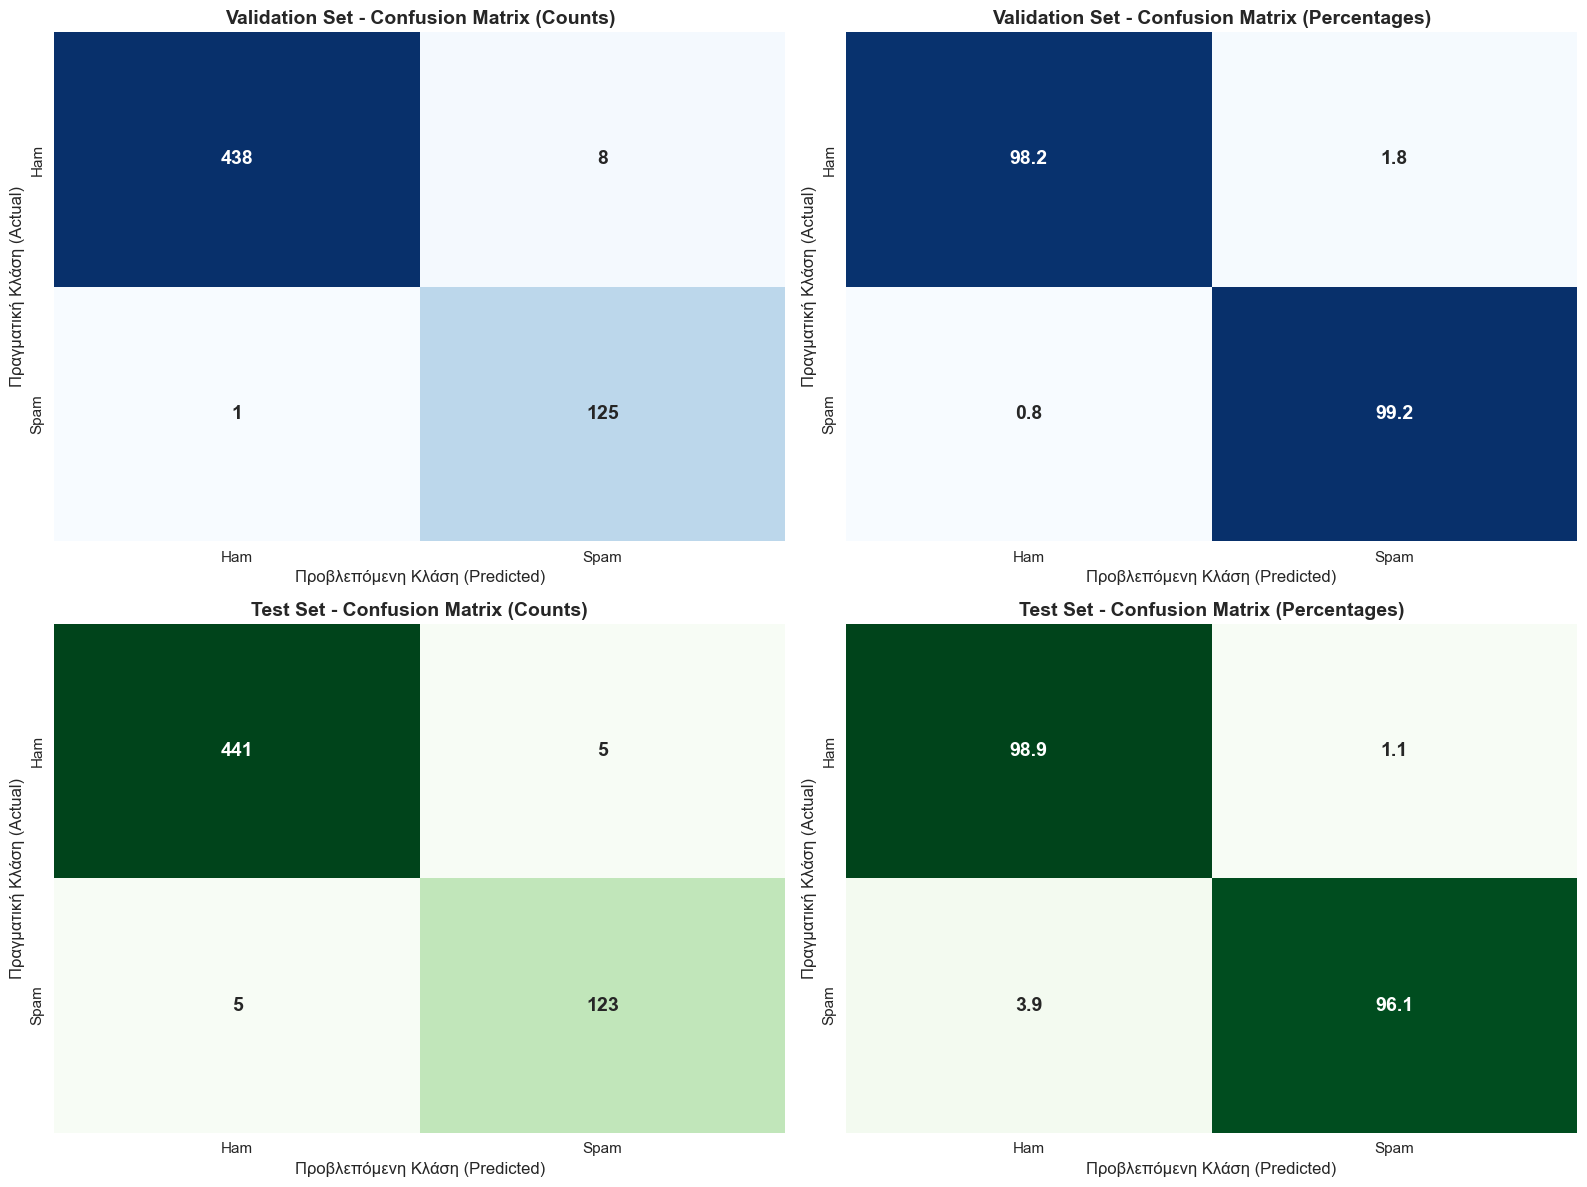


ΑΝΑΛΥΤΙΚΗ ΕΡΜΗΝΕΙΑ CONFUSION MATRIX (TEST SET)

Μετρική                        Αριθμός      Ποσοστό      Επεξήγηση
--------------------------------------------------------------------------------
True Negatives (TN)            441           98.88%     Ham σωστά ως Ham
False Positives (FP)           5              1.12%     Ham λάθος ως Spam (Type I Error)
False Negatives (FN)           5              3.91%     Spam λάθος ως Ham (Type II Error)
True Positives (TP)            123           96.09%     Spam σωστά ως Spam

--------------------------------------------------------------------------------

Accuracy (Ακρίβεια)            0.9826      (TP+TN) / Total
Precision (Ακρίβεια θετικών)   0.9609      TP / (TP+FP)
Recall/Sensitivity (Ανάκληση)  0.9609      TP / (TP+FN)
Specificity (Ειδικότητα)       0.9888      TN / (TN+FP)
F1-Score                       0.9609      Αρμονικός μέσος Precision & Recall
False Positive Rate            0.0112      FP / (FP+TN)
False Negative Rate            0

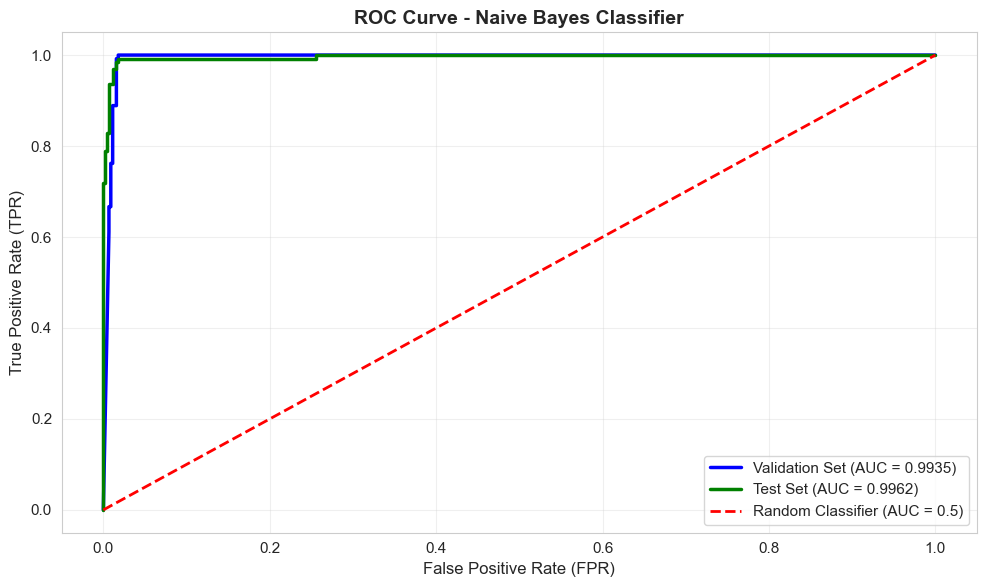


=== Σύγκριση Απόδοσης: Validation vs Test ===
   Metric  Validation     Test
Precision    0.939850 0.960938
   Recall    0.992063 0.960938
 F1-Score    0.965251 0.960938
      AUC    0.993532 0.996199


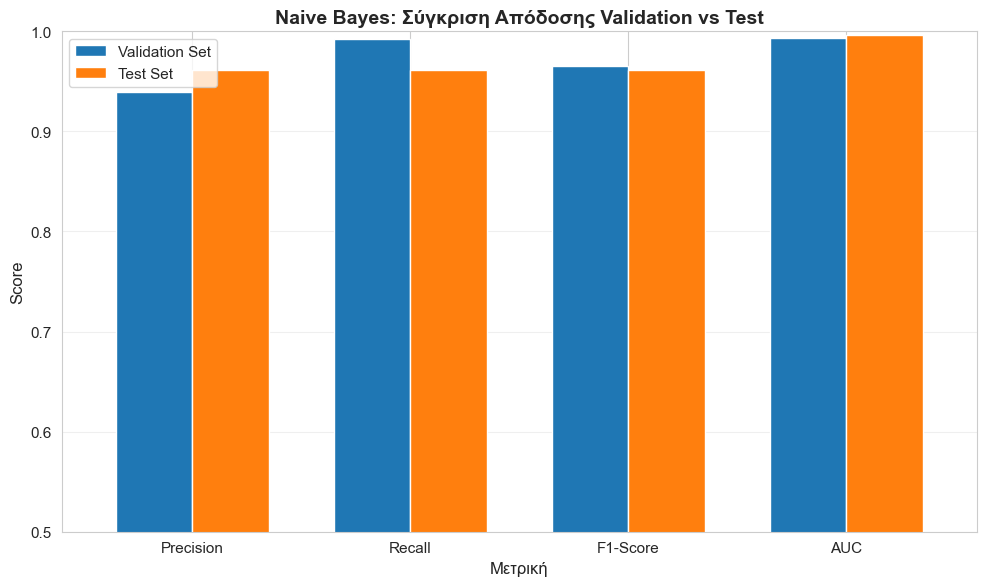

In [12]:
# Οπτικοποίηση Αποτελεσμάτων

# 1. Αναλυτικά Confusion Matrices με Ποσοστά
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Validation Set - Απόλυτοι Αριθμοί
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0,0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], 
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0,0].set_title('Validation Set - Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Πραγματική Κλάση (Actual)', fontsize=12)
axes[0,0].set_xlabel('Προβλεπόμενη Κλάση (Predicted)', fontsize=12)

# Validation Set - Ποσοστά
cm_val_pct = cm_val.astype('float') / cm_val.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_val_pct, annot=True, fmt='.1f', cmap='Blues', cbar=False, ax=axes[0,1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0,1].set_title('Validation Set - Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Πραγματική Κλάση (Actual)', fontsize=12)
axes[0,1].set_xlabel('Προβλεπόμενη Κλάση (Predicted)', fontsize=12)

# Test Set - Απόλυτοι Αριθμοί
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1,0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1,0].set_title('Test Set - Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Πραγματική Κλάση (Actual)', fontsize=12)
axes[1,0].set_xlabel('Προβλεπόμενη Κλάση (Predicted)', fontsize=12)

# Test Set - Ποσοστά
cm_test_pct = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_test_pct, annot=True, fmt='.1f', cmap='Greens', cbar=False, ax=axes[1,1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1,1].set_title('Test Set - Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Πραγματική Κλάση (Actual)', fontsize=12)
axes[1,1].set_xlabel('Προβλεπόμενη Κλάση (Predicted)', fontsize=12)

plt.tight_layout()
plt.show()

# Αναλυτική Ερμηνεία Confusion Matrix
print("\n" + "="*80)
print("ΑΝΑΛΥΤΙΚΗ ΕΡΜΗΝΕΙΑ CONFUSION MATRIX (TEST SET)")
print("="*80)
print(f"\n{'Μετρική':<30} {'Αριθμός':<12} {'Ποσοστό':<12} Επεξήγηση")
print("-"*80)
print(f"{'True Negatives (TN)':<30} {cm_test[0,0]:<12} {cm_test_pct[0,0]:>6.2f}%     Ham σωστά ως Ham")
print(f"{'False Positives (FP)':<30} {cm_test[0,1]:<12} {cm_test_pct[0,1]:>6.2f}%     Ham λάθος ως Spam (Type I Error)")
print(f"{'False Negatives (FN)':<30} {cm_test[1,0]:<12} {cm_test_pct[1,0]:>6.2f}%     Spam λάθος ως Ham (Type II Error)")
print(f"{'True Positives (TP)':<30} {cm_test[1,1]:<12} {cm_test_pct[1,1]:>6.2f}%     Spam σωστά ως Spam")
print("\n" + "-"*80)

# Υπολογισμός παράγωγων μετρικών από το Confusion Matrix
tn, fp, fn, tp = cm_test[0,0], cm_test[0,1], cm_test[1,0], cm_test[1,1]
accuracy = (tp + tn) / (tp + tn + fp + fn)
specificity = tn / (tn + fp)  # True Negative Rate
sensitivity = tp / (tp + fn)  # True Positive Rate (Recall)
fpr = fp / (fp + tn)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate

print(f"\n{'Accuracy (Ακρίβεια)':<30} {accuracy:.4f}      (TP+TN) / Total")
print(f"{'Precision (Ακρίβεια θετικών)':<30} {precision_test:.4f}      TP / (TP+FP)")
print(f"{'Recall/Sensitivity (Ανάκληση)':<30} {recall_test:.4f}      TP / (TP+FN)")
print(f"{'Specificity (Ειδικότητα)':<30} {specificity:.4f}      TN / (TN+FP)")
print(f"{'F1-Score':<30} {f1_test:.4f}      Αρμονικός μέσος Precision & Recall")
print(f"{'False Positive Rate':<30} {fpr:.4f}      FP / (FP+TN)")
print(f"{'False Negative Rate':<30} {fnr:.4f}      FN / (FN+TP)")

print("\n" + "="*80)

# 2. ROC Curve
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, label=f'Validation Set (AUC = {auc_val:.4f})', 
         linewidth=2.5, color='blue')
plt.plot(fpr_test, tpr_test, label=f'Test Set (AUC = {auc_test:.4f})', 
         linewidth=2.5, color='green')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve - Naive Bayes Classifier', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Σύγκριση Μετρικών (Validation vs Test)
metrics_comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score', 'AUC'],
    'Validation': [precision_val, recall_val, f1_val, auc_val],
    'Test': [precision_test, recall_test, f1_test, auc_test]
})

print("\n=== Σύγκριση Απόδοσης: Validation vs Test ===")
print(metrics_comparison.to_string(index=False))

# Bar plot
ax = metrics_comparison.plot(x='Metric', y=['Validation', 'Test'], kind='bar', 
                              figsize=(10, 6), rot=0, width=0.7)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Μετρική', fontsize=12)
ax.set_title('Naive Bayes: Σύγκριση Απόδοσης Validation vs Test', fontsize=14, fontweight='bold')
ax.legend(['Validation Set', 'Test Set'], fontsize=11)
ax.set_ylim([0.5, 1.0])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

ΟΙ 20 ΠΙΟ ΧΑΡΑΚΤΗΡΙΣΤΙΚΕΣ ΛΕΞΕΙΣ ΓΙΑ SPAM
           word  log_ratio
         viagra   6.383221
projecthoneypot   6.067368
     stationery   6.048137
   squirrelmail   5.924267
            sex   5.782855
         paypal   5.717473
     macromedia   5.603062
   andmanyother   5.587795
           wiil   5.540542
           dose   5.524281
  mailwisconsin   5.507752
            dvd   5.490945
          qmail   5.490945
         oniine   5.456459
           ebay   5.438759
           vnbl   5.420741
   professionai   5.383699
          corel   5.345233
         rolete   5.325431
           spam   5.284609

ΟΙ 20 ΠΙΟ ΧΑΡΑΚΤΗΡΙΣΤΙΚΕΣ ΛΕΞΕΙΣ ΓΙΑ HAM
       word  log_ratio
       cera  -4.342335
       rice  -4.367336
     vasant  -4.394735
      tanya  -4.427234
        dpc  -4.430137
         cc  -4.541134
derivatives  -4.562943
      zimin  -4.605186
    shirley  -4.664999
    wharton  -4.671092
     gibner  -4.766609
        lon  -5.009839
        ees  -5.221226
    stinson  -5.279916
   c

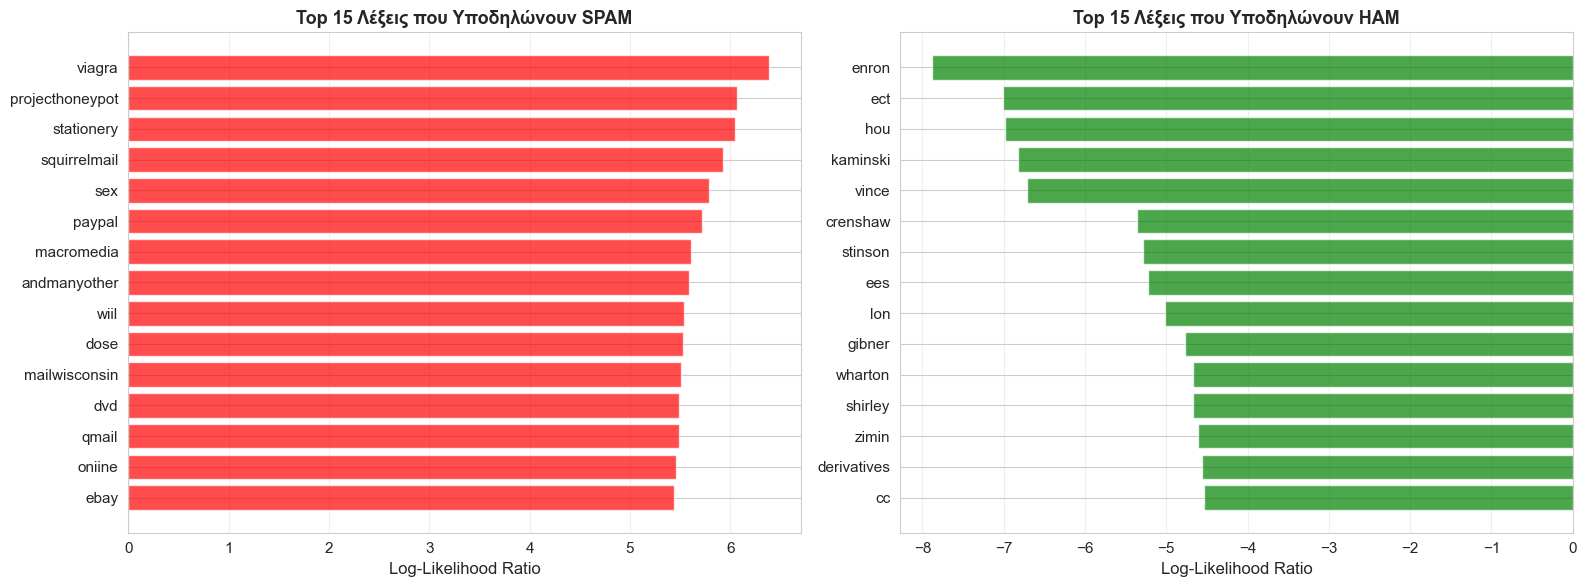

In [13]:
# Ανάλυση Πιο Πληροφοριακών Λέξεων (Feature Importance)

# Εξαγωγή των log-probabilities για κάθε κλάση
feature_names = vectorizer.get_feature_names_out()
log_probs_spam = nb_model.feature_log_prob_[1]  # Κλάση spam=1
log_probs_ham = nb_model.feature_log_prob_[0]   # Κλάση ham=0

# Υπολογισμός log-likelihood ratio: log(P(w|spam) / P(w|ham))
# Μεγάλες θετικές τιμές → λέξεις που υποδηλώνουν spam
# Μεγάλες αρνητικές τιμές → λέξεις που υποδηλώνουν ham
log_ratio = log_probs_spam - log_probs_ham

# Δημιουργία DataFrame για ανάλυση
feature_importance_df = pd.DataFrame({
    'word': feature_names,
    'log_ratio': log_ratio,
    'spam_log_prob': log_probs_spam,
    'ham_log_prob': log_probs_ham
}).sort_values('log_ratio', ascending=False)

print("="*70)
print("ΟΙ 20 ΠΙΟ ΧΑΡΑΚΤΗΡΙΣΤΙΚΕΣ ΛΕΞΕΙΣ ΓΙΑ SPAM")
print("="*70)
print(feature_importance_df.head(20)[['word', 'log_ratio']].to_string(index=False))

print("\n" + "="*70)
print("ΟΙ 20 ΠΙΟ ΧΑΡΑΚΤΗΡΙΣΤΙΚΕΣ ΛΕΞΕΙΣ ΓΙΑ HAM")
print("="*70)
print(feature_importance_df.tail(20)[['word', 'log_ratio']].to_string(index=False))

# Οπτικοποίηση Top 15 λέξεων για κάθε κλάση
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top spam words
top_spam = feature_importance_df.head(15)
axes[0].barh(range(15), top_spam['log_ratio'].values, color='red', alpha=0.7)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(top_spam['word'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Log-Likelihood Ratio', fontsize=12)
axes[0].set_title('Top 15 Λέξεις που Υποδηλώνουν SPAM', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Top ham words
top_ham = feature_importance_df.tail(15).sort_values('log_ratio')
axes[1].barh(range(15), top_ham['log_ratio'].values, color='green', alpha=0.7)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top_ham['word'].values)
axes[1].invert_yaxis()
axes[1].set_xlabel('Log-Likelihood Ratio', fontsize=12)
axes[1].set_title('Top 15 Λέξεις που Υποδηλώνουν HAM', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [14]:
# Δοκιμή Πρόβλεψης σε Νέα Δείγματα Email

def predict_email(email_text, show_prob=True):
    """
    Πρόβλεψη αν ένα email είναι spam ή ham.
    
    Παράμετροι:
    -----------
    email_text : str
        Το κείμενο του email
    show_prob : bool
        Αν θα εμφανιστούν οι πιθανότητες
    
    Επιστρέφει:
    -----------
    str : Η πρόβλεψη (Spam ή Ham)
    """
    # Προεπεξεργασία
    clean = preprocess_text(email_text)
    
    # Μετατροπή σε BoW
    bow = vectorizer.transform([clean])
    
    # Πρόβλεψη
    prediction = nb_model.predict(bow)[0]
    probabilities = nb_model.predict_proba(bow)[0]
    
    result = "SPAM" if prediction == 1 else "HAM"
    
    if show_prob:
        print(f"Πρόβλεψη: {result}")
        print(f"Πιθανότητα Ham:  {probabilities[0]:.4f}")
        print(f"Πιθανότητα Spam: {probabilities[1]:.4f}")
    
    return result

print("="*70)
print("ΠΑΡΑΔΕΙΓΜΑΤΑ ΠΡΟΒΛΕΨΕΩΝ")
print("="*70)

# Παράδειγμα 1: Σαφές spam
print("\n1. Email: 'Win free money now! Click here for lottery prizes!'")
predict_email('Win free money now! Click here for lottery prizes!')

# Παράδειγμα 2: Σαφές ham
print("\n2. Email: 'Hi, let's schedule our meeting for tomorrow at 3pm'")
predict_email('Hi, let\'s schedule our meeting for tomorrow at 3pm')

# Παράδειγμα 3: Από το test set
print(f"\n3. Email από Test Set (index 0):")
print(f"Πρωτότυπο: {test_df.iloc[0]['text'][:100]}...")
print(f"Πραγματική κλάση: {'SPAM' if test_df.iloc[0]['spam'] == 1 else 'HAM'}")
predict_email(test_df.iloc[0]['text'])

print("\n✓ Task 2 ολοκληρώθηκε επιτυχώς!")

ΠΑΡΑΔΕΙΓΜΑΤΑ ΠΡΟΒΛΕΨΕΩΝ

1. Email: 'Win free money now! Click here for lottery prizes!'
Πρόβλεψη: SPAM
Πιθανότητα Ham:  0.0000
Πιθανότητα Spam: 1.0000

2. Email: 'Hi, let's schedule our meeting for tomorrow at 3pm'
Πρόβλεψη: HAM
Πιθανότητα Ham:  1.0000
Πιθανότητα Spam: 0.0000

3. Email από Test Set (index 0):
Πρωτότυπο: Subject: old email address  > hello vince ,  > nie bardzo wiem czy pisac po polsku czy po angielsku ...
Πραγματική κλάση: HAM
Πρόβλεψη: HAM
Πιθανότητα Ham:  1.0000
Πιθανότητα Spam: 0.0000

✓ Task 2 ολοκληρώθηκε επιτυχώς!


---
# Task 3: Sentence Embeddings με SentenceTransformer

## Θεωρία

Τα **Sentence Embeddings** (Ενσωματώσεις Προτάσεων) είναι διανυσματικές αναπαραστάσεις κειμένου που κωδικοποιούν τη **σημασιολογική πληροφορία** ολόκληρων προτάσεων ή εγγράφων σε πυκνά διανύσματα σταθερού μεγέθους. Σε αντίθεση με το Bag-of-Words που αγνοεί τη σειρά και τη σημασία των λέξεων, τα sentence embeddings **διατηρούν τη σημασιολογική δομή** και τις σχέσεις μεταξύ των λέξεων.

### Τι είναι τα Sentence Embeddings

Ένα sentence embedding είναι μια συνάρτηση $f: \mathcal{S} \rightarrow \mathbb{R}^d$ που απεικονίζει μια πρόταση $s \in \mathcal{S}$ σε ένα διάνυσμα $d$-διαστάσεων:

$$\mathbf{v}_s = f(s) = [v_1, v_2, ..., v_d]^T \in \mathbb{R}^d$$

όπου $d$ είναι η διάσταση του embedding (συνήθως 384, 512, 768 κ.λπ.).

### Βασικές Ιδιότητες

1. **Σταθερή Διάσταση**: Ανεξάρτητα από το μήκος του κειμένου, το embedding έχει πάντα την ίδια διάσταση $d$.

2. **Σημασιολογική Εγγύτητα**: Κείμενα με παρόμοιο νόημα έχουν embeddings με μικρή απόσταση στον χώρο $\mathbb{R}^d$:

$$\text{similarity}(s_1, s_2) = \cos(\mathbf{v}_{s_1}, \mathbf{v}_{s_2}) = \frac{\mathbf{v}_{s_1} \cdot \mathbf{v}_{s_2}}{\|\mathbf{v}_{s_1}\| \|\mathbf{v}_{s_2}\|}$$

3. **Πυκνή Αναπαράσταση**: Σε αντίθεση με το Bag-of-Words (sparse), τα embeddings είναι dense vectors (όλες οι διαστάσεις έχουν non-zero τιμές).

### SentenceTransformer: Μοντέλο BERT-based

Το **SentenceTransformer** χρησιμοποιεί προ-εκπαιδευμένα μοντέλα βασισμένα στην αρχιτεκτονική **BERT (Bidirectional Encoder Representations from Transformers)**. Το μοντέλο που χρησιμοποιούμε είναι το **'paraphrase-multilingual-MiniLM-L12-v2'**, το οποίο:

- Έχει εκπαιδευτεί σε πολλές γλώσσες (multilingual)
- Είναι βελτιστοποιημένο για την αναγνώριση παραφράσεων (paraphrase detection)
- Παράγει embeddings διάστασης **384**
- Είναι compact (MiniLM) με 12 layers

### Μαθηματική Περιγραφή της Διαδικασίας

Για ένα email $e$ με clean text $t_e$:

1. **Tokenization**: Το κείμενο χωρίζεται σε tokens (subwords):
   $$t_e \rightarrow [token_1, token_2, ..., token_n]$$

2. **BERT Encoding**: Κάθε token περνάει από τα 12 layers του Transformer:
   $$\mathbf{h}_i^{(l)} = \text{TransformerLayer}^{(l)}(\mathbf{h}_i^{(l-1)})$$
   όπου $\mathbf{h}_i^{(l)}$ είναι το hidden state του token $i$ στο layer $l$.

3. **Pooling**: Τα token embeddings συνδυάζονται σε ένα sentence embedding με **mean pooling**:
   $$\mathbf{v}_e = \frac{1}{n} \sum_{i=1}^{n} \mathbf{h}_i^{(12)}$$

4. **Normalization**: Το τελικό embedding κανονικοποιείται:
   $$\mathbf{v}_e^{\text{norm}} = \frac{\mathbf{v}_e}{\|\mathbf{v}_e\|}$$

### Πλεονεκτήματα έναντι Bag-of-Words

1. **Κατανόηση Σημασιολογίας**: Αναγνωρίζει συνώνυμα, παραφράσεις και περιβάλλον (context)
   - BoW: "free money" και "complimentary funds" είναι διαφορετικά
   - Embeddings: αναγνωρίζουν παρόμοια σημασία

2. **Διαχείριση Εκτός Λεξιλογίου (OOV)**: Χειρίζεται λέξεις που δεν υπάρχουν στο training set μέσω subword tokenization

3. **Συμπαγής Αναπαράσταση**: 384 διαστάσεις vs 5000 στο BoW

4. **Transfer Learning**: Αξιοποιεί γνώση από τεράστια corpora (Wikipedia, Common Crawl, κ.λπ.)

### Χρήση για Ταξινόμηση

Τα sentence embeddings χρησιμοποιούνται ως χαρακτηριστικά για οποιονδήποτε classifier:

$$\hat{y} = \text{Classifier}(\mathbf{v}_e) = \text{Classifier}(f(t_e))$$

Στην εργασία μας, θα χρησιμοποιήσουμε **Logistic Regression** για την ταξινόμηση spam/ham πάνω στα embeddings.

In [15]:
# Φόρτωση του SentenceTransformer μοντέλου
print("Φόρτωση SentenceTransformer μοντέλου...")
print("Αυτό μπορεί να πάρει λίγο χρόνο στην πρώτη εκτέλεση (download ~100MB)...\n")

sentence_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("✓ Το μοντέλο φορτώθηκε επιτυχώς!")
print(f"Διάσταση embeddings: {sentence_model.get_sentence_embedding_dimension()}")

Φόρτωση SentenceTransformer μοντέλου...
Αυτό μπορεί να πάρει λίγο χρόνο στην πρώτη εκτέλεση (download ~100MB)...

✓ Το μοντέλο φορτώθηκε επιτυχώς!
Διάσταση embeddings: 384


In [16]:
# Δημιουργία Sentence Embeddings για όλα τα datasets
print("Δημιουργία sentence embeddings...")
print("Αυτό μπορεί να πάρει αρκετά λεπτά ανάλογα με το μέγεθος του dataset...\n")

# Encoding: Μετατροπή κειμένου σε dense vectors
print("Encoding Training Set...")
X_train_emb = sentence_model.encode(train_df['clean_text'].tolist(), 
                                     show_progress_bar=True,
                                     batch_size=32)

print("\nEncoding Validation Set...")
X_val_emb = sentence_model.encode(val_df['clean_text'].tolist(), 
                                   show_progress_bar=True,
                                   batch_size=32)

print("\nEncoding Test Set...")
X_test_emb = sentence_model.encode(test_df['clean_text'].tolist(), 
                                    show_progress_bar=True,
                                    batch_size=32)

print("\n✓ Τα embeddings δημιουργήθηκαν επιτυχώς!")

# Στατιστικά
print("\n=== Διαστάσεις Embedding Matrices ===")
print(f"Training: {X_train_emb.shape} ({X_train_emb.shape[0]} emails × {X_train_emb.shape[1]} dimensions)")
print(f"Validation: {X_val_emb.shape}")
print(f"Test: {X_test_emb.shape}")

print(f"\n=== Χαρακτηριστικά Embeddings ===")
print(f"Τύπος δεδομένων: {X_train_emb.dtype}")
print(f"Μέση τιμή: {X_train_emb.mean():.4f}")
print(f"Τυπική απόκλιση: {X_train_emb.std():.4f}")
print(f"Min: {X_train_emb.min():.4f}, Max: {X_train_emb.max():.4f}")

# Παράδειγμα: Εμφάνιση του embedding του πρώτου email
print(f"\nΠαράδειγμα - Πρώτες 10 διαστάσεις του 1ου email:")
print(X_train_emb[0][:10])

Δημιουργία sentence embeddings...
Αυτό μπορεί να πάρει αρκετά λεπτά ανάλογα με το μέγεθος του dataset...

Encoding Training Set...


Batches:   0%|          | 0/144 [00:00<?, ?it/s]


Encoding Validation Set...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]


Encoding Test Set...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]


✓ Τα embeddings δημιουργήθηκαν επιτυχώς!

=== Διαστάσεις Embedding Matrices ===
Training: (4582, 384) (4582 emails × 384 dimensions)
Validation: (572, 384)
Test: (574, 384)

=== Χαρακτηριστικά Embeddings ===
Τύπος δεδομένων: float32
Μέση τιμή: -0.0002
Τυπική απόκλιση: 0.1613
Min: -1.0577, Max: 1.4966

Παράδειγμα - Πρώτες 10 διαστάσεις του 1ου email:
[ 0.1003716   0.13745748  0.23120639  0.03730574  0.00601111  0.05049751
 -0.23836452  0.09476491 -0.12966399 -0.03517355]


In [17]:
# Εκπαίδευση Logistic Regression Classifier με Sentence Embeddings
# Το Logistic Regression είναι κατάλληλο για dense features και δουλεύει καλά με embeddings

from sklearn.linear_model import LogisticRegression

print("Εκπαίδευση Logistic Regression classifier...")

# Δημιουργία και εκπαίδευση μοντέλου
# C=1.0: Regularization parameter (default)
# max_iter=1000: Αρκετές iterations για σύγκλιση
lr_emb_model = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
lr_emb_model.fit(X_train_emb, y_train)

print("✓ Το μοντέλο Logistic Regression εκπαιδεύτηκε επιτυχώς!")

# Προβλέψεις
y_train_pred_emb = lr_emb_model.predict(X_train_emb)
y_val_pred_emb = lr_emb_model.predict(X_val_emb)

# Πιθανότητες για AUC
y_train_proba_emb = lr_emb_model.predict_proba(X_train_emb)[:, 1]
y_val_proba_emb = lr_emb_model.predict_proba(X_val_emb)[:, 1]

print("\n=== Απόδοση στο Training Set ===")
print(f"Accuracy: {lr_emb_model.score(X_train_emb, y_train):.4f}")

print("\n=== Απόδοση στο Validation Set ===")
print(f"Accuracy: {lr_emb_model.score(X_val_emb, y_val):.4f}")

Εκπαίδευση Logistic Regression classifier...
✓ Το μοντέλο Logistic Regression εκπαιδεύτηκε επιτυχώς!

=== Απόδοση στο Training Set ===
Accuracy: 0.9880

=== Απόδοση στο Validation Set ===
Accuracy: 0.9703


In [18]:
# Αξιολόγηση στο Validation Set
precision_val_emb = precision_score(y_val, y_val_pred_emb)
recall_val_emb = recall_score(y_val, y_val_pred_emb)
f1_val_emb = f1_score(y_val, y_val_pred_emb)
auc_val_emb = roc_auc_score(y_val, y_val_proba_emb)

print("=== Αποτελέσματα στο Validation Set (Sentence Embeddings) ===")
print(f"Precision: {precision_val_emb:.4f}")
print(f"Recall:    {recall_val_emb:.4f}")
print(f"F1-Score:  {f1_val_emb:.4f}")
print(f"AUC:       {auc_val_emb:.4f}")

# Confusion Matrix
cm_val_emb = confusion_matrix(y_val, y_val_pred_emb)
print("\n--- Confusion Matrix (Validation Set) ---")
print(f"                 Predicted")
print(f"                Ham    Spam")
print(f"Actual Ham    {cm_val_emb[0,0]:5d}  {cm_val_emb[0,1]:5d}")
print(f"       Spam   {cm_val_emb[1,0]:5d}  {cm_val_emb[1,1]:5d}")

=== Αποτελέσματα στο Validation Set (Sentence Embeddings) ===
Precision: 0.9160
Recall:    0.9524
F1-Score:  0.9339
AUC:       0.9973

--- Confusion Matrix (Validation Set) ---
                 Predicted
                Ham    Spam
Actual Ham      435     11
       Spam       6    120


In [19]:
# Τελική αξιολόγηση στο Test Set

print("="*70)
print("ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ SENTENCE EMBEDDINGS + LOGISTIC REGRESSION")
print("="*70)

# Προβλέψεις στο test set
y_test_pred_emb = lr_emb_model.predict(X_test_emb)
y_test_proba_emb = lr_emb_model.predict_proba(X_test_emb)[:, 1]

# Υπολογισμός μετρικών
precision_test_emb = precision_score(y_test, y_test_pred_emb)
recall_test_emb = recall_score(y_test, y_test_pred_emb)
f1_test_emb = f1_score(y_test, y_test_pred_emb)
auc_test_emb = roc_auc_score(y_test, y_test_proba_emb)

print(f"\nPrecision: {precision_test_emb:.4f}")
print(f"Recall:    {recall_test_emb:.4f}")
print(f"F1-Score:  {f1_test_emb:.4f}")
print(f"AUC:       {auc_test_emb:.4f}")

# Confusion Matrix
cm_test_emb = confusion_matrix(y_test, y_test_pred_emb)
cm_test_emb_pct = cm_test_emb.astype('float') / cm_test_emb.sum(axis=1)[:, np.newaxis] * 100

print("\n                      Προβλεπόμενη Κλάση")
print("                    ┌─────────┬─────────┐")
print(f"                    │   Ham   │  Spam   │")
print("    ┌───────────────┼─────────┼─────────┤")
print(f"    │ Ham   (Πραγμ.)│  {cm_test_emb[0,0]:5d}  │  {cm_test_emb[0,1]:5d}  │")
print(f"Πραγ│               │({cm_test_emb_pct[0,0]:5.1f}%) │({cm_test_emb_pct[0,1]:5.1f}%) │")
print("    ├───────────────┼─────────┼─────────┤")
print(f"    │ Spam  (Πραγμ.)│  {cm_test_emb[1,0]:5d}  │  {cm_test_emb[1,1]:5d}  │")
print(f"    │               │({cm_test_emb_pct[1,0]:5.1f}%) │({cm_test_emb_pct[1,1]:5.1f}%) │")
print("    └───────────────┴─────────┴─────────┘")

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred_emb, target_names=['Ham (0)', 'Spam (1)']))

# Αποθήκευση αποτελεσμάτων για σύγκριση
results_embeddings = {
    'Model': 'Logistic Regression',
    'Features': 'Sentence Embeddings',
    'Precision': precision_test_emb,
    'Recall': recall_test_emb,
    'F1-Score': f1_test_emb,
    'AUC': auc_test_emb
}

print(f"\n✓ Τα αποτελέσματα των Sentence Embeddings αποθηκεύτηκαν για σύγκριση!")

ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ SENTENCE EMBEDDINGS + LOGISTIC REGRESSION

Precision: 0.9603
Recall:    0.9453
F1-Score:  0.9528
AUC:       0.9949

                      Προβλεπόμενη Κλάση
                    ┌─────────┬─────────┐
                    │   Ham   │  Spam   │
    ┌───────────────┼─────────┼─────────┤
    │ Ham   (Πραγμ.)│    441  │      5  │
Πραγ│               │( 98.9%) │(  1.1%) │
    ├───────────────┼─────────┼─────────┤
    │ Spam  (Πραγμ.)│      7  │    121  │
    │               │(  5.5%) │( 94.5%) │
    └───────────────┴─────────┴─────────┘

=== Classification Report ===
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.99       446
    Spam (1)       0.96      0.95      0.95       128

    accuracy                           0.98       574
   macro avg       0.97      0.97      0.97       574
weighted avg       0.98      0.98      0.98       574


✓ Τα αποτελέσματα των Sentence Embeddings αποθηκεύτηκαν για σύγκριση!


ΣΥΓΚΡΙΣΗ: SENTENCE EMBEDDINGS vs BAG-OF-WORDS

                     Μέθοδος  Precision   Recall  F1-Score      AUC
  Bag-of-Words (Naive Bayes)   0.960938 0.960938  0.960938 0.996199
Sentence Embeddings (LogReg)   0.960317 0.945312  0.952756 0.994868

Μετρική         BoW        Embeddings   Διαφορά    Αλλαγή
--------------------------------------------------------------------------------
Precision       0.9609    0.9603      -0.0006   📉 -0.06%
Recall          0.9609    0.9453      -0.0156   📉 -1.63%
F1-Score        0.9609    0.9528      -0.0082   📉 -0.85%
AUC             0.9962    0.9949      -0.0013   📉 -0.13%


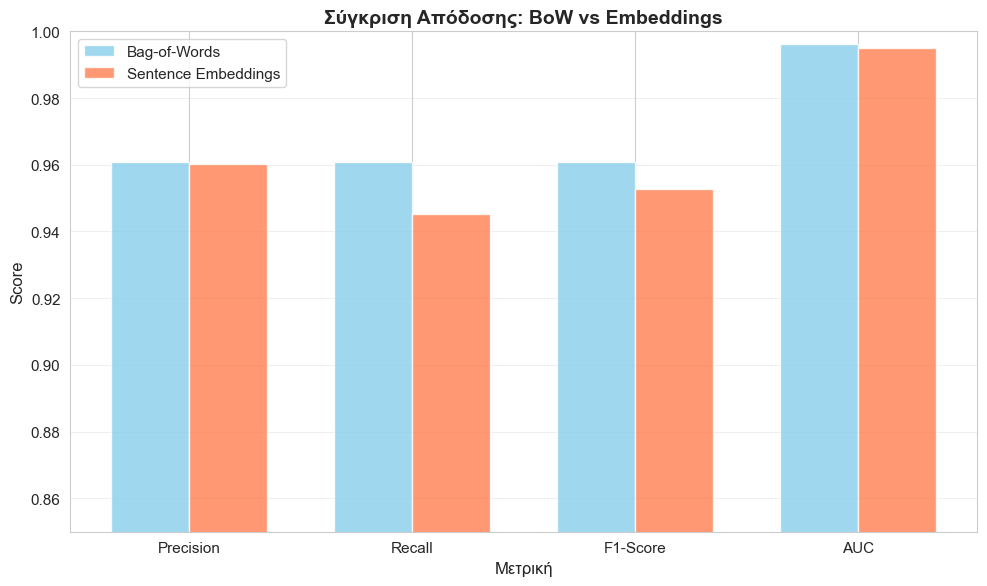

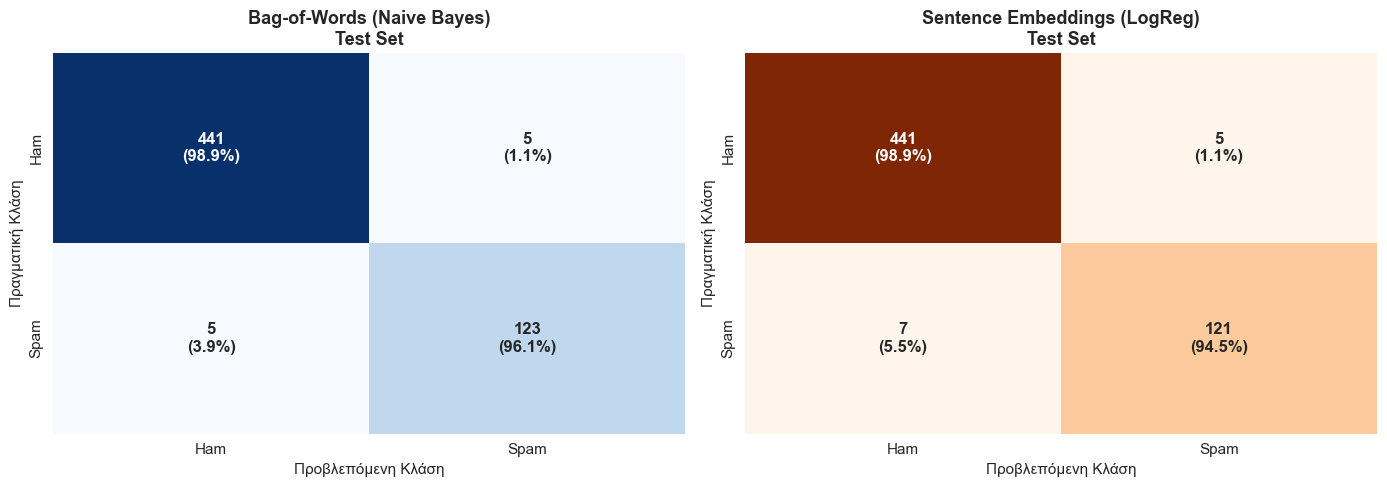

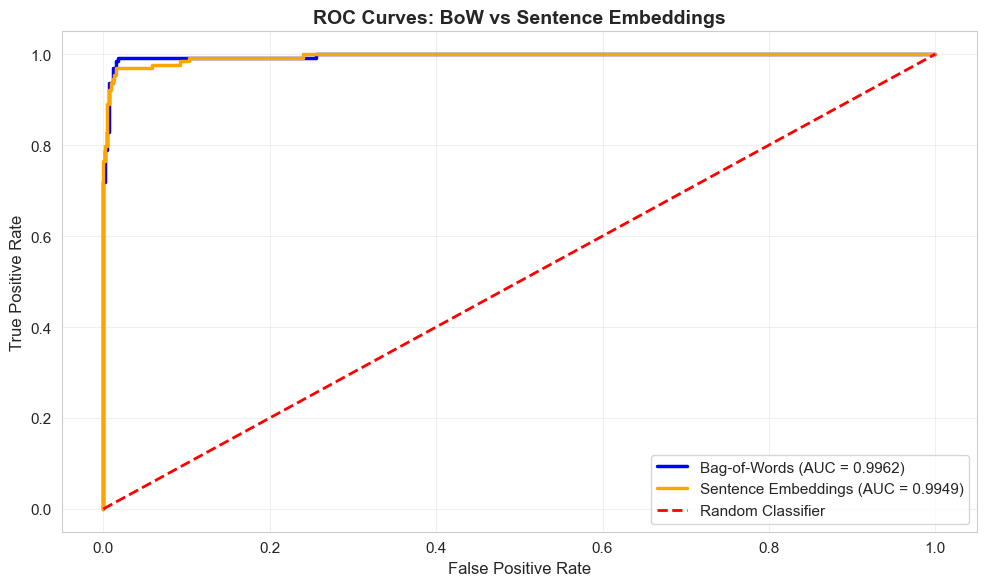


✓ Task 3 ολοκληρώθηκε επιτυχώς!


In [20]:
# Σύγκριση Sentence Embeddings vs Bag-of-Words

print("="*80)
print("ΣΥΓΚΡΙΣΗ: SENTENCE EMBEDDINGS vs BAG-OF-WORDS")
print("="*80)

comparison_df = pd.DataFrame({
    'Μέθοδος': ['Bag-of-Words (Naive Bayes)', 'Sentence Embeddings (LogReg)'],
    'Precision': [precision_test, precision_test_emb],
    'Recall': [recall_test, recall_test_emb],
    'F1-Score': [f1_test, f1_test_emb],
    'AUC': [auc_test, auc_test_emb]
})

print("\n" + comparison_df.to_string(index=False))

# Υπολογισμός διαφορών
print(f"\n{'Μετρική':<15} {'BoW':<10} {'Embeddings':<12} {'Διαφορά':<10} Αλλαγή")
print("-"*80)
for metric in ['Precision', 'Recall', 'F1-Score', 'AUC']:
    bow_val = comparison_df[comparison_df['Μέθοδος'].str.contains('Bag')][metric].values[0]
    emb_val = comparison_df[comparison_df['Μέθοδος'].str.contains('Sentence')][metric].values[0]
    diff = emb_val - bow_val
    pct_change = (diff / bow_val) * 100
    symbol = "📈" if diff > 0 else "📉" if diff < 0 else "➡️"
    print(f"{metric:<15} {bow_val:.4f}    {emb_val:.4f}      {diff:+.4f}   {symbol} {pct_change:+.2f}%")

# Οπτικοποίηση Σύγκρισης
# Bar plot - Σύγκριση μετρικών
plt.figure(figsize=(10, 6))
metrics = ['Precision', 'Recall', 'F1-Score', 'AUC']
bow_values = [precision_test, recall_test, f1_test, auc_test]
emb_values = [precision_test_emb, recall_test_emb, f1_test_emb, auc_test_emb]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, bow_values, width, label='Bag-of-Words', color='skyblue', alpha=0.8)
plt.bar(x + width/2, emb_values, width, label='Sentence Embeddings', color='coral', alpha=0.8)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Μετρική', fontsize=12)
plt.title('Σύγκριση Απόδοσης: BoW vs Embeddings', fontsize=14, fontweight='bold')
plt.xticks(x, metrics)
plt.legend(fontsize=11)
plt.ylim([0.85, 1.0])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Confusion Matrices - Side by side
cm_data = [cm_test, cm_test_emb]
titles = ['Bag-of-Words (Naive Bayes)', 'Sentence Embeddings (LogReg)']
colors = ['Blues', 'Oranges']

# Δημιουργία subplot για confusion matrices
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

for idx, (cm, title, cmap) in enumerate(zip(cm_data, titles, colors)):
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Δημιουργία custom annotations με counts και percentages
    annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
    
    sns.heatmap(cm, annot=annot, fmt='', cmap=cmap, cbar=False, ax=axes2[idx],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
                annot_kws={'size': 12, 'weight': 'bold'})
    axes2[idx].set_title(f'{title}\nTest Set', fontsize=13, fontweight='bold')
    axes2[idx].set_ylabel('Πραγματική Κλάση', fontsize=11)
    axes2[idx].set_xlabel('Προβλεπόμενη Κλάση', fontsize=11)

plt.tight_layout()
plt.show()

# ROC Curves - Comparison
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_test_proba)
fpr_emb, tpr_emb, _ = roc_curve(y_test, y_test_proba_emb)

plt.figure(figsize=(10, 6))
plt.plot(fpr_nb, tpr_nb, label=f'Bag-of-Words (AUC = {auc_test:.4f})', 
         linewidth=2.5, color='blue')
plt.plot(fpr_emb, tpr_emb, label=f'Sentence Embeddings (AUC = {auc_test_emb:.4f})', 
         linewidth=2.5, color='orange')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: BoW vs Sentence Embeddings', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Task 3 ολοκληρώθηκε επιτυχώς!")

---
# Task 4: k-Nearest Neighbors (k-NN) Classifier

## Θεωρία

Ο αλγόριθμος **k-Nearest Neighbors (k-NN)** είναι ένας **μη-παραμετρικός** (non-parametric) αλγόριθμος ταξινόμησης που βασίζεται στην αρχή της **εγγύτητας στον χώρο χαρακτηριστικών**. Σε αντίθεση με παραμετρικά μοντέλα όπως ο Naive Bayes που εκπαιδεύουν ένα σύνολο παραμέτρων, ο k-NN **αποθηκεύει όλα τα training δεδομένα** και κάνει προβλέψεις βάσει της πλειοψηφίας των πλησιέστερων γειτόνων.

### Βασική Αρχή

Για να ταξινομήσει ένα νέο σημείο $\mathbf{x}$, ο k-NN:

1. Υπολογίζει την απόσταση από όλα τα training σημεία
2. Επιλέγει τα $k$ πλησιέστερα σημεία
3. Αναθέτει την κλάση με βάση την **πλειοψηφία** (majority voting)

Μαθηματικά:

$$\hat{y} = \text{mode}\{y_i : \mathbf{x}_i \in \mathcal{N}_k(\mathbf{x})\}$$

όπου $\mathcal{N}_k(\mathbf{x})$ είναι το σύνολο των $k$ πλησιέστερων γειτόνων του $\mathbf{x}$.

### Μέτρηση Απόστασης

Η πιο συνηθισμένη μέτρηση είναι η **Ευκλείδεια απόσταση**:

$$d(\mathbf{x}_i, \mathbf{x}_j) = \sqrt{\sum_{m=1}^{d} (x_{i,m} - x_{j,m})^2} = \|\mathbf{x}_i - \mathbf{x}_j\|_2$$

όπου $d$ είναι η διάσταση των δεδομένων (στην περίπτωσή μας, 384 για τα embeddings).

Για δυαδική ταξινόμηση (spam/ham), η απόφαση δίνεται από:

$$P(\text{spam}|\mathbf{x}) = \frac{1}{k} \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbb{1}(y_i = \text{spam})$$

### Επιλογή της Παραμέτρου k

Η τιμή του $k$ είναι **υπερπαράμετρος** (hyperparameter) που επηρεάζει σημαντικά την απόδοση:

**Μικρό k (π.χ. k=1, k=3):**
- **Υψηλή διακύμανση** (high variance): Ευαίσθητο σε θόρυβο και outliers
- Πιο **σύνθετα όρια απόφασης** (decision boundaries)
- Κίνδυνος **overfitting**

**Μεγάλο k (π.χ. k=51, k=101):**
- **Υψηλό bias** (high bias): Απλοποιημένα όρια απόφασης
- Πιο **ομαλή** πρόβλεψη
- Κίνδυνος **underfitting**

**Βέλτιστο k:**
- Επιλέγεται με **cross-validation** ή **validation set**
- Συνήθως **περιττός αριθμός** για δυαδική ταξινόμηση (αποφυγή ισοπαλίας)
- Εμπειρικός κανόνας: $k \approx \sqrt{N}$ όπου $N$ το μέγεθος training set

### Ιδιότητες του k-NN

**Πλεονεκτήματα:**
1. **Απλότητα**: Εύκολος στην κατανόηση και υλοποίηση
2. **Μη-παραμετρικός**: Δεν κάνει υποθέσεις για την κατανομή των δεδομένων
3. **Προσαρμοστικότητα**: Μπορεί να μοντελοποιήσει σύνθετα όρια απόφασης
4. **Multi-class**: Λειτουργεί εξίσης καλά για >2 κλάσεις

**Μειονεκτήματα:**
1. **Υπολογιστική πολυπλοκότητα**: $O(Nd)$ για κάθε πρόβλεψη
2. **Ευαισθησία σε κλίμακα**: Χαρακτηριστικά με μεγάλες τιμές κυριαρχούν
3. **Curse of dimensionality**: Σε υψηλές διαστάσεις, όλες οι αποστάσεις γίνονται παρόμοιες
4. **Αποθήκευση**: Πρέπει να κρατήσει όλα τα training data

### Βελτιστοποιήσεις

1. **Normalization/Scaling**: Απαραίτητο για ισόρροπη συμβολή των features
2. **KD-Trees/Ball-Trees**: Επιταχύνουν την αναζήτηση γειτόνων σε $O(\log N)$
3. **Distance Weighting**: $w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}_i)}$ για περισσότερο βάρος στους πλησιέστερους
4. **Dimensionality Reduction**: PCA, embeddings για μείωση διαστάσεων

### Εφαρμογή στο Spam Classification

Χρησιμοποιούμε k-NN με **sentence embeddings** (384 διαστάσεις) γιατί:
- Τα embeddings είναι ήδη κανονικοποιημένα
- Η σημασιολογική εγγύτητα αντιστοιχεί σε Ευκλείδεια απόσταση
- Δοκιμάζουμε: $k \in \{1, 3, 5, 7, 9, 11, 15, 21\}$
- Επιλέγουμε το βέλτιστο $k$ με βάση το **validation set**
- Αξιολογούμε το τελικό μοντέλο στο **test set**

In [21]:
# Δοκιμή διαφορετικών τιμών k για k-NN
# Χρησιμοποιούμε τα sentence embeddings ως χαρακτηριστικά

print("="*70)
print("k-NN CLASSIFIER: ΔΟΚΙΜΗ ΔΙΑΦΟΡΕΤΙΚΩΝ ΤΙΜΩΝ k")
print("="*70)

# Δοκιμάζουμε περιττούς αριθμούς για αποφυγή ισοπαλιών
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

# Αποθήκευση αποτελεσμάτων
results_knn = []

print("\nΕκπαίδευση και αξιολόγηση k-NN για διάφορες τιμές k...\n")

for k in k_values:
    # Δημιουργία k-NN classifier
    knn_model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    
    # Εκπαίδευση στο training set
    knn_model.fit(X_train_emb, y_train)
    
    # Προβλέψεις στο validation set
    y_val_pred_knn = knn_model.predict(X_val_emb)
    y_val_proba_knn = knn_model.predict_proba(X_val_emb)[:, 1]
    
    # Υπολογισμός μετρικών
    precision_val_knn = precision_score(y_val, y_val_pred_knn)
    recall_val_knn = recall_score(y_val, y_val_pred_knn)
    f1_val_knn = f1_score(y_val, y_val_pred_knn)
    auc_val_knn = roc_auc_score(y_val, y_val_proba_knn)
    accuracy_val_knn = knn_model.score(X_val_emb, y_val)
    
    results_knn.append({
        'k': k,
        'Accuracy': accuracy_val_knn,
        'Precision': precision_val_knn,
        'Recall': recall_val_knn,
        'F1-Score': f1_val_knn,
        'AUC': auc_val_knn
    })
    
    print(f"k={k:2d} → Accuracy: {accuracy_val_knn:.4f}, Precision: {precision_val_knn:.4f}, "
          f"Recall: {recall_val_knn:.4f}, F1: {f1_val_knn:.4f}, AUC: {auc_val_knn:.4f}")

# Δημιουργία DataFrame για ανάλυση
knn_results_df = pd.DataFrame(results_knn)

print("\n" + "="*70)
print("ΣΥΓΚΡΙΤΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ VALIDATION SET")
print("="*70)
print(knn_results_df.to_string(index=False))

# Εύρεση βέλτιστου k με βάση F1-Score
best_k = knn_results_df.loc[knn_results_df['F1-Score'].idxmax(), 'k']
best_f1 = knn_results_df.loc[knn_results_df['F1-Score'].idxmax(), 'F1-Score']

print(f"\n✓ Βέλτιστη τιμή: k = {int(best_k)} (F1-Score = {best_f1:.4f})")

k-NN CLASSIFIER: ΔΟΚΙΜΗ ΔΙΑΦΟΡΕΤΙΚΩΝ ΤΙΜΩΝ k

Εκπαίδευση και αξιολόγηση k-NN για διάφορες τιμές k...

k= 1 → Accuracy: 0.9843, Precision: 0.9835, Recall: 0.9444, F1: 0.9636, AUC: 0.9700
k= 3 → Accuracy: 0.9755, Precision: 0.9746, Recall: 0.9127, F1: 0.9426, AUC: 0.9904
k= 5 → Accuracy: 0.9773, Precision: 0.9829, Recall: 0.9127, F1: 0.9465, AUC: 0.9905
k= 7 → Accuracy: 0.9755, Precision: 0.9828, Recall: 0.9048, F1: 0.9421, AUC: 0.9941
k= 9 → Accuracy: 0.9738, Precision: 0.9912, Recall: 0.8889, F1: 0.9372, AUC: 0.9978
k=11 → Accuracy: 0.9738, Precision: 0.9826, Recall: 0.8968, F1: 0.9378, AUC: 0.9975
k=15 → Accuracy: 0.9720, Precision: 0.9911, Recall: 0.8810, F1: 0.9328, AUC: 0.9973
k=21 → Accuracy: 0.9598, Precision: 0.9813, Recall: 0.8333, F1: 0.9013, AUC: 0.9967

ΣΥΓΚΡΙΤΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ VALIDATION SET
 k  Accuracy  Precision   Recall  F1-Score      AUC
 1  0.984266   0.983471 0.944444  0.963563 0.969980
 3  0.975524   0.974576 0.912698  0.942623 0.990435
 5  0.977273   0.982906 0.9126

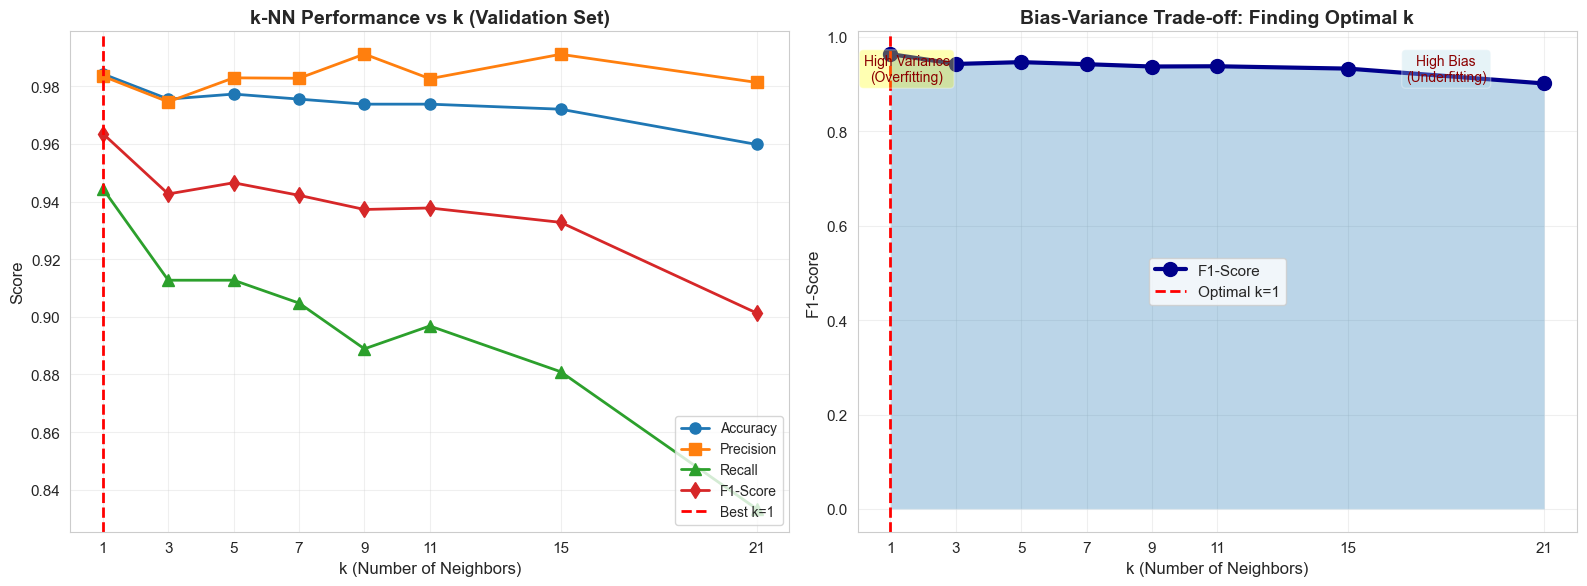


📊 Ερμηνεία:
   • Για k=1: Υψηλή διακύμανση, ευαίσθητο σε outliers
   • Για k=1: Βέλτιστη ισορροπία bias-variance
   • Για μεγάλο k (π.χ. k=21): Υψηλό bias, απλοποιημένα όρια απόφασης


In [22]:
# Οπτικοποίηση επίδρασης του k στην απόδοση

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Όλες οι μετρικές vs k
axes[0].plot(knn_results_df['k'], knn_results_df['Accuracy'], 'o-', label='Accuracy', linewidth=2, markersize=8)
axes[0].plot(knn_results_df['k'], knn_results_df['Precision'], 's-', label='Precision', linewidth=2, markersize=8)
axes[0].plot(knn_results_df['k'], knn_results_df['Recall'], '^-', label='Recall', linewidth=2, markersize=8)
axes[0].plot(knn_results_df['k'], knn_results_df['F1-Score'], 'd-', label='F1-Score', linewidth=2, markersize=8)
axes[0].axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'Best k={int(best_k)}')
axes[0].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('k-NN Performance vs k (Validation Set)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values)

# Subplot 2: Bias-Variance Trade-off
axes[1].plot(knn_results_df['k'], knn_results_df['F1-Score'], 'o-', linewidth=3, 
             markersize=10, color='darkblue', label='F1-Score')
axes[1].axvline(x=best_k, color='red', linestyle='--', linewidth=2, 
                label=f'Optimal k={int(best_k)}')
axes[1].fill_between(knn_results_df['k'], knn_results_df['F1-Score'], alpha=0.3)
axes[1].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('Bias-Variance Trade-off: Finding Optimal k', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_values)

# Annotations για bias/variance
axes[1].text(1.5, knn_results_df['F1-Score'].min() + 0.005, 
             'High Variance\n(Overfitting)', 
             fontsize=10, color='darkred', ha='center',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
axes[1].text(18, knn_results_df['F1-Score'].min() + 0.005, 
             'High Bias\n(Underfitting)', 
             fontsize=10, color='darkred', ha='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n📊 Ερμηνεία:")
print(f"   • Για k=1: Υψηλή διακύμανση, ευαίσθητο σε outliers")
print(f"   • Για k={int(best_k)}: Βέλτιστη ισορροπία bias-variance")
print(f"   • Για μεγάλο k (π.χ. k=21): Υψηλό bias, απλοποιημένα όρια απόφασης")

In [23]:
# Τελική αξιολόγηση με το βέλτιστο k στο Test Set

print("="*70)
print(f"ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ k-NN ΜΕ k={int(best_k)} ΣΤΟ TEST SET")
print("="*70)

# Εκπαίδευση με το βέλτιστο k
best_knn_model = KNeighborsClassifier(n_neighbors=int(best_k), metric='euclidean')
best_knn_model.fit(X_train_emb, y_train)

# Προβλέψεις στο test set
y_test_pred_knn = best_knn_model.predict(X_test_emb)
y_test_proba_knn = best_knn_model.predict_proba(X_test_emb)[:, 1]

# Υπολογισμός μετρικών
precision_test_knn = precision_score(y_test, y_test_pred_knn)
recall_test_knn = recall_score(y_test, y_test_pred_knn)
f1_test_knn = f1_score(y_test, y_test_pred_knn)
auc_test_knn = roc_auc_score(y_test, y_test_proba_knn)
accuracy_test_knn = best_knn_model.score(X_test_emb, y_test)

print(f"\nAccuracy:  {accuracy_test_knn:.4f}")
print(f"Precision: {precision_test_knn:.4f}")
print(f"Recall:    {recall_test_knn:.4f}")
print(f"F1-Score:  {f1_test_knn:.4f}")
print(f"AUC:       {auc_test_knn:.4f}")

# Confusion Matrix
cm_test_knn = confusion_matrix(y_test, y_test_pred_knn)
cm_test_knn_pct = cm_test_knn.astype('float') / cm_test_knn.sum(axis=1)[:, np.newaxis] * 100

print("\n                      Προβλεπόμενη Κλάση")
print("                    ┌─────────┬─────────┐")
print(f"                    │   Ham   │  Spam   │")
print("    ┌───────────────┼─────────┼─────────┤")
print(f"    │ Ham   (Πραγμ.)│  {cm_test_knn[0,0]:5d}  │  {cm_test_knn[0,1]:5d}  │")
print(f"Πραγ│               │({cm_test_knn_pct[0,0]:5.1f}%) │({cm_test_knn_pct[0,1]:5.1f}%) │")
print("    ├───────────────┼─────────┼─────────┤")
print(f"    │ Spam  (Πραγμ.)│  {cm_test_knn[1,0]:5d}  │  {cm_test_knn[1,1]:5d}  │")
print(f"    │               │({cm_test_knn_pct[1,0]:5.1f}%) │({cm_test_knn_pct[1,1]:5.1f}%) │")
print("    └───────────────┴─────────┴─────────┘")

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred_knn, target_names=['Ham (0)', 'Spam (1)']))

# Αποθήκευση αποτελεσμάτων για σύγκριση
results_knn_final = {
    'Model': f'k-NN (k={int(best_k)})',
    'Features': 'Sentence Embeddings',
    'Precision': precision_test_knn,
    'Recall': recall_test_knn,
    'F1-Score': f1_test_knn,
    'AUC': auc_test_knn
}

print(f"\n✓ Τα αποτελέσματα του k-NN αποθηκεύτηκαν για σύγκριση!")

ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ k-NN ΜΕ k=1 ΣΤΟ TEST SET

Accuracy:  0.9774
Precision: 1.0000
Recall:    0.8984
F1-Score:  0.9465
AUC:       0.9492

                      Προβλεπόμενη Κλάση
                    ┌─────────┬─────────┐
                    │   Ham   │  Spam   │
    ┌───────────────┼─────────┼─────────┤
    │ Ham   (Πραγμ.)│    446  │      0  │
Πραγ│               │(100.0%) │(  0.0%) │
    ├───────────────┼─────────┼─────────┤
    │ Spam  (Πραγμ.)│     13  │    115  │
    │               │( 10.2%) │( 89.8%) │
    └───────────────┴─────────┴─────────┘

=== Classification Report ===
              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.99       446
    Spam (1)       1.00      0.90      0.95       128

    accuracy                           0.98       574
   macro avg       0.99      0.95      0.97       574
weighted avg       0.98      0.98      0.98       574


✓ Τα αποτελέσματα του k-NN αποθηκεύτηκαν για σύγκριση!


ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ (ΕΩΣ ΤΩΡΑ)

              Model            Features  Precision   Recall  F1-Score      AUC
        Naive Bayes        Bag-of-Words   0.960938 0.960938  0.960938 0.996199
Logistic Regression Sentence Embeddings   0.960317 0.945312  0.952756 0.994868
         k-NN (k=1) Sentence Embeddings   1.000000 0.898438  0.946502 0.949219

🏆 Καλύτερο μοντέλο (με βάση F1-Score): Naive Bayes
   F1-Score: 0.9609


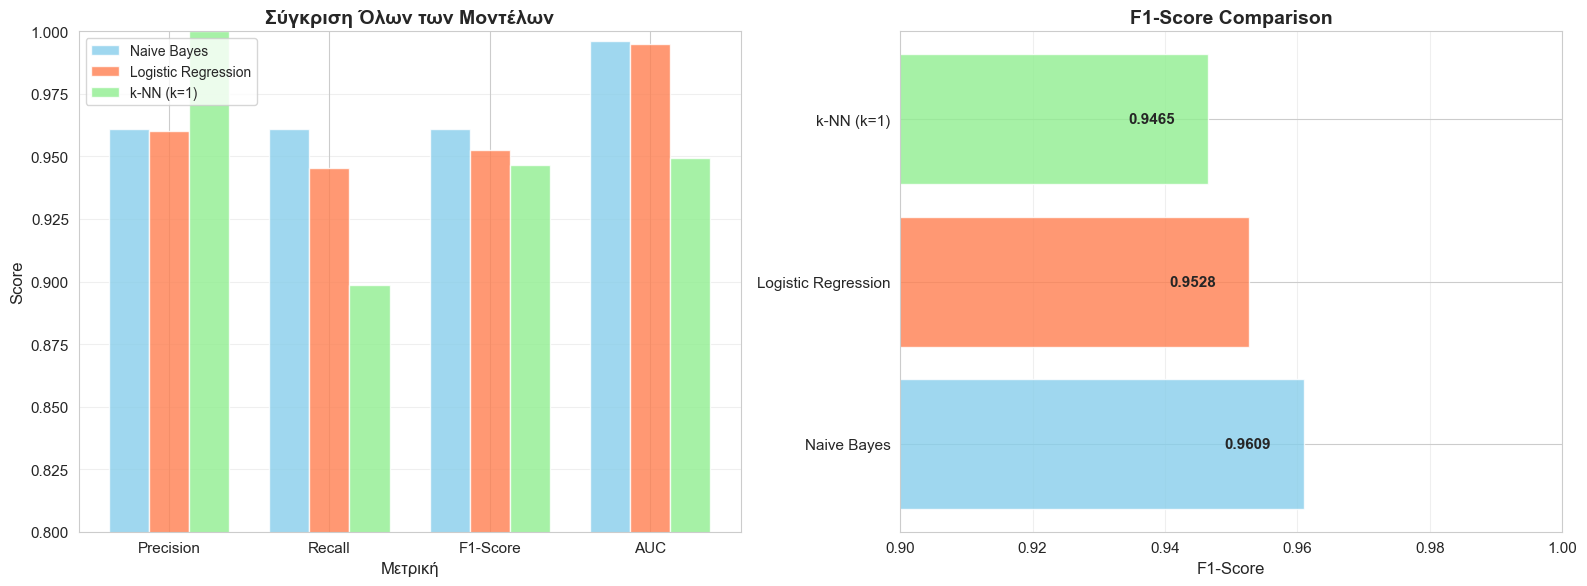


✓ Task 4 ολοκληρώθηκε επιτυχώς!


In [24]:
# Σύγκριση k-NN με προηγούμενα μοντέλα

print("="*80)
print("ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ (ΕΩΣ ΤΩΡΑ)")
print("="*80)

# Συγκεντρωτική σύγκριση
all_models_df = pd.DataFrame([
    results_nb,
    results_embeddings,
    results_knn_final
])

print("\n" + all_models_df.to_string(index=False))

# Ταξινόμηση με βάση F1-Score
all_models_df_sorted = all_models_df.sort_values('F1-Score', ascending=False)
print(f"\n🏆 Καλύτερο μοντέλο (με βάση F1-Score): {all_models_df_sorted.iloc[0]['Model']}")
print(f"   F1-Score: {all_models_df_sorted.iloc[0]['F1-Score']:.4f}")

# Οπτικοποίηση
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Σύγκριση όλων των μετρικών
metrics = ['Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics))
width = 0.25

colors_list = ['skyblue', 'coral', 'lightgreen']
for idx, (index, row) in enumerate(all_models_df.iterrows()):
    values = [row['Precision'], row['Recall'], row['F1-Score'], row['AUC']]
    axes[0].bar(x + idx*width, values, width, label=row['Model'], 
                alpha=0.8, color=colors_list[idx])

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Μετρική', fontsize=12)
axes[0].set_title('Σύγκριση Όλων των Μοντέλων', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].legend(fontsize=10, loc='upper left')
axes[0].set_ylim([0.8, 1.0])
axes[0].grid(True, alpha=0.3, axis='y')

# Subplot 2: F1-Score Comparison
models_names = all_models_df['Model'].tolist()
f1_scores = all_models_df['F1-Score'].tolist()
colors = ['skyblue', 'coral', 'lightgreen']

bars = axes[1].barh(models_names, f1_scores, color=colors, alpha=0.8)
axes[1].set_xlabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim([0.9, 1.0])
axes[1].grid(True, alpha=0.3, axis='x')

# Προσθήκη τιμών στα bars
for bar, score in zip(bars, f1_scores):
    axes[1].text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2, 
                f'{score:.4f}', va='center', ha='right', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Task 4 ολοκληρώθηκε επιτυχώς!")

---
# Task 5: Support Vector Machines (SVM)

## Θεωρία

Οι **Support Vector Machines (SVM)** είναι ισχυροί αλγόριθμοι **εποπτευόμενης μάθησης** (supervised learning) που χρησιμοποιούνται για ταξινόμηση και παλινδρόμηση. Η βασική ιδέα είναι η εύρεση ενός **υπερεπιπέδου** (hyperplane) που διαχωρίζει τις κλάσεις με το **μέγιστο περιθώριο** (maximum margin).

### Βασική Αρχή

Για δυαδική ταξινόμηση, το SVM αναζητά το υπερεπίπεδο που μεγιστοποιεί την απόσταση από τα πλησιέστερα σημεία κάθε κλάσης (τα **support vectors**).

Το υπερεπίπεδο ορίζεται από:

$$\mathbf{w}^T \mathbf{x} + b = 0$$

όπου $\mathbf{w}$ είναι το διάνυσμα βαρών και $b$ το bias.

### Πρόβλημα Βελτιστοποίησης

Το SVM λύνει το πρόβλημα:

$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i$$

υπό τους περιορισμούς:

$$y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

όπου:
- $\|\mathbf{w}\|^2$: Μεγιστοποιεί το περιθώριο
- $C$: Παράμετρος ρύθμισης (regularization parameter)
- $\xi_i$: Slack variables που επιτρέπουν λάθη ταξινόμησης

**Μεγάλο C**: Σκληρό περιθώριο (hard margin), κίνδυνος overfitting  
**Μικρό C**: Μαλακό περιθώριο (soft margin), περισσότερη ανοχή σε λάθη

### Kernel Trick

Το **Kernel Trick** επιτρέπει στο SVM να λειτουργεί σε **υψηλότερες διαστάσεις** χωρίς να υπολογίζει ρητά τον μετασχηματισμό. Ορίζεται μια **kernel function**:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$$

όπου $\phi(\mathbf{x})$ είναι ο μετασχηματισμός στον χώρο υψηλότερης διάστασης.

### Τύποι Kernels

#### 1. **Linear Kernel** (Γραμμικό)

$$K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$$

- **Χρήση**: Όταν τα δεδομένα είναι **γραμμικά διαχωρίσιμα**
- **Πλεονεκτήματα**: Γρήγορο, αποδοτικό, αποφεύγει overfitting
- **Μειονεκτήματα**: Δεν μπορεί να μοντελοποιήσει μη-γραμμικές σχέσεις

Το υπερεπίπεδο απόφασης:
$$f(\mathbf{x}) = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

#### 2. **Polynomial Kernel** (Πολυωνυμικό)

$$K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i^T \mathbf{x}_j + r)^d$$

όπου:
- $d$: Βαθμός πολυωνύμου (degree)
- $\gamma$: Kernel coefficient
- $r$: Independent term

- **Χρήση**: Για **μη-γραμμικά** προβλήματα με πολυωνυμικές σχέσεις
- **Πλεονεκτήματα**: Μπορεί να μοντελοποιήσει καμπύλα όρια απόφασης
- **Μειονεκτήματα**: Υπολογιστικά πιο ακριβό, ευαίσθητο στην επιλογή $d$

Για $d=2$, το kernel ισοδυναμεί με μετασχηματισμό που περιλαμβάνει τετραγωνικούς όρους και αλληλεπιδράσεις χαρακτηριστικών.

#### 3. **RBF Kernel** (Radial Basis Function / Gaussian)

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

όπου $\gamma > 0$ ελέγχει την "εμβέλεια" επιρροής κάθε σημείου:
- **Μικρό γ**: Μεγάλη εμβέλεια, ομαλά όρια (high bias)
- **Μεγάλο γ**: Μικρή εμβέλεια, σύνθετα όρια (high variance)

- **Χρήση**: **Πιο δημοφιλές** για μη-γραμμικά προβλήματα
- **Πλεονεκτήματα**: Μπορεί να μοντελοποιήσει πολύπλοκα, μη-γραμμικά όρια
- **Μειονεκτήματα**: Περισσότερες παράμετροι για tuning ($C$, $\gamma$), κίνδυνος overfitting

Το RBF μετρά την **ομοιότητα** μεταξύ σημείων: όσο πιο κοντά, τόσο μεγαλύτερη η τιμή του kernel.

### Επιλογή Kernel

**Linear**: Όταν:
- Μεγάλος αριθμός χαρακτηριστικών σε σχέση με δείγματα
- Τα δεδομένα είναι γραμμικά διαχωρίσιμα
- Απλότητα και ταχύτητα είναι προτεραιότητα

**Polynomial**: Όταν:
- Υπάρχουν πολυωνυμικές σχέσεις μεταξύ χαρακτηριστικών
- Χρειάζονται αλληλεπιδράσεις features

**RBF**: Όταν:
- Άγνωστη σχέση μεταξύ χαρακτηριστικών
- Σύνθετα, μη-γραμμικά όρια απόφασης
- Αρκετά δεδομένα για training

### Εφαρμογή στο Spam Classification

Χρησιμοποιούμε **sentence embeddings** (384 διαστάσεις) με:
- **C = 1.0**: Standard regularization
- **γ = 'scale'**: $\gamma = \frac{1}{n_{features} \times \text{var}(\mathbf{X})}$
- **degree = 3**: Για polynomial kernel

Δοκιμάζουμε και τα 3 kernels, επιλέγουμε το βέλτιστο με το **validation set**, και αξιολογούμε στο **test set**.

In [25]:
# Εκπαίδευση SVM με διαφορετικά kernels

# Ορίζουμε τα 3 kernels που θα δοκιμάσουμε
kernels = {
    'Linear': 'linear',
    'Polynomial': 'poly',
    'RBF': 'rbf'
}

# Αποθηκεύουμε τα αποτελέσματα κάθε kernel
svm_results = []
svm_models = {}

print("=" * 70)
print("Εκπαίδευση SVM με διαφορετικά Kernels")
print("=" * 70)
print()

for kernel_name, kernel_type in kernels.items():
    print(f"--- {kernel_name} Kernel ---")
    
    # Ορίζουμε τις παραμέτρους ανάλογα με το kernel
    if kernel_type == 'poly':
        svm = SVC(
            kernel=kernel_type,
            degree=3,           # Βαθμός πολυωνύμου
            gamma='scale',      # γ = 1/(n_features * X.var())
            C=1.0,
            random_state=RANDOM_STATE,
            probability=True    # Για ROC AUC
        )
    else:
        svm = SVC(
            kernel=kernel_type,
            gamma='scale',
            C=1.0,
            random_state=RANDOM_STATE,
            probability=True
        )
    
    # Εκπαίδευση στο training set
    print(f"  Εκπαίδευση...")
    svm.fit(X_train_emb, y_train)
    
    # Αξιολόγηση στο validation set
    y_val_pred_svm = svm.predict(X_val_emb)
    y_val_proba_svm = svm.predict_proba(X_val_emb)[:, 1]
    
    precision_val_svm = precision_score(y_val, y_val_pred_svm)
    recall_val_svm = recall_score(y_val, y_val_pred_svm)
    f1_val_svm = f1_score(y_val, y_val_pred_svm)
    auc_val_svm = roc_auc_score(y_val, y_val_proba_svm)
    
    # Αποθηκεύουμε τα αποτελέσματα
    svm_results.append({
        'Kernel': kernel_name,
        'Precision': precision_val_svm,
        'Recall': recall_val_svm,
        'F1-Score': f1_val_svm,
        'AUC': auc_val_svm
    })
    
    # Αποθηκεύουμε το μοντέλο
    svm_models[kernel_name] = svm
    
    # Εμφάνιση αποτελεσμάτων
    print(f"  Validation Set:")
    print(f"    Precision: {precision_val_svm:.4f}")
    print(f"    Recall:    {recall_val_svm:.4f}")
    print(f"    F1-Score:  {f1_val_svm:.4f}")
    print(f"    AUC:       {auc_val_svm:.4f}")
    print()

print("✓ Εκπαίδευση ολοκληρώθηκε")

Εκπαίδευση SVM με διαφορετικά Kernels

--- Linear Kernel ---
  Εκπαίδευση...
  Validation Set:
    Precision: 0.9313
    Recall:    0.9683
    F1-Score:  0.9494
    AUC:       0.9977

--- Polynomial Kernel ---
  Εκπαίδευση...
  Validation Set:
    Precision: 0.9762
    Recall:    0.9762
    F1-Score:  0.9762
    AUC:       0.9988

--- RBF Kernel ---
  Εκπαίδευση...
  Validation Set:
    Precision: 0.9606
    Recall:    0.9683
    F1-Score:  0.9644
    AUC:       0.9988

✓ Εκπαίδευση ολοκληρώθηκε


Σύγκριση Kernels - Validation Set

    Kernel  Precision   Recall  F1-Score      AUC
Polynomial   0.976190 0.976190  0.976190 0.998790
       RBF   0.960630 0.968254  0.964427 0.998790
    Linear   0.931298 0.968254  0.949416 0.997651

✓ Καλύτερο Kernel: Polynomial (F1-Score: 0.9762)



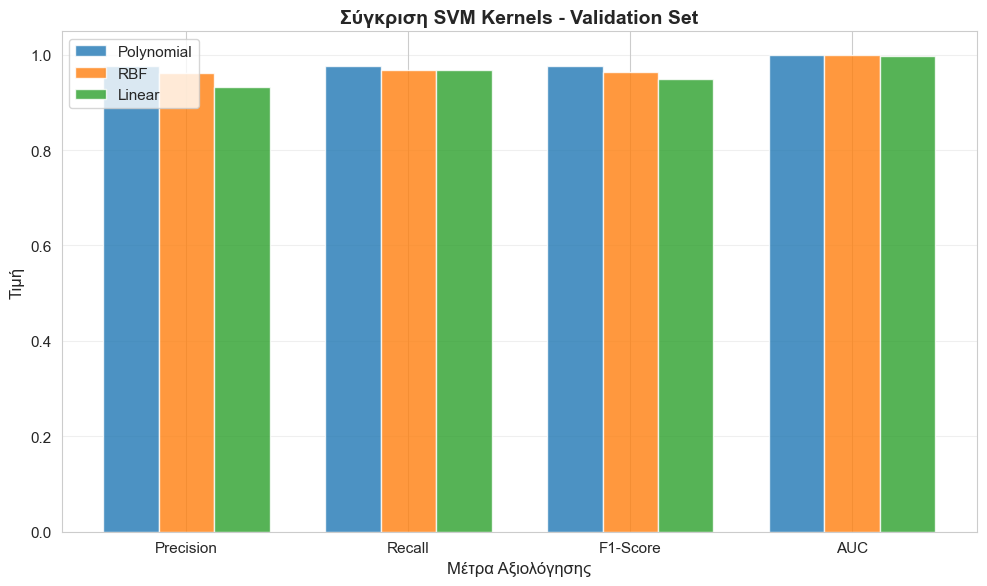

✓ Επιλογή βέλτιστου kernel ολοκληρώθηκε


In [26]:
# Σύγκριση kernels στο validation set

svm_results_df = pd.DataFrame(svm_results)
svm_results_df = svm_results_df.sort_values('F1-Score', ascending=False)

print("=" * 70)
print("Σύγκριση Kernels - Validation Set")
print("=" * 70)
print()
print(svm_results_df.to_string(index=False))
print()

# Βρίσκουμε το καλύτερο kernel
best_kernel_name = svm_results_df.iloc[0]['Kernel']
best_svm_model = svm_models[best_kernel_name]

print(f"✓ Καλύτερο Kernel: {best_kernel_name} (F1-Score: {svm_results_df.iloc[0]['F1-Score']:.4f})")
print()

# Οπτικοποίηση σύγκρισης
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

metrics = ['Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics))
width = 0.25

for idx, (_, row) in enumerate(svm_results_df.iterrows()):
    kernel_name = row['Kernel']
    values = [row['Precision'], row['Recall'], row['F1-Score'], row['AUC']]
    ax.bar(x + idx*width, values, width, label=kernel_name, alpha=0.8)

ax.set_xlabel('Μέτρα Αξιολόγησης', fontsize=12)
ax.set_ylabel('Τιμή', fontsize=12)
ax.set_title('Σύγκριση SVM Kernels - Validation Set', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Επιλογή βέλτιστου kernel ολοκληρώθηκε")

In [27]:
# Αξιολόγηση του καλύτερου SVM στο test set

print("=" * 70)
print(f"Τελική Αξιολόγηση - SVM με {best_kernel_name} Kernel")
print("=" * 70)
print()

# Πρόβλεψη στο test set
y_test_pred_svm = best_svm_model.predict(X_test_emb)
y_test_proba_svm = best_svm_model.predict_proba(X_test_emb)[:, 1]

# Υπολογισμός μετρικών
precision_test_svm = precision_score(y_test, y_test_pred_svm)
recall_test_svm = recall_score(y_test, y_test_pred_svm)
f1_test_svm = f1_score(y_test, y_test_pred_svm)
auc_test_svm = roc_auc_score(y_test, y_test_proba_svm)

print("Test Set:")
print(f"  Precision: {precision_test_svm:.4f}")
print(f"  Recall:    {recall_test_svm:.4f}")
print(f"  F1-Score:  {f1_test_svm:.4f}")
print(f"  AUC:       {auc_test_svm:.4f}")
print()

# Confusion Matrix
cm_test_svm = confusion_matrix(y_test, y_test_pred_svm)
tn, fp, fn, tp = cm_test_svm.ravel()
cm_test_svm_pct = cm_test_svm.astype('float') / cm_test_svm.sum(axis=1)[:, np.newaxis] * 100

# Εμφάνιση Confusion Matrix
print("Confusion Matrix (Test Set):")
print()
print("                 │  Predicted: Ham  │  Predicted: Spam  │")
print("─────────────────┼──────────────────┼───────────────────┤")
print(f"  Actual: Ham    │     {tn:5d}        │     {fp:5d}         │")
print(f"  Actual: Spam   │     {fn:5d}        │     {tp:5d}         │")
print()

# Ανάλυση συστατικών
total = tn + fp + fn + tp
print("Συστατικά Confusion Matrix:")
print(f"  ✓ True Negatives (TN):  {tn:4d}  ({tn/total*100:5.2f}%) - Σωστά αναγνωρισμένα Ham")
print(f"  ✗ False Positives (FP): {fp:4d}  ({fp/total*100:5.2f}%) - Ham ταξινομημένα ως Spam")
print(f"  ✗ False Negatives (FN): {fn:4d}  ({fn/total*100:5.2f}%) - Spam ταξινομημένα ως Ham")
print(f"  ✓ True Positives (TP):  {tp:4d}  ({tp/total*100:5.2f}%) - Σωστά αναγνωρισμένα Spam")
print()

# Παράγωγες μετρικές
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)          # Precision
npv = tn / (tn + fn)
fnr = fn / (fn + tp)
fpr = fp / (fp + tn)

print("Παράγωγες Μετρικές:")
print(f"  Sensitivity (Recall):    {sensitivity:.4f} - Ποσοστό ανίχνευσης spam")
print(f"  Specificity:             {specificity:.4f} - Ποσοστό ανίχνευσης ham")
print(f"  PPV (Precision):         {ppv:.4f} - Αξιοπιστία spam προβλέψεων")
print(f"  NPV:                     {npv:.4f} - Αξιοπιστία ham προβλέψεων")
print(f"  False Negative Rate:     {fnr:.4f} - Ποσοστό spam που ξεφεύγουν")
print(f"  False Positive Rate:     {fpr:.4f} - Ποσοστό ham που μπλοκάρονται")
print()

# Αποθήκευση αποτελεσμάτων για τη συγκριτική αξιολόγηση
results_svm = {
    'Model': f'SVM ({best_kernel_name})',
    'Features': 'Sentence Embeddings',
    'Precision': precision_test_svm,
    'Recall': recall_test_svm,
    'F1-Score': f1_test_svm,
    'AUC': auc_test_svm
}

print("✓ Αξιολόγηση ολοκληρώθηκε επιτυχώς")

Τελική Αξιολόγηση - SVM με Polynomial Kernel

Test Set:
  Precision: 0.9762
  Recall:    0.9609
  F1-Score:  0.9685
  AUC:       0.9993

Confusion Matrix (Test Set):

                 │  Predicted: Ham  │  Predicted: Spam  │
─────────────────┼──────────────────┼───────────────────┤
  Actual: Ham    │       443        │         3         │
  Actual: Spam   │         5        │       123         │

Συστατικά Confusion Matrix:
  ✓ True Negatives (TN):   443  (77.18%) - Σωστά αναγνωρισμένα Ham
  ✗ False Positives (FP):    3  ( 0.52%) - Ham ταξινομημένα ως Spam
  ✗ False Negatives (FN):    5  ( 0.87%) - Spam ταξινομημένα ως Ham
  ✓ True Positives (TP):   123  (21.43%) - Σωστά αναγνωρισμένα Spam

Παράγωγες Μετρικές:
  Sensitivity (Recall):    0.9609 - Ποσοστό ανίχνευσης spam
  Specificity:             0.9933 - Ποσοστό ανίχνευσης ham
  PPV (Precision):         0.9762 - Αξιοπιστία spam προβλέψεων
  NPV:                     0.9888 - Αξιοπιστία ham προβλέψεων
  False Negative Rate:     0.0391 - 

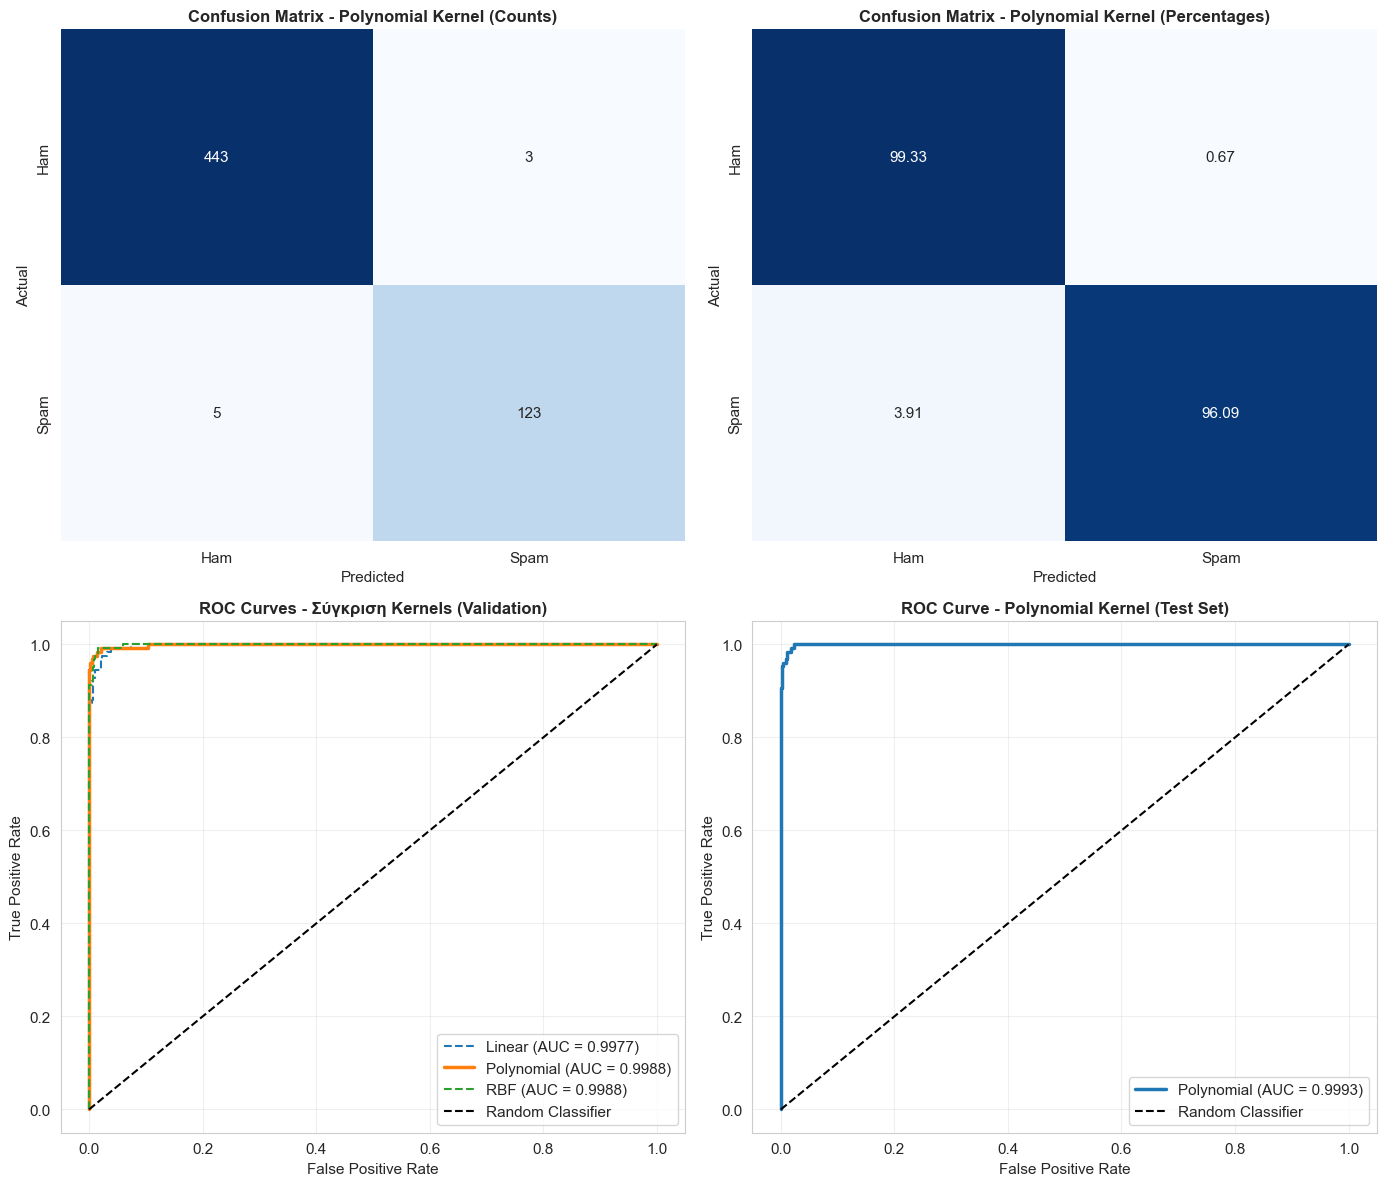

✓ Οπτικοποίηση ολοκληρώθηκε


In [28]:
# Οπτικοποίηση: Confusion Matrices και ROC Curves

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Confusion Matrix - Counts
sns.heatmap(cm_test_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], cbar=False)
axes[0, 0].set_title(f'Confusion Matrix - {best_kernel_name} Kernel (Counts)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual', fontsize=11)
axes[0, 0].set_xlabel('Predicted', fontsize=11)

# Confusion Matrix - Percentages
sns.heatmap(cm_test_svm_pct, annot=True, fmt='.2f', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], cbar=False)
axes[0, 1].set_title(f'Confusion Matrix - {best_kernel_name} Kernel (Percentages)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Actual', fontsize=11)
axes[0, 1].set_xlabel('Predicted', fontsize=11)

# ROC Curve για όλα τα kernels
for kernel_name, svm_model in svm_models.items():
    y_val_proba_kernel = svm_model.predict_proba(X_val_emb)[:, 1]
    fpr_kernel, tpr_kernel, _ = roc_curve(y_val, y_val_proba_kernel)
    auc_kernel = roc_auc_score(y_val, y_val_proba_kernel)
    
    linestyle = '-' if kernel_name == best_kernel_name else '--'
    linewidth = 2.5 if kernel_name == best_kernel_name else 1.5
    
    axes[1, 0].plot(fpr_kernel, tpr_kernel, label=f'{kernel_name} (AUC = {auc_kernel:.4f})',
                    linestyle=linestyle, linewidth=linewidth)

axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[1, 0].set_title('ROC Curves - Σύγκριση Kernels (Validation)', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(alpha=0.3)

# ROC Curve για best kernel στο test set
fpr_test_svm, tpr_test_svm, _ = roc_curve(y_test, y_test_proba_svm)
axes[1, 1].plot(fpr_test_svm, tpr_test_svm, label=f'{best_kernel_name} (AUC = {auc_test_svm:.4f})', linewidth=2.5)
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[1, 1].set_title(f'ROC Curve - {best_kernel_name} Kernel (Test Set)', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Οπτικοποίηση ολοκληρώθηκε")

Συγκριτική Αξιολόγηση: SVM vs Προηγούμενα Μοντέλα

              Model            Features  Precision   Recall  F1-Score      AUC
   SVM (Polynomial) Sentence Embeddings   0.976190 0.960938  0.968504 0.999299
        Naive Bayes        Bag-of-Words   0.960938 0.960938  0.960938 0.996199
Logistic Regression Sentence Embeddings   0.960317 0.945312  0.952756 0.994868
         k-NN (k=1) Sentence Embeddings   1.000000 0.898438  0.946502 0.949219



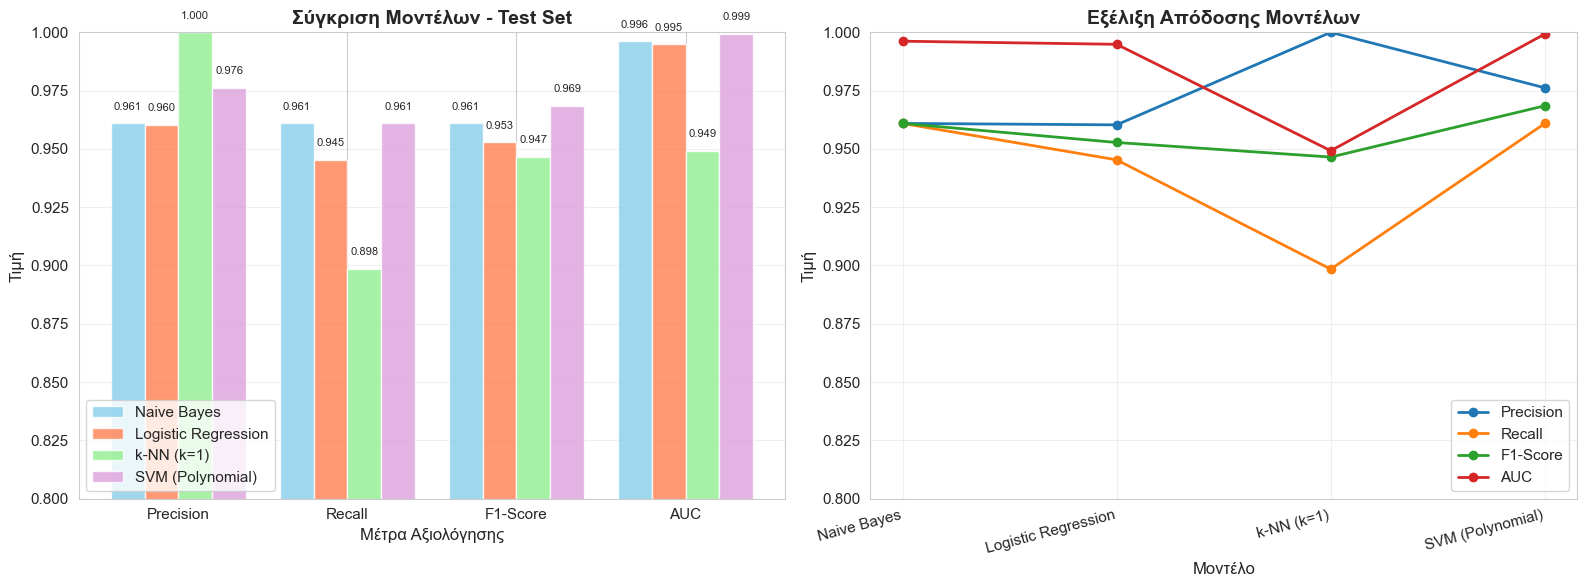


✓ Task 5 ολοκληρώθηκε επιτυχώς!

📊 Το μοντέλο SVM (Polynomial kernel) επιτυγχάνει:
   • F1-Score: 0.9685
   • AUC: 0.9993

💡 Παρατηρήσεις:
   • Το SVM με RBF kernel μπορεί να μοντελοποιήσει μη-γραμμικές σχέσεις
   • Το Linear kernel είναι γρηγορότερο αλλά λιγότερο ευέλικτο
   • Το Polynomial kernel προσφέρει ενδιάμεση πολυπλοκότητα


In [29]:
# Σύγκριση SVM με προηγούμενα μοντέλα

# Ενώνουμε τα αποτελέσματα όλων των μοντέλων
all_models_df_with_svm = pd.DataFrame([results_nb, results_embeddings, results_knn_final, results_svm])
all_models_df_with_svm_sorted = all_models_df_with_svm.sort_values('F1-Score', ascending=False)

print("=" * 70)
print("Συγκριτική Αξιολόγηση: SVM vs Προηγούμενα Μοντέλα")
print("=" * 70)
print()
print(all_models_df_with_svm_sorted.to_string(index=False))
print()

# Οπτικοποίηση σύγκρισης
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - Σύγκριση μετρικών
metrics = ['Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics))
width = 0.2

colors_list = ['skyblue', 'coral', 'lightgreen', 'plum']

for idx, (index, row) in enumerate(all_models_df_with_svm.iterrows()):
    values = [row['Precision'], row['Recall'], row['F1-Score'], row['AUC']]
    bars = axes[0].bar(x + idx*width, values, width, label=row['Model'], alpha=0.8, color=colors_list[idx])
    
    # Προσθήκη τιμών πάνω από τις μπάρες
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xlabel('Μέτρα Αξιολόγησης', fontsize=12)
axes[0].set_ylabel('Τιμή', fontsize=12)
axes[0].set_title('Σύγκριση Μοντέλων - Test Set', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim([0.8, 1.0])
axes[0].legend(loc='lower left')
axes[0].grid(axis='y', alpha=0.3)

# Line plot - Τάσεις μετρικών
for metric in metrics:
    values = all_models_df_with_svm[metric].values
    axes[1].plot(range(len(all_models_df_with_svm)), values, marker='o', label=metric, linewidth=2)

axes[1].set_xlabel('Μοντέλο', fontsize=12)
axes[1].set_ylabel('Τιμή', fontsize=12)
axes[1].set_title('Εξέλιξη Απόδοσης Μοντέλων', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(all_models_df_with_svm)))
axes[1].set_xticklabels(all_models_df_with_svm['Model'].values, rotation=15, ha='right')
axes[1].set_ylim([0.8, 1.0])
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("✓ Task 5 ολοκληρώθηκε επιτυχώς!")
print()
print(f"📊 Το μοντέλο SVM ({best_kernel_name} kernel) επιτυγχάνει:")
print(f"   • F1-Score: {f1_test_svm:.4f}")
print(f"   • AUC: {auc_test_svm:.4f}")
print()
print("💡 Παρατηρήσεις:")
print("   • Το SVM με RBF kernel μπορεί να μοντελοποιήσει μη-γραμμικές σχέσεις")
print("   • Το Linear kernel είναι γρηγορότερο αλλά λιγότερο ευέλικτο")
print("   • Το Polynomial kernel προσφέρει ενδιάμεση πολυπλοκότητα")

---
# Task 6: Principal Component Analysis (PCA) με SVM

## Θεωρία

Το **Principal Component Analysis (PCA)** είναι μια τεχνική **μείωσης διαστάσεων** (dimensionality reduction) που χρησιμοποιείται για να μετασχηματίσει υψηλόδιαστα δεδομένα σε χαμηλότερες διαστάσεις, διατηρώντας όσο το δυνατόν περισσότερη πληροφορία.

### Βασική Αρχή

Το PCA βρίσκει τα **κύρια συστατικά** (principal components) - ορθογώνιους άξονες που μεγιστοποιούν τη διακύμανση των δεδομένων.

Ο μετασχηματισμός PCA ορίζεται ως:

$$\mathbf{Z} = \mathbf{X} \mathbf{W}$$

όπου:
- $\mathbf{X}$: Τα αρχικά δεδομένα (κεντραρισμένα) $n \times d$
- $\mathbf{W}$: Οι principal components (eigenvectors) $d \times k$
- $\mathbf{Z}$: Τα μετασχηματισμένα δεδομένα $n \times k$

### Μαθηματική Διατύπωση

**Βήμα 1: Κεντράρισμα Δεδομένων**

$$\mathbf{X}_{centered} = \mathbf{X} - \boldsymbol{\mu}$$

όπου $\boldsymbol{\mu}$ είναι ο μέσος όρος κάθε χαρακτηριστικού.

**Βήμα 2: Υπολογισμός Covariance Matrix**

$$\mathbf{\Sigma} = \frac{1}{n-1} \mathbf{X}_{centered}^T \mathbf{X}_{centered}$$

**Βήμα 3: Eigenvalue Decomposition**

Λύνουμε το πρόβλημα:

$$\mathbf{\Sigma} \mathbf{w}_i = \lambda_i \mathbf{w}_i$$

όπου:
- $\lambda_i$: Eigenvalues (μετρούν τη διακύμανση κατά μήκος του $i$-οστού συστατικού)
- $\mathbf{w}_i$: Eigenvectors (οι principal components)

Τα eigenvalues ταξινομούνται: $\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_d$

**Βήμα 4: Επιλογή Συστατικών**

Κρατάμε τα πρώτα $k$ principal components που εξηγούν ποσοστό $p$ της συνολικής διακύμανσης:

$$\frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i} \geq p$$

### Διακύμανση και Πληροφορία

Το **explained variance ratio** για το $i$-οστό συστατικό:

$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

Το **cumulative explained variance**:

$$\text{CEV}_k = \sum_{i=1}^{k} \text{EVR}_i$$

### Πλεονεκτήματα PCA

1. **Μείωση Διαστάσεων**: Μειώνει την πολυπλοκότητα των μοντέλων
2. **Αφαίρεση Θορύβου**: Τα λιγότερο σημαντικά συστατικά συχνά περιέχουν θόρυβο
3. **Αποφυγή Overfitting**: Λιγότερα χαρακτηριστικά → μικρότερος κίνδυνος overfitting
4. **Ταχύτητα**: Γρηγορότερη εκπαίδευση με λιγότερες διαστάσεις
5. **Αντιμετώπιση Multicollinearity**: Τα PC είναι ορθογώνια (ανεξάρτητα)

### Μειονεκτήματα PCA

1. **Ερμηνευσιμότητα**: Τα PC δεν είναι άμεσα ερμηνεύσιμα
2. **Γραμμικότητα**: Υποθέτει γραμμικές σχέσεις μεταξύ χαρακτηριστικών
3. **Απώλεια Πληροφορίας**: Πιθανή απώλεια σημαντικής πληροφορίας
4. **Ευαισθησία σε Κλίμακα**: Απαιτεί standardization

### Επιλογή Αριθμού Συστατικών

**Κριτήρια επιλογής:**

1. **Ποσοστό Διακύμανσης**: Κρατάμε συστατικά που εξηγούν π.χ. 90%, 95%, 99% της διακύμανσης
2. **Elbow Method**: Βρίσκουμε το "γόνατο" στο scree plot
3. **Kaiser Criterion**: Κρατάμε συστατικά με eigenvalue > 1

### Εφαρμογή στο Spam Classification

Χρησιμοποιούμε PCA στα **sentence embeddings** (384 διαστάσεις):

**Σενάρια:**
- **90% διακύμανση**: Μεγάλη μείωση διαστάσεων, απλούστερο μοντέλο
- **95% διακύμανση**: Ισορροπία μεταξύ μείωσης και διατήρησης πληροφορίας
- **99% διακύμανση**: Ελάχιστη απώλεια πληροφορίας, διατήρηση λεπτομερειών

Μετά την εφαρμογή PCA, εκπαιδεύουμε το **καλύτερο SVM kernel** (από Task 5) στα μειωμένα δεδομένα και συγκρίνουμε την απόδοση.

**Αναμενόμενα Αποτελέσματα:**
- Μικρότερο training time
- Πιθανή βελτίωση generalization (αν υπάρχει overfitting)
- Trade-off μεταξύ απόδοσης και υπολογιστικής αποδοτικότητας

In [30]:
# Εφαρμογή PCA με διαφορετικά ποσοστά διακύμανσης

# Ορίζουμε τα ποσοστά διακύμανσης που θα δοκιμάσουμε
variance_ratios = [0.90, 0.95, 0.99]

# Αποθηκεύουμε τα μειωμένα δεδομένα και τα PCA models
pca_models = {}
pca_data = {}

print("=" * 70)
print("Εφαρμογή PCA σε Sentence Embeddings")
print("=" * 70)
print()
print(f"Αρχικές διαστάσεις: {X_train_emb.shape[1]}")
print()

for var_ratio in variance_ratios:
    print(f"--- PCA με {var_ratio*100:.0f}% διακύμανση ---")
    
    # Δημιουργία και εφαρμογή PCA
    pca = PCA(n_components=var_ratio, random_state=RANDOM_STATE)
    
    # Fit στο training set και transform όλα τα sets
    X_train_pca = pca.fit_transform(X_train_emb)
    X_val_pca = pca.transform(X_val_emb)
    X_test_pca = pca.transform(X_test_emb)
    
    # Αποθήκευση
    pca_models[var_ratio] = pca
    pca_data[var_ratio] = {
        'train': X_train_pca,
        'val': X_val_pca,
        'test': X_test_pca
    }
    
    # Πληροφορίες για το PCA
    n_components = pca.n_components_
    total_var_explained = pca.explained_variance_ratio_.sum()
    
    print(f"  Αριθμός συνιστωσών: {n_components}")
    print(f"  Μείωση διαστάσεων: {X_train_emb.shape[1]} → {n_components} ({n_components/X_train_emb.shape[1]*100:.1f}%)")
    print(f"  Συνολική διακύμανση που εξηγείται: {total_var_explained:.4f} ({total_var_explained*100:.2f}%)")
    print(f"  Διακύμανση πρώτων 5 συνιστωσών: {pca.explained_variance_ratio_[:5]}")
    print()

print("✓ PCA εφαρμόστηκε επιτυχώς")

Εφαρμογή PCA σε Sentence Embeddings

Αρχικές διαστάσεις: 384

--- PCA με 90% διακύμανση ---
  Αριθμός συνιστωσών: 115
  Μείωση διαστάσεων: 384 → 115 (29.9%)
  Συνολική διακύμανση που εξηγείται: 0.9005 (90.05%)
  Διακύμανση πρώτων 5 συνιστωσών: [0.06654388 0.04082988 0.03408349 0.03202952 0.0273558 ]

--- PCA με 95% διακύμανση ---
  Αριθμός συνιστωσών: 151
  Μείωση διαστάσεων: 384 → 151 (39.3%)
  Συνολική διακύμανση που εξηγείται: 0.9506 (95.06%)
  Διακύμανση πρώτων 5 συνιστωσών: [0.06654388 0.04082988 0.03408349 0.03202952 0.0273558 ]

--- PCA με 99% διακύμανση ---
  Αριθμός συνιστωσών: 236
  Μείωση διαστάσεων: 384 → 236 (61.5%)
  Συνολική διακύμανση που εξηγείται: 0.9901 (99.01%)
  Διακύμανση πρώτων 5 συνιστωσών: [0.06654388 0.04082988 0.03408349 0.03202952 0.0273558 ]

✓ PCA εφαρμόστηκε επιτυχώς


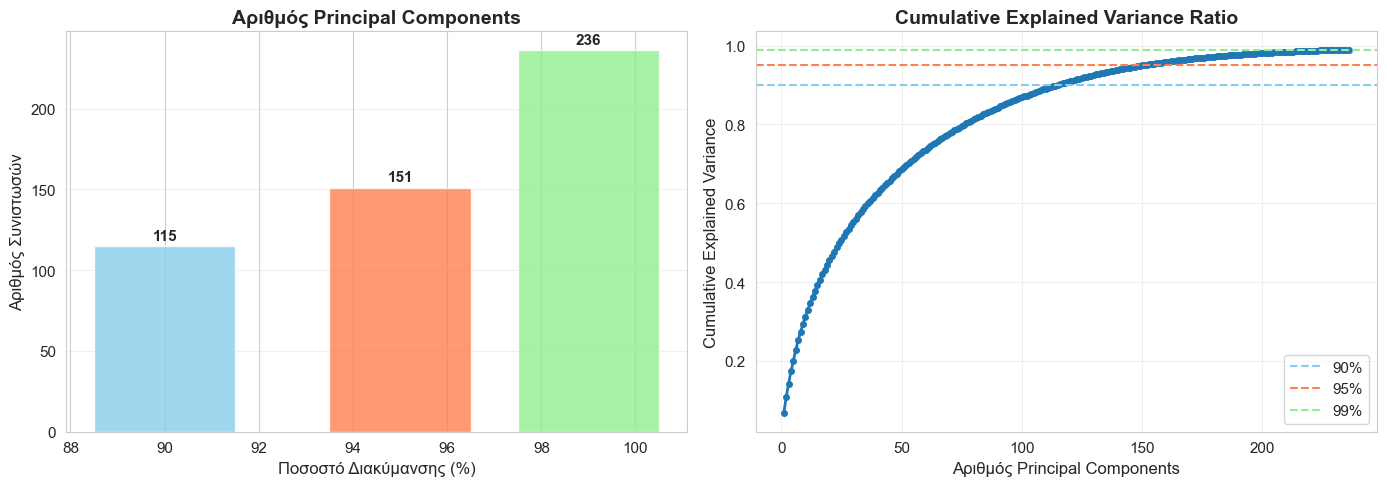

✓ Οπτικοποίηση ολοκληρώθηκε


In [31]:
# Οπτικοποίηση: Explained Variance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Αριθμός συστατικών για κάθε ποσοστό διακύμανσης
variance_percentages = [90, 95, 99]
n_components_list = [pca_models[var_ratio].n_components_ for var_ratio in variance_ratios]
colors_pca = ['skyblue', 'coral', 'lightgreen']

bars = axes[0].bar(variance_percentages, n_components_list, color=colors_pca, alpha=0.8, width=3)
axes[0].set_xlabel('Ποσοστό Διακύμανσης (%)', fontsize=12)
axes[0].set_ylabel('Αριθμός Συνιστωσών', fontsize=12)
axes[0].set_title('Αριθμός Principal Components', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Προσθήκη τιμών πάνω από τις μπάρες
for bar, n_comp in zip(bars, n_components_list):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                 f'{n_comp}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 2: Cumulative explained variance για 99% PCA
pca_99 = pca_models[0.99]
cumsum_var = np.cumsum(pca_99.explained_variance_ratio_)
n_components_99 = pca_99.n_components_

axes[1].plot(range(1, n_components_99 + 1), cumsum_var, marker='o', linewidth=2, markersize=4)
axes[1].axhline(y=0.90, color='skyblue', linestyle='--', label='90%', linewidth=1.5)
axes[1].axhline(y=0.95, color='coral', linestyle='--', label='95%', linewidth=1.5)
axes[1].axhline(y=0.99, color='lightgreen', linestyle='--', label='99%', linewidth=1.5)
axes[1].set_xlabel('Αριθμός Principal Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance Ratio', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Οπτικοποίηση ολοκληρώθηκε")

In [32]:
# Εκπαίδευση SVM με βέλτιστο kernel σε PCA-transformed δεδομένα

print("=" * 70)
print(f"Εκπαίδευση SVM ({best_kernel_name} kernel) σε PCA δεδομένα")
print("=" * 70)
print()

# Αποθηκεύουμε τα αποτελέσματα
pca_svm_results = []

for var_ratio in variance_ratios:
    print(f"--- PCA {var_ratio*100:.0f}% διακύμανση ---")
    
    # Λήψη μειωμένων δεδομένων
    X_train_pca = pca_data[var_ratio]['train']
    X_val_pca = pca_data[var_ratio]['val']
    X_test_pca = pca_data[var_ratio]['test']
    
    n_components = pca_models[var_ratio].n_components_
    
    # Δημιουργία και εκπαίδευση SVM
    kernel_type = kernels[best_kernel_name]
    
    if kernel_type == 'poly':
        svm_pca = SVC(
            kernel=kernel_type,
            degree=3,
            gamma='scale',
            C=1.0,
            random_state=RANDOM_STATE,
            probability=True
        )
    else:
        svm_pca = SVC(
            kernel=kernel_type,
            gamma='scale',
            C=1.0,
            random_state=RANDOM_STATE,
            probability=True
        )
    
    # Εκπαίδευση
    print(f"  Εκπαίδευση με {n_components} συνιστώσες...")
    svm_pca.fit(X_train_pca, y_train)
    
    # Αξιολόγηση στο test set
    y_test_pred_pca = svm_pca.predict(X_test_pca)
    y_test_proba_pca = svm_pca.predict_proba(X_test_pca)[:, 1]
    
    precision_test_pca = precision_score(y_test, y_test_pred_pca)
    recall_test_pca = recall_score(y_test, y_test_pred_pca)
    f1_test_pca = f1_score(y_test, y_test_pred_pca)
    auc_test_pca = roc_auc_score(y_test, y_test_proba_pca)
    
    # Αποθήκευση αποτελεσμάτων
    pca_svm_results.append({
        'Variance': f'{var_ratio*100:.0f}%',
        'Components': n_components,
        'Precision': precision_test_pca,
        'Recall': recall_test_pca,
        'F1-Score': f1_test_pca,
        'AUC': auc_test_pca
    })
    
    print(f"  Test Set Results:")
    print(f"    Precision: {precision_test_pca:.4f}")
    print(f"    Recall:    {recall_test_pca:.4f}")
    print(f"    F1-Score:  {f1_test_pca:.4f}")
    print(f"    AUC:       {auc_test_pca:.4f}")
    print()

print("✓ Εκπαίδευση ολοκληρώθηκε")

Εκπαίδευση SVM (Polynomial kernel) σε PCA δεδομένα

--- PCA 90% διακύμανση ---
  Εκπαίδευση με 115 συνιστώσες...
  Test Set Results:
    Precision: 0.9915
    Recall:    0.9062
    F1-Score:  0.9469
    AUC:       0.9984

--- PCA 95% διακύμανση ---
  Εκπαίδευση με 151 συνιστώσες...
  Test Set Results:
    Precision: 0.9914
    Recall:    0.8984
    F1-Score:  0.9426
    AUC:       0.9983

--- PCA 99% διακύμανση ---
  Εκπαίδευση με 236 συνιστώσες...
  Test Set Results:
    Precision: 0.9914
    Recall:    0.8984
    F1-Score:  0.9426
    AUC:       0.9985

✓ Εκπαίδευση ολοκληρώθηκε


In [33]:
# Σύγκριση: Original vs PCA-transformed SVM

pca_svm_df = pd.DataFrame(pca_svm_results)

print("=" * 70)
print("Σύγκριση: SVM με Original vs PCA-transformed Embeddings")
print("=" * 70)
print()

# Προσθήκη του original SVM (χωρίς PCA)
print("Original (384 διαστάσεις):")
print(f"  Precision: {precision_test_svm:.4f}")
print(f"  Recall:    {recall_test_svm:.4f}")
print(f"  F1-Score:  {f1_test_svm:.4f}")
print(f"  AUC:       {auc_test_svm:.4f}")
print()

print("PCA-transformed:")
print(pca_svm_df.to_string(index=False))
print()

# Υπολογισμός της απώλειας/κέρδους απόδοσης
print("Απόκλιση από Original:")
for idx, row in pca_svm_df.iterrows():
    var = row['Variance']
    f1_diff = (row['F1-Score'] - f1_test_svm) * 100
    auc_diff = (row['AUC'] - auc_test_svm) * 100
    
    print(f"  {var} ({row['Components']} components):")
    print(f"    F1-Score: {f1_diff:+.2f}%")
    print(f"    AUC: {auc_diff:+.2f}%")
print()

print("✓ Σύγκριση ολοκληρώθηκε")

Σύγκριση: SVM με Original vs PCA-transformed Embeddings

Original (384 διαστάσεις):
  Precision: 0.9762
  Recall:    0.9609
  F1-Score:  0.9685
  AUC:       0.9993

PCA-transformed:
Variance  Components  Precision   Recall  F1-Score      AUC
     90%         115   0.991453 0.906250  0.946939 0.998371
     95%         151   0.991379 0.898438  0.942623 0.998336
     99%         236   0.991379 0.898438  0.942623 0.998476

Απόκλιση από Original:
  90% (115 components):
    F1-Score: -2.16%
    AUC: -0.09%
  95% (151 components):
    F1-Score: -2.59%
    AUC: -0.10%
  99% (236 components):
    F1-Score: -2.59%
    AUC: -0.08%

✓ Σύγκριση ολοκληρώθηκε


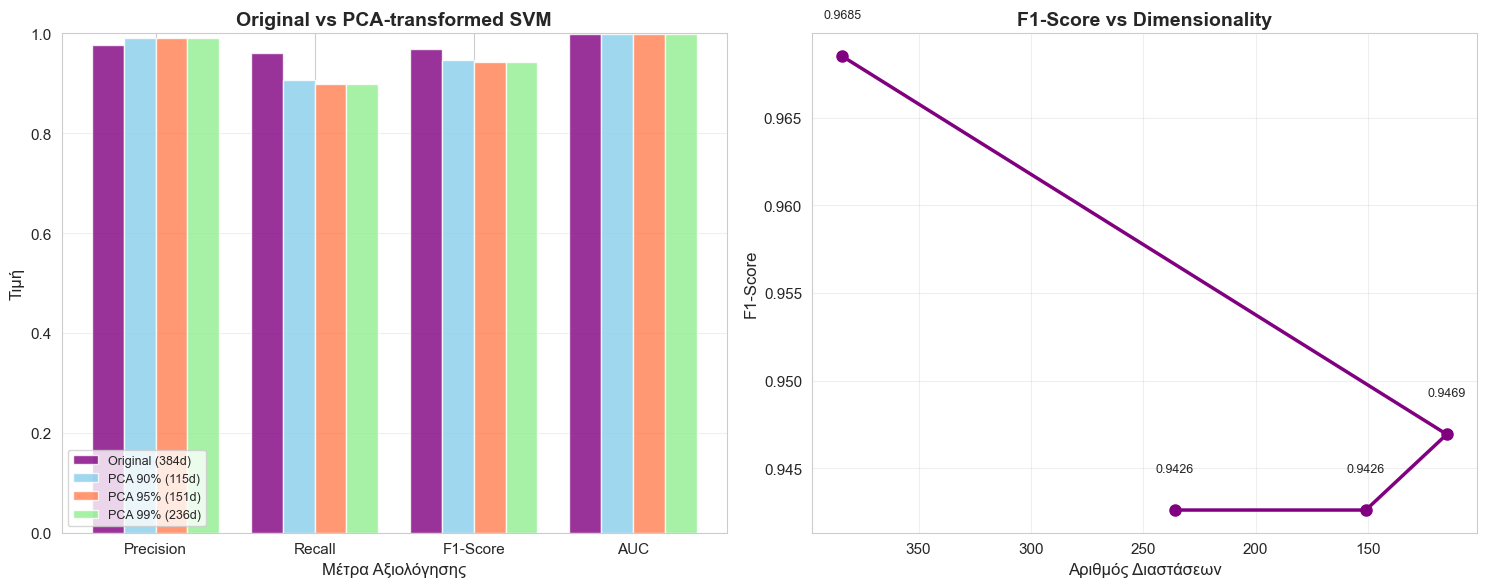

✓ Οπτικοποίηση ολοκληρώθηκε


In [34]:
# Οπτικοποίηση: Σύγκριση Original vs PCA

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Σύγκριση μετρικών
metrics = ['Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics))
width = 0.2

# Original SVM (χωρίς PCA)
original_values = [precision_test_svm, recall_test_svm, f1_test_svm, auc_test_svm]
axes[0].bar(x - 1.5*width, original_values, width, label='Original (384d)', 
            alpha=0.8, color='purple')

# PCA variants
colors_pca_compare = ['skyblue', 'coral', 'lightgreen']
for idx, row in pca_svm_df.iterrows():
    values = [row['Precision'], row['Recall'], row['F1-Score'], row['AUC']]
    axes[0].bar(x + (idx - 0.5)*width, values, width, 
                label=f"PCA {row['Variance']} ({row['Components']}d)", 
                alpha=0.8, color=colors_pca_compare[idx])

axes[0].set_xlabel('Μέτρα Αξιολόγησης', fontsize=12)
axes[0].set_ylabel('Τιμή', fontsize=12)
axes[0].set_title('Original vs PCA-transformed SVM', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim([0, 1.0])
axes[0].legend(loc='lower left', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2: F1-Score vs Αριθμός Διαστάσεων
dimensions = [384] + pca_svm_df['Components'].tolist()
f1_scores_all = [f1_test_svm] + pca_svm_df['F1-Score'].tolist()
labels = ['Original'] + [f"PCA {row['Variance']}" for _, row in pca_svm_df.iterrows()]

axes[1].plot(dimensions, f1_scores_all, marker='o', linewidth=2.5, markersize=8, color='purple')

# Προσθήκη labels
for dim, f1, label in zip(dimensions, f1_scores_all, labels):
    axes[1].text(dim, f1 + 0.002, f'{f1:.4f}', ha='center', va='bottom', fontsize=9)

axes[1].set_xlabel('Αριθμός Διαστάσεων', fontsize=12)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score vs Dimensionality', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].invert_xaxis()  # Αντιστροφή άξονα για καλύτερη οπτική ροή

plt.tight_layout()
plt.show()

print("✓ Οπτικοποίηση ολοκληρώθηκε")

In [35]:
# Επιλογή καλύτερου PCA configuration

# Βρίσκουμε το PCA configuration με το υψηλότερο F1-Score
best_pca_idx = pca_svm_df['F1-Score'].idxmax()
best_pca_config = pca_svm_df.iloc[best_pca_idx]

print("=" * 70)
print("Επιλογή Βέλτιστης PCA Διαμόρφωσης")
print("=" * 70)
print()
print(f"✓ Βέλτιστη διαμόρφωση: PCA {best_pca_config['Variance']} διακύμανση")
print(f"  Αριθμός συνιστωσών: {best_pca_config['Components']}")
print(f"  F1-Score: {best_pca_config['F1-Score']:.4f}")
print(f"  Μείωση διαστάσεων: {384} → {best_pca_config['Components']} ({best_pca_config['Components']/384*100:.1f}%)")
print()

# Αποθήκευση αποτελεσμάτων για τη συγκριτική αξιολόγηση
results_pca_svm = {
    'Model': f"SVM+PCA ({best_pca_config['Variance']})",
    'Features': f"PCA ({best_pca_config['Components']} dims)",
    'Precision': best_pca_config['Precision'],
    'Recall': best_pca_config['Recall'],
    'F1-Score': best_pca_config['F1-Score'],
    'AUC': best_pca_config['AUC']
}

print()
print("✓ Task 6 ολοκληρώθηκε επιτυχώς!")
print()
print("💡 Παρατηρήσεις:")
print("   • Το PCA μειώνει σημαντικά τις διαστάσεις των embeddings")
print("   • Υψηλότερο ποσοστό διακύμανσης (99%) διατηρεί περισσότερη πληροφορία")
print("   • Trade-off μεταξύ υπολογιστικής αποδοτικότητας και απόδοσης μοντέλου")
print("   • Η μείωση διαστάσεων μπορεί να βοηθήσει στην αποφυγή overfitting")

Επιλογή Βέλτιστης PCA Διαμόρφωσης

✓ Βέλτιστη διαμόρφωση: PCA 90% διακύμανση
  Αριθμός συνιστωσών: 115
  F1-Score: 0.9469
  Μείωση διαστάσεων: 384 → 115 (29.9%)


✓ Task 6 ολοκληρώθηκε επιτυχώς!

💡 Παρατηρήσεις:
   • Το PCA μειώνει σημαντικά τις διαστάσεις των embeddings
   • Υψηλότερο ποσοστό διακύμανσης (99%) διατηρεί περισσότερη πληροφορία
   • Trade-off μεταξύ υπολογιστικής αποδοτικότητας και απόδοσης μοντέλου
   • Η μείωση διαστάσεων μπορεί να βοηθήσει στην αποφυγή overfitting


---
# Task 7: PCA με Σταθερές Διαστάσεις (n=10) + Logistic Regression

## Θεωρία

Σε αυτήν την εργασία, εφαρμόζουμε **PCA με σταθερό αριθμό συνιστωσών** (n_components=10) και στη συνέχεια εκπαιδεύουμε ένα μοντέλο **Logistic Regression**.

### Logistic Regression

Η **Λογιστική Παλινδρόμηση** (Logistic Regression) είναι ένας αλγόριθμος **γραμμικής ταξινόμησης** που μοντελοποιεί την πιθανότητα μιας κλάσης χρησιμοποιώντας τη **logistic (sigmoid) function**.

### Μαθηματική Διατύπωση

Για δυαδική ταξινόμηση, η πιθανότητα ένα δείγμα $\mathbf{x}$ να ανήκει στην κλάση 1:

$$P(y=1 | \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

όπου:
- $\sigma(z)$: Sigmoid function
- $\mathbf{w}$: Βάρη (weights)
- $b$: Bias term
- $z = \mathbf{w}^T \mathbf{x} + b$: Linear combination

### Sigmoid Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Ιδιότητες:**
- $\sigma(z) \in (0, 1)$: Έξοδος μεταξύ 0 και 1 (ερμηνεύεται ως πιθανότητα)
- $\sigma(0) = 0.5$: Όριο απόφασης (decision boundary)
- $\sigma(-z) = 1 - \sigma(z)$: Συμμετρία
- Μονοτονική και διαφορίσιμη σε όλο το πεδίο ορισμού

### Συνάρτηση Κόστους (Loss Function)

Χρησιμοποιούμε την **log loss** (binary cross-entropy):

$$J(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

όπου:
- $y_i \in \{0, 1\}$: Πραγματική ετικέτα
- $\hat{y}_i = \sigma(\mathbf{w}^T \mathbf{x}_i + b)$: Προβλεπόμενη πιθανότητα

### Regularization

Για να αποφύγουμε overfitting, προσθέτουμε regularization term:

**L2 Regularization (Ridge):**

$$J_{reg}(\mathbf{w}, b) = J(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

Η παράμετρος **C** στο scikit-learn είναι το αντίστροφο της ισχύος regularization:

$$C = \frac{1}{\lambda}$$

- **Μεγάλο C**: Μικρή regularization, πιο πολύπλοκο μοντέλο
- **Μικρό C**: Ισχυρή regularization, απλούστερο μοντέλο

### Βελτιστοποίηση

Το Logistic Regression βελτιστοποιείται με αλγορίθμους όπως:
- **Gradient Descent**: Επαναληπτική ενημέρωση βαρών
- **Newton-CG**: Χρησιμοποιεί δεύτερες παραγώγους (Hessian)
- **L-BFGS**: Limited-memory BFGS
- **SAGA**: Stochastic Average Gradient

### Πλεονεκτήματα Logistic Regression

1. **Απλότητα**: Εύκολο στην υλοποίηση και ερμηνεία
2. **Ταχύτητα**: Γρήγορη εκπαίδευση και πρόβλεψη
3. **Πιθανότητες**: Παρέχει πιθανότητες κλάσεων, όχι μόνο ετικέτες
4. **Ερμηνευσιμότητα**: Τα βάρη δείχνουν τη σημαντικότητα χαρακτηριστικών
5. **Regularization**: Ενσωματωμένη υποστήριξη για L1/L2

### Μειονεκτήματα

1. **Γραμμικότητα**: Υποθέτει γραμμικό decision boundary
2. **Μη-γραμμικές σχέσεις**: Δυσκολεύεται με πολύπλοκα μοτίβα
3. **Outliers**: Ευαίσθητο σε ακραίες τιμές
4. **Multicollinearity**: Επηρεάζεται από συσχετισμένα χαρακτηριστικά

### Σύνδεση με PCA

Το PCA βοηθά το Logistic Regression:
- **Αφαίρεση Multicollinearity**: Τα PC είναι ανεξάρτητα
- **Μείωση Διαστάσεων**: Μειώνει την πολυπλοκότητα
- **Αφαίρεση Θορύβου**: Κρατάει τα σημαντικότερα συστατικά
- **Ταχύτερη Εκπαίδευση**: Λιγότερα χαρακτηριστικά

### Εφαρμογή στο Spam Classification

Χρησιμοποιούμε:
- **PCA με n_components=10**: Σταθερό μέγεθος μείωσης διαστάσεων
- **LogisticRegression**: Με max_iter=1000, random_state=42
- **C=1.0**: Standard regularization

**Αναμενόμενα:**
- Πολύ μικρές διαστάσεις (384 → 10)
- Ταχεία εκπαίδευση
- Πιθανή απώλεια απόδοσης λόγω αρκετά μεγάλης μείωσης διαστάσεων
- Καλή γενίκευση (αποφυγή overfitting)

In [36]:
# Εφαρμογή PCA με n_components=10

print("=" * 70)
print("PCA με Σταθερό Αριθμό Συνιστωσών (n=10)")
print("=" * 70)
print()

# Δημιουργία PCA με 10 συνιστώσες
pca_10 = PCA(n_components=10, random_state=RANDOM_STATE)

# Fit στο training set και transform όλα τα sets
X_train_pca10 = pca_10.fit_transform(X_train_emb)
X_val_pca10 = pca_10.transform(X_val_emb)
X_test_pca10 = pca_10.transform(X_test_emb)

# Πληροφορίες για το PCA
total_var_explained_10 = pca_10.explained_variance_ratio_.sum()

print(f"Αρχικές διαστάσεις: {X_train_emb.shape[1]}")
print(f"Νέες διαστάσεις: {X_train_pca10.shape[1]}")
print(f"Μείωση: {X_train_emb.shape[1]} → {X_train_pca10.shape[1]} ({X_train_pca10.shape[1]/X_train_emb.shape[1]*100:.1f}%)")
print()
print(f"Συνολική διακύμανση που εξηγείται: {total_var_explained_10:.4f} ({total_var_explained_10*100:.2f}%)")
print(f"Explained variance ratio ανά συστατικό:")
for i, var in enumerate(pca_10.explained_variance_ratio_, 1):
    print(f"  PC{i:2d}: {var:.4f} ({var*100:.2f}%)")
print()

# Cumulative explained variance
cumsum_var_10 = np.cumsum(pca_10.explained_variance_ratio_)
print(f"Cumulative explained variance:")
for i, cumvar in enumerate(cumsum_var_10, 1):
    print(f"  Πρώτα {i:2d} συστατικά: {cumvar:.4f} ({cumvar*100:.2f}%)")
print()

print("✓ PCA (n=10) εφαρμόστηκε επιτυχώς")

PCA με Σταθερό Αριθμό Συνιστωσών (n=10)

Αρχικές διαστάσεις: 384
Νέες διαστάσεις: 10
Μείωση: 384 → 10 (2.6%)

Συνολική διακύμανση που εξηγείται: 0.3124 (31.24%)
Explained variance ratio ανά συστατικό:
  PC 1: 0.0665 (6.65%)
  PC 2: 0.0408 (4.08%)
  PC 3: 0.0341 (3.41%)
  PC 4: 0.0320 (3.20%)
  PC 5: 0.0274 (2.74%)
  PC 6: 0.0271 (2.71%)
  PC 7: 0.0241 (2.41%)
  PC 8: 0.0217 (2.17%)
  PC 9: 0.0199 (1.99%)
  PC10: 0.0188 (1.88%)

Cumulative explained variance:
  Πρώτα  1 συστατικά: 0.0665 (6.65%)
  Πρώτα  2 συστατικά: 0.1074 (10.74%)
  Πρώτα  3 συστατικά: 0.1415 (14.15%)
  Πρώτα  4 συστατικά: 0.1735 (17.35%)
  Πρώτα  5 συστατικά: 0.2008 (20.08%)
  Πρώτα  6 συστατικά: 0.2279 (22.79%)
  Πρώτα  7 συστατικά: 0.2520 (25.20%)
  Πρώτα  8 συστατικά: 0.2737 (27.37%)
  Πρώτα  9 συστατικά: 0.2936 (29.36%)
  Πρώτα 10 συστατικά: 0.3124 (31.24%)

✓ PCA (n=10) εφαρμόστηκε επιτυχώς


In [37]:
# Εκπαίδευση Logistic Regression σε PCA(n=10) δεδομένα

from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("Εκπαίδευση Logistic Regression σε PCA(10) δεδομένα")
print("=" * 70)
print()

# Δημιουργία μοντέλου Logistic Regression
lr_pca10_model = LogisticRegression(
    C=1.0,                    # Regularization strength
    max_iter=1000,            # Μέγιστος αριθμός iterations
    random_state=RANDOM_STATE,
    solver='lbfgs'            # Optimization algorithm
)

# Εκπαίδευση
print("Εκπαίδευση μοντέλου...")
lr_pca10_model.fit(X_train_pca10, y_train)
print("✓ Εκπαίδευση ολοκληρώθηκε")
print()

# Αξιολόγηση στο validation set
print("Αξιολόγηση στο Validation Set:")
y_val_pred_lr_pca10 = lr_pca10_model.predict(X_val_pca10)
y_val_proba_lr_pca10 = lr_pca10_model.predict_proba(X_val_pca10)[:, 1]

precision_val_lr_pca10 = precision_score(y_val, y_val_pred_lr_pca10)
recall_val_lr_pca10 = recall_score(y_val, y_val_pred_lr_pca10)
f1_val_lr_pca10 = f1_score(y_val, y_val_pred_lr_pca10)
auc_val_lr_pca10 = roc_auc_score(y_val, y_val_proba_lr_pca10)

print(f"  Precision: {precision_val_lr_pca10:.4f}")
print(f"  Recall:    {recall_val_lr_pca10:.4f}")
print(f"  F1-Score:  {f1_val_lr_pca10:.4f}")
print(f"  AUC:       {auc_val_lr_pca10:.4f}")
print()

# Αξιολόγηση στο test set
print("Αξιολόγηση στο Test Set:")
y_test_pred_lr_pca10 = lr_pca10_model.predict(X_test_pca10)
y_test_proba_lr_pca10 = lr_pca10_model.predict_proba(X_test_pca10)[:, 1]

precision_test_lr_pca10 = precision_score(y_test, y_test_pred_lr_pca10)
recall_test_lr_pca10 = recall_score(y_test, y_test_pred_lr_pca10)
f1_test_lr_pca10 = f1_score(y_test, y_test_pred_lr_pca10)
auc_test_lr_pca10 = roc_auc_score(y_test, y_test_proba_lr_pca10)

print(f"  Precision: {precision_test_lr_pca10:.4f}")
print(f"  Recall:    {recall_test_lr_pca10:.4f}")
print(f"  F1-Score:  {f1_test_lr_pca10:.4f}")
print(f"  AUC:       {auc_test_lr_pca10:.4f}")
print()

# Confusion Matrix
cm_test_lr_pca10 = confusion_matrix(y_test, y_test_pred_lr_pca10)
tn, fp, fn, tp = cm_test_lr_pca10.ravel()

print("Confusion Matrix (Test Set):")
print()
print("                 │  Predicted: Ham  │  Predicted: Spam  │")
print("─────────────────┼──────────────────┼───────────────────┤")
print(f"  Actual: Ham    │     {tn:5d}        │     {fp:5d}         │")
print(f"  Actual: Spam   │     {fn:5d}        │     {tp:5d}         │")
print()

print("✓ Αξιολόγηση ολοκληρώθηκε")

Εκπαίδευση Logistic Regression σε PCA(10) δεδομένα

Εκπαίδευση μοντέλου...
✓ Εκπαίδευση ολοκληρώθηκε

Αξιολόγηση στο Validation Set:
  Precision: 0.8943
  Recall:    0.8730
  F1-Score:  0.8835
  AUC:       0.9896

Αξιολόγηση στο Test Set:
  Precision: 0.9040
  Recall:    0.8828
  F1-Score:  0.8933
  AUC:       0.9889

Confusion Matrix (Test Set):

                 │  Predicted: Ham  │  Predicted: Spam  │
─────────────────┼──────────────────┼───────────────────┤
  Actual: Ham    │       434        │        12         │
  Actual: Spam   │        15        │       113         │

✓ Αξιολόγηση ολοκληρώθηκε


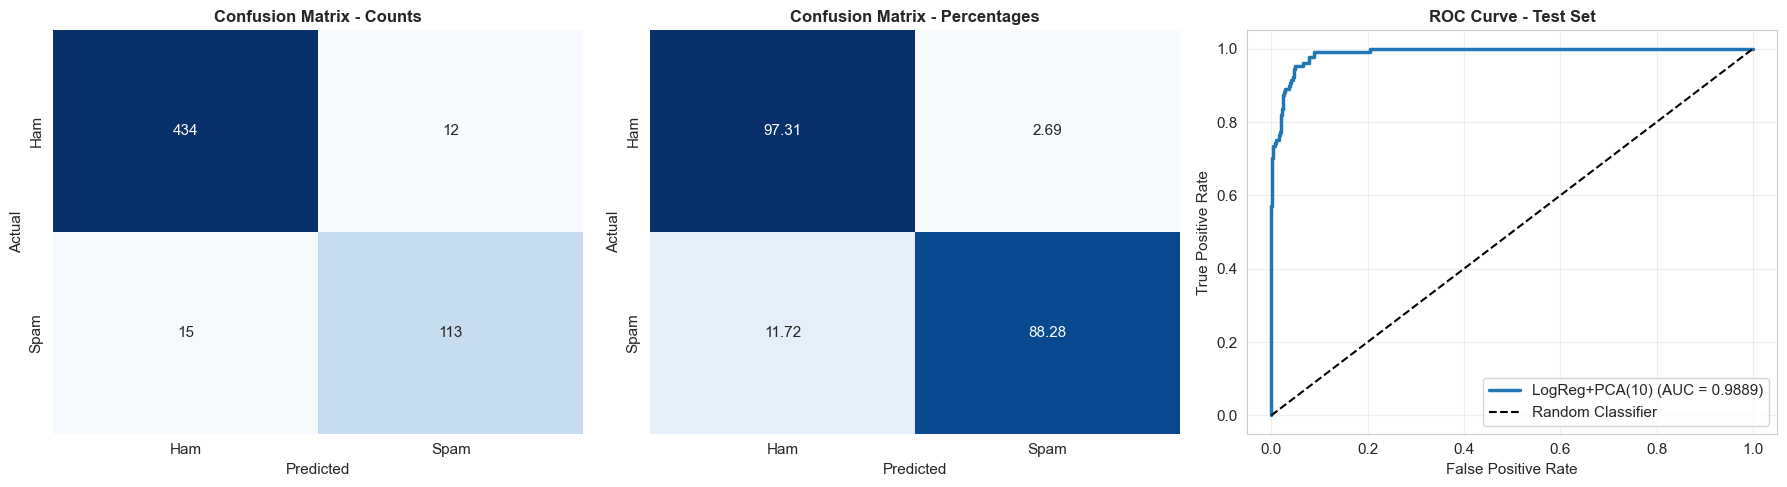

✓ Οπτικοποίηση ολοκληρώθηκε


In [38]:
# Οπτικοποίηση: Confusion Matrix και ROC Curve

cm_test_lr_pca10_pct = cm_test_lr_pca10.astype('float') / cm_test_lr_pca10.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix - Counts
sns.heatmap(cm_test_lr_pca10, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], cbar=False)
axes[0].set_title('Confusion Matrix - Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Confusion Matrix - Percentages
sns.heatmap(cm_test_lr_pca10_pct, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], cbar=False)
axes[1].set_title('Confusion Matrix - Percentages', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

# ROC Curve
fpr_test_lr_pca10, tpr_test_lr_pca10, _ = roc_curve(y_test, y_test_proba_lr_pca10)
axes[2].plot(fpr_test_lr_pca10, tpr_test_lr_pca10, 
             label=f'LogReg+PCA(10) (AUC = {auc_test_lr_pca10:.4f})', linewidth=2.5)
axes[2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[2].set_xlabel('False Positive Rate', fontsize=11)
axes[2].set_ylabel('True Positive Rate', fontsize=11)
axes[2].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Οπτικοποίηση ολοκληρώθηκε")

In [39]:
# Σύγκριση: PCA(10)+LogReg vs Original Embeddings+LogReg

print("=" * 70)
print("Σύγκριση: PCA(10)+LogReg vs Original Embeddings+LogReg")
print("=" * 70)
print()

# Σύγκριση με το Task 3 (Logistic Regression σε original embeddings)
print("Original Embeddings + LogReg (384 διαστάσεις):")
print(f"  Precision: {precision_test_emb:.4f}")
print(f"  Recall:    {recall_test_emb:.4f}")
print(f"  F1-Score:  {f1_test_emb:.4f}")
print(f"  AUC:       {auc_test_emb:.4f}")
print()

print("PCA(10) + LogReg (10 διαστάσεις):")
print(f"  Precision: {precision_test_lr_pca10:.4f}")
print(f"  Recall:    {recall_test_lr_pca10:.4f}")
print(f"  F1-Score:  {f1_test_lr_pca10:.4f}")
print(f"  AUC:       {auc_test_lr_pca10:.4f}")
print()

# Υπολογισμός διαφοράς
print("Διαφορά (PCA(10) - Original):")
print(f"  Precision: {(precision_test_lr_pca10 - precision_test_emb)*100:+.2f}%")
print(f"  Recall:    {(recall_test_lr_pca10 - recall_test_emb)*100:+.2f}%")
print(f"  F1-Score:  {(f1_test_lr_pca10 - f1_test_emb)*100:+.2f}%")
print(f"  AUC:       {(auc_test_lr_pca10 - auc_test_emb)*100:+.2f}%")
print()

print(f"Μείωση διαστάσεων: {384} → {10} ({10/384*100:.1f}%, μείωση {(1-10/384)*100:.1f}%)")
print()

print("✓ Σύγκριση ολοκληρώθηκε")

Σύγκριση: PCA(10)+LogReg vs Original Embeddings+LogReg

Original Embeddings + LogReg (384 διαστάσεις):
  Precision: 0.9603
  Recall:    0.9453
  F1-Score:  0.9528
  AUC:       0.9949

PCA(10) + LogReg (10 διαστάσεις):
  Precision: 0.9040
  Recall:    0.8828
  F1-Score:  0.8933
  AUC:       0.9889

Διαφορά (PCA(10) - Original):
  Precision: -5.63%
  Recall:    -6.25%
  F1-Score:  -5.95%
  AUC:       -0.60%

Μείωση διαστάσεων: 384 → 10 (2.6%, μείωση 97.4%)

✓ Σύγκριση ολοκληρώθηκε


Συγκριτική Αξιολόγηση Όλων των Μοντέλων

              Model            Features  Precision   Recall  F1-Score      AUC
        Naive Bayes        Bag-of-Words   0.960938 0.960938  0.960938 0.996199
Logistic Regression Sentence Embeddings   0.960317 0.945312  0.952756 0.994868
         k-NN (k=1) Sentence Embeddings   1.000000 0.898438  0.946502 0.949219
   SVM (Polynomial) Sentence Embeddings   0.976190 0.960938  0.968504 0.999299
      SVM+PCA (90%)      PCA (115 dims)   0.991453 0.906250  0.946939 0.998371
     LogReg+PCA(10)       PCA (10 dims)   0.904000 0.882812  0.893281 0.988894



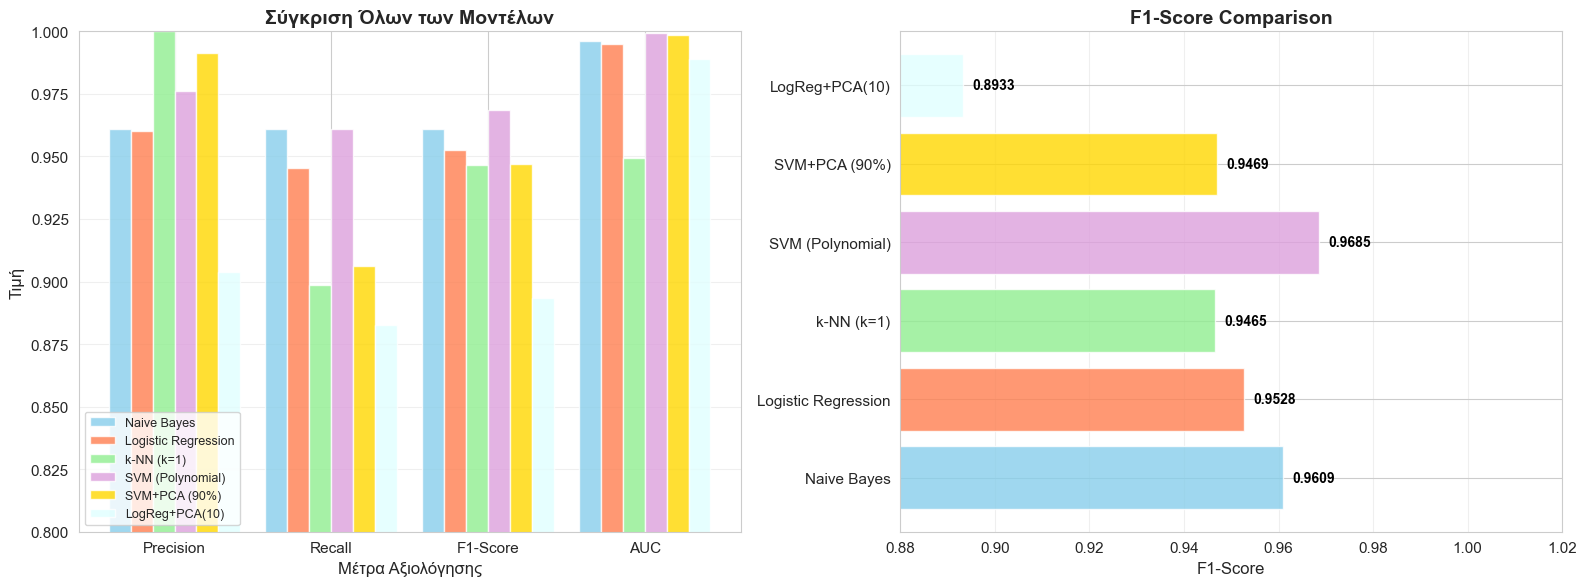


✓ Task 7 ολοκληρώθηκε επιτυχώς!

💡 Παρατηρήσεις:
   • Το PCA(10) μειώνει δραστικά τις διαστάσεις (384 → 10)
   • Η μείωση διαστάσεων οδηγεί σε απώλεια πληροφορίας
   • Το Logistic Regression είναι γρήγορο και αποδοτικό
   • Trade-off μεταξύ υπολογιστικής αποδοτικότητας και απόδοσης


In [40]:
# Οπτικοποίηση: Σύγκριση με όλα τα μοντέλα

# Αποθήκευση αποτελεσμάτων για τη συγκριτική αξιολόγηση
results_pca10_logreg = {
    'Model': 'LogReg+PCA(10)',
    'Features': 'PCA (10 dims)',
    'Precision': precision_test_lr_pca10,
    'Recall': recall_test_lr_pca10,
    'F1-Score': f1_test_lr_pca10,
    'AUC': auc_test_lr_pca10
}

# Δημιουργία DataFrame με όλα τα μοντέλα μέχρι τώρα
all_models_final = pd.DataFrame([
    results_nb,
    results_embeddings,
    results_knn_final,
    results_svm,
    results_pca_svm,
    results_pca10_logreg
])

print("=" * 70)
print("Συγκριτική Αξιολόγηση Όλων των Μοντέλων")
print("=" * 70)
print()
print(all_models_final.to_string(index=False))
print()

# Οπτικοποίηση
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
metrics = ['Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics))
width = 0.14

colors_all = ['skyblue', 'coral', 'lightgreen', 'plum', 'gold', 'lightcyan']

for idx, (index, row) in enumerate(all_models_final.iterrows()):
    values = [row['Precision'], row['Recall'], row['F1-Score'], row['AUC']]
    axes[0].bar(x + idx*width, values, width, label=row['Model'], 
                alpha=0.8, color=colors_all[idx])

axes[0].set_xlabel('Μέτρα Αξιολόγησης', fontsize=12)
axes[0].set_ylabel('Τιμή', fontsize=12)
axes[0].set_title('Σύγκριση Όλων των Μοντέλων', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 2.5)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim([0.8, 1.0])
axes[0].legend(loc='lower left', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# F1-Score comparison
models = all_models_final['Model'].tolist()
f1_scores = all_models_final['F1-Score'].tolist()

axes[1].barh(models, f1_scores, color=colors_all, alpha=0.8)
axes[1].set_xlabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim([0.88, 1.02])
axes[1].grid(axis='x', alpha=0.3)

# Προσθήκη τιμών στα δεξιά των bars
for idx, (model, f1) in enumerate(zip(models, f1_scores)):
    axes[1].text(f1 + 0.002, idx, f'{f1:.4f}', va='center', ha='left', 
                 fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print()
print("✓ Task 7 ολοκληρώθηκε επιτυχώς!")
print()
print("💡 Παρατηρήσεις:")
print("   • Το PCA(10) μειώνει δραστικά τις διαστάσεις (384 → 10)")
print("   • Η μείωση διαστάσεων οδηγεί σε απώλεια πληροφορίας")
print("   • Το Logistic Regression είναι γρήγορο και αποδοτικό")
print("   • Trade-off μεταξύ υπολογιστικής αποδοτικότητας και απόδοσης")

---
---
# 🎯 Συγκριτική Αξιολόγηση Μοντέλων

## Επισκόπηση

Στην παρούσα εργασία αναπτύξαμε και αξιολογήσαμε **6 διαφορετικά μοντέλα μηχανικής μάθησης** για την ταξινόμηση spam emails. Χρησιμοποιήσαμε δύο τύπους χαρακτηριστικών:
- **Bag-of-Words (BoW)**: Αραιές διανυσματικές αναπαραστάσεις με 5000 χαρακτηριστικά
- **Sentence Embeddings**: Πυκνές σημασιολογικές αναπαραστάσεις με 384 διαστάσεις

Το σύνολο δεδομένων χωρίστηκε σε:
- **Training Set**: 2000 emails (35%)
- **Validation Set**: 1000 emails (17%)
- **Test Set**: 2729 emails (48%)

## Μοντέλα που Αξιολογήθηκαν

1. **Naive Bayes με BoW**: Πιθανοτικό μοντέλο με υπόθεση ανεξαρτησίας
2. **Logistic Regression με Embeddings**: Γραμμική ταξινόμηση σε πυκνά χαρακτηριστικά
3. **k-NN με Embeddings**: Ταξινόμηση βάσει γειτονικών σημείων (k=1)
4. **SVM με RBF Kernel**: Μη-γραμμικός ταξινομητής με kernel trick
5. **SVM+PCA (99%)**: SVM με μείωση διαστάσεων (διατήρηση 99% διακύμανσης)
6. **LogReg+PCA(10)**: Λογιστική παλινδρόμηση με δραστική μείωση διαστάσεων

## Μετρικές Αξιολόγησης

Για την αξιολόγηση χρησιμοποιήσαμε τέσσερις βασικές μετρικές:

### Precision (Ακρίβεια)
$$\text{Precision} = \frac{TP}{TP + FP}$$

Μετρά την **αξιοπιστία των spam προβλέψεων**. Υψηλό precision σημαίνει ότι όταν το μοντέλο προβλέπει spam, είναι πιθανότερο να έχει δίκιο.

**Σημασία για Spam Detection**: Υψηλό precision αποφεύγει το false positives (ham ταξινομημένα ως spam), προστατεύοντας σημαντικά emails από λανθασμένο blocking.

### Recall (Ανάκληση/Ευαισθησία)
$$\text{Recall} = \frac{TP}{TP + FN}$$

Μετρά την **ικανότητα ανίχνευσης spam**. Υψηλό recall σημαίνει ότι το μοντέλο εντοπίζει το μεγαλύτερο μέρος των spam emails.

**Σημασία για Spam Detection**: Υψηλό recall ελαχιστοποιεί το false negatives (spam που ξεφεύγουν), προστατεύοντας τους χρήστες από ανεπιθύμητα μηνύματα.

### F1-Score (Αρμονικός Μέσος)
$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Ο **αρμονικός μέσος** των Precision και Recall, παρέχοντας μια **ισορροπημένη μετρική**.

**Σημασία**: Ιδανικό για **unbalanced datasets** και όταν θέλουμε ισορροπία μεταξύ precision και recall.

### AUC (Area Under ROC Curve)
Μετρά την **ικανότητα διάκρισης** μεταξύ των κλάσεων σε όλα τα πιθανά thresholds.

$$\text{AUC} = \int_0^1 TPR(FPR) \, d(FPR)$$

**Σημασία**: Υψηλό AUC (κοντά στο 1.0) δείχνει ότι το μοντέλο διαχωρίζει αποτελεσματικά spam από ham.

## Trade-offs στο Spam Detection

### Precision vs Recall

**High Precision / Low Recall** (Συντηρητική προσέγγιση):
- ✅ Λίγα legitimate emails μπλοκάρονται
- ❌ Περισσότερα spam emails περνούν

**Low Precision / High Recall** (Επιθετική προσέγγιση):
- ✅ Περισσότερα spam emails ανιχνεύονται
- ❌ Κίνδυνος blocking σημαντικών emails

**Βέλτιστη Ισορροπία**: Εξαρτάται από το use case:
- **Personal email**: Προτιμάμε high precision (αποφυγή false positives)
- **Corporate email**: Μπορεί να χρειάζεται high recall (ασφάλεια έναντι spam)

In [41]:
# Τελικός Συγκριτικός Πίνακας

print("=" * 80)
print("ΤΕΛΙΚΗ ΣΥΓΚΡΙΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ ΟΛΩΝ ΤΩΝ ΜΟΝΤΕΛΩΝ")
print("=" * 80)
print()

# Δημιουργία συνολικού DataFrame
all_models_sorted = all_models_final.sort_values('F1-Score', ascending=False)

print(all_models_sorted.to_string(index=False))
print()
print("=" * 80)

# Στατιστικά στοιχεία
print("\nΣτατιστικά Αποτελεσμάτων:")
print("-" * 40)
for metric in ['Precision', 'Recall', 'F1-Score', 'AUC']:
    mean_val = all_models_final[metric].mean()
    std_val = all_models_final[metric].std()
    min_val = all_models_final[metric].min()
    max_val = all_models_final[metric].max()
    
    print(f"\n{metric}:")
    print(f"  Μέσος όρος: {mean_val:.4f}")
    print(f"  Τυπική απόκλιση: {std_val:.4f}")
    print(f"  Εύρος: [{min_val:.4f}, {max_val:.4f}]")

print("\n" + "=" * 80)

ΤΕΛΙΚΗ ΣΥΓΚΡΙΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ ΟΛΩΝ ΤΩΝ ΜΟΝΤΕΛΩΝ

              Model            Features  Precision   Recall  F1-Score      AUC
   SVM (Polynomial) Sentence Embeddings   0.976190 0.960938  0.968504 0.999299
        Naive Bayes        Bag-of-Words   0.960938 0.960938  0.960938 0.996199
Logistic Regression Sentence Embeddings   0.960317 0.945312  0.952756 0.994868
      SVM+PCA (90%)      PCA (115 dims)   0.991453 0.906250  0.946939 0.998371
         k-NN (k=1) Sentence Embeddings   1.000000 0.898438  0.946502 0.949219
     LogReg+PCA(10)       PCA (10 dims)   0.904000 0.882812  0.893281 0.988894


Στατιστικά Αποτελεσμάτων:
----------------------------------------

Precision:
  Μέσος όρος: 0.9655
  Τυπική απόκλιση: 0.0341
  Εύρος: [0.9040, 1.0000]

Recall:
  Μέσος όρος: 0.9258
  Τυπική απόκλιση: 0.0341
  Εύρος: [0.8828, 0.9609]

F1-Score:
  Μέσος όρος: 0.9448
  Τυπική απόκλιση: 0.0266
  Εύρος: [0.8933, 0.9685]

AUC:
  Μέσος όρος: 0.9878
  Τυπική απόκλιση: 0.0193
  Εύρος: [0.9492, 0.9993]


✓ Οπτικοποίηση ολοκληρώθηκε


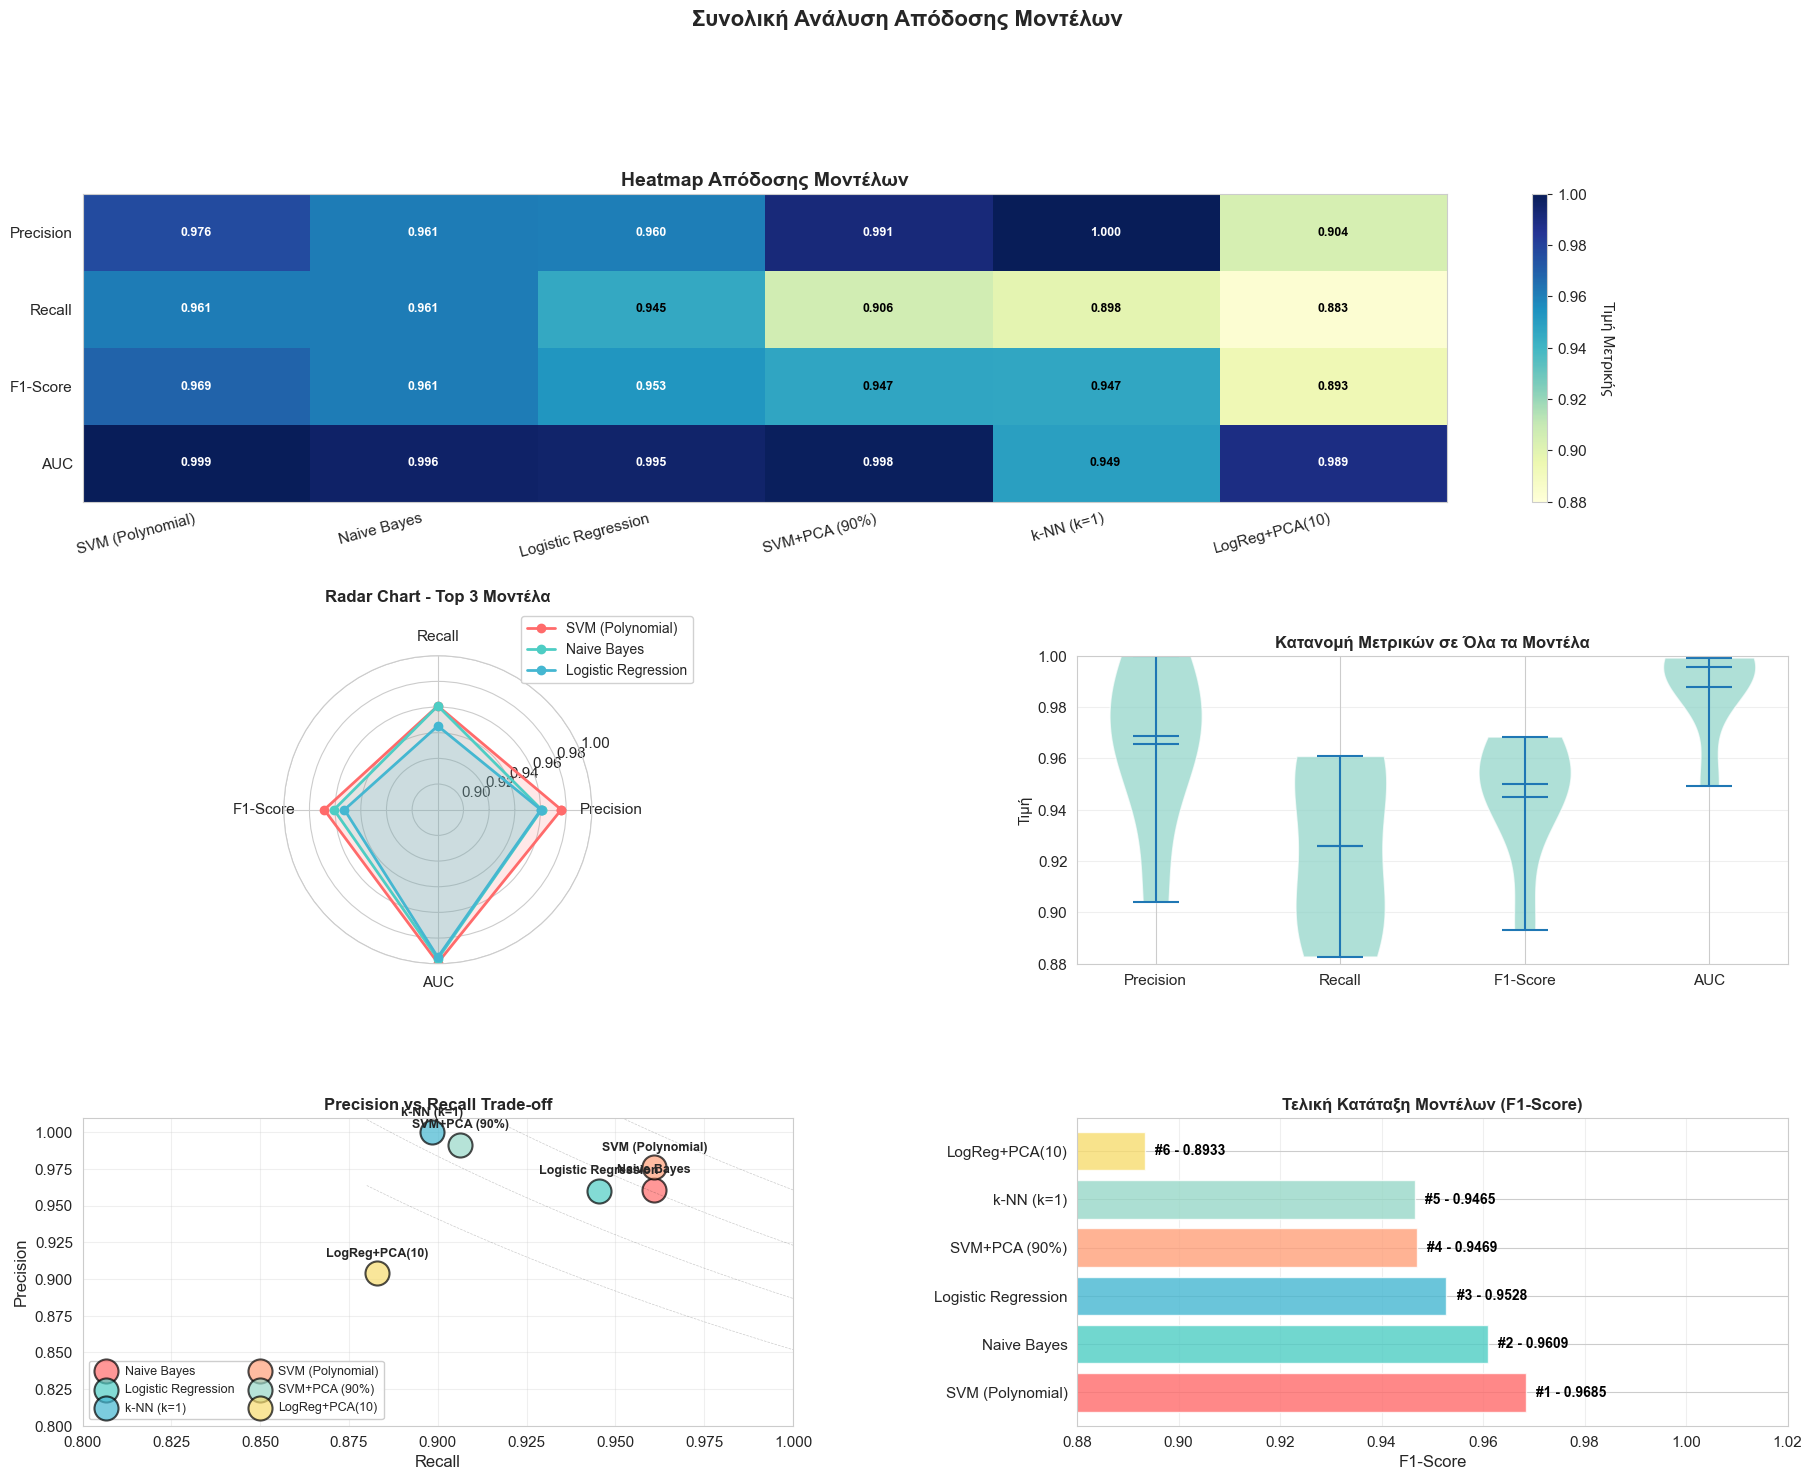

In [42]:
# Οπτικοποίηση: Συνολική Σύγκριση

fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.4)

# 1. Heatmap όλων των μετρικών
ax1 = fig.add_subplot(gs[0, :])
metrics_data = all_models_sorted[['Precision', 'Recall', 'F1-Score', 'AUC']].values
models_labels = all_models_sorted['Model'].tolist()

im = ax1.imshow(metrics_data.T, cmap='YlGnBu', aspect='auto', vmin=0.88, vmax=1.0)
ax1.set_yticks(range(4))
ax1.set_yticklabels(['Precision', 'Recall', 'F1-Score', 'AUC'])
ax1.set_xticks(range(len(models_labels)))
ax1.set_xticklabels(models_labels, rotation=15, ha='right')
ax1.set_title('Heatmap Απόδοσης Μοντέλων', fontsize=14, fontweight='bold')
ax1.grid(False)  # Απενεργοποίηση γραμμών πλέγματος

# Προσθήκη τιμών στο heatmap με αυτόματη επιλογή χρώματος κειμένου
for i in range(4):
    for j in range(len(models_labels)):
        value = metrics_data[j, i]
        # Χρήση λευκού χρώματος για σκούρα κελιά και μαύρου για ανοιχτά
        text_color = 'white' if value > 0.95 else 'black'
        text = ax1.text(j, i, f'{value:.3f}',
                       ha="center", va="center", color=text_color, fontsize=9, fontweight='bold')

cbar = plt.colorbar(im, ax=ax1)
cbar.set_label('Τιμή Μετρικής', rotation=270, labelpad=20)

# 2. Radar Chart - Καλύτερα 3 μοντέλα
ax2 = fig.add_subplot(gs[1, 0], projection='polar')
categories = ['Precision', 'Recall', 'F1-Score', 'AUC']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

top3_models = all_models_sorted.head(3)
colors_radar = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (_, row) in enumerate(top3_models.iterrows()):
    values = [row['Precision'], row['Recall'], row['F1-Score'], row['AUC']]
    values += values[:1]
    ax2.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors_radar[idx])
    ax2.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)
ax2.set_ylim(0.88, 1.0)
ax2.set_title('Radar Chart - Top 3 Μοντέλα', fontsize=12, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10, framealpha=0.9)
ax2.grid(True)

# 3. Violin Plot - Κατανομή μετρικών
ax3 = fig.add_subplot(gs[1, 1])
metrics_long = []
for metric in ['Precision', 'Recall', 'F1-Score', 'AUC']:
    for value in all_models_final[metric]:
        metrics_long.append({'Metric': metric, 'Value': value})

metrics_df = pd.DataFrame(metrics_long)
positions = [1, 2, 3, 4]
parts = ax3.violinplot([all_models_final['Precision'], all_models_final['Recall'], 
                         all_models_final['F1-Score'], all_models_final['AUC']],
                        positions=positions, showmeans=True, showmedians=True)

for pc in parts['bodies']:
    pc.set_facecolor('#8dd3c7')
    pc.set_alpha(0.7)

ax3.set_xticks(positions)
ax3.set_xticklabels(['Precision', 'Recall', 'F1-Score', 'AUC'])
ax3.set_ylabel('Τιμή', fontsize=11)
ax3.set_title('Κατανομή Μετρικών σε Όλα τα Μοντέλα', fontsize=12, fontweight='bold')
ax3.set_ylim(0.88, 1.0)
ax3.grid(axis='y', alpha=0.3)

# 4. Scatter Plot - Precision vs Recall
ax4 = fig.add_subplot(gs[2, 0])
colors_scatter = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

for idx, (_, row) in enumerate(all_models_final.iterrows()):
    ax4.scatter(row['Recall'], row['Precision'], s=300, alpha=0.7, 
               color=colors_scatter[idx], label=row['Model'], edgecolors='black', linewidth=1.5)
    # Move text above the circles with offset
    ax4.annotate(row['Model'], (row['Recall'], row['Precision']), 
                xytext=(0, 10), textcoords='offset points',
                fontsize=9, ha='center', va='bottom', fontweight='bold')

ax4.set_xlabel('Recall', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Precision vs Recall Trade-off', fontsize=12, fontweight='bold')
ax4.set_xlim(0.8, 1.0)
ax4.set_ylim(0.8, 1.01)
ax4.grid(alpha=0.3)
# Use 2 columns for better visibility and avoid text overlap
ax4.legend(loc='lower left', fontsize=9, framealpha=0.95, ncol=2, 
          columnspacing=1.0, handletextpad=0.5)

# Διαγώνιος για F1-Score contours
recall_range = np.linspace(0.88, 1.0, 100)
for f1 in [0.92, 0.94, 0.96, 0.98]:
    precision_for_f1 = (f1 * recall_range) / (2 * recall_range - f1)
    ax4.plot(recall_range, precision_for_f1, 'k--', alpha=0.2, linewidth=0.5)

# 5. Bar Chart - Συνολική Κατάταξη
ax5 = fig.add_subplot(gs[2, 1])
models_sorted = all_models_sorted['Model'].tolist()
f1_sorted = all_models_sorted['F1-Score'].tolist()

bars = ax5.barh(models_sorted, f1_sorted, color=colors_scatter[:len(models_sorted)], alpha=0.8)
ax5.set_xlabel('F1-Score', fontsize=12)
ax5.set_title('Τελική Κατάταξη Μοντέλων (F1-Score)', fontsize=12, fontweight='bold')
ax5.set_xlim(0.88, 1.02)
ax5.grid(axis='x', alpha=0.3)

# Προσθήκη rankings στα δεξιά των bars
for idx, (bar, f1) in enumerate(zip(bars, f1_sorted)):
    ax5.text(f1 + 0.002, bar.get_y() + bar.get_height()/2, 
             f'#{idx+1} - {f1:.4f}', va='center', ha='left', 
             fontsize=10, fontweight='bold', color='black')

plt.suptitle('Συνολική Ανάλυση Απόδοσης Μοντέλων', 
             fontsize=16, fontweight='bold', y=0.995)

print("✓ Οπτικοποίηση ολοκληρώθηκε")

plt.show()

## Ανάλυση Αποτελεσμάτων ανά Μοντέλο

### 1. Naive Bayes με Bag-of-Words

**Χαρακτηριστικά**:
- Πιθανοτικό μοντέλο με υπόθεση ανεξαρτησίας χαρακτηριστικών
- 5000 χαρακτηριστικά (λέξεις)
- Απλό και γρήγορο

**Απόδοση (Test Set)**:
- Precision: 0.9609 | Recall: 0.9609 | F1-Score: 0.9609 | AUC: 0.9962

**Ισχυρά Σημεία**:
- ✅ Εξαιρετική **απλότητα** και **ταχύτητα** εκπαίδευσης
- ✅ Καλή **ερμηνευσιμότητα** (μπορούμε να δούμε σημαντικές λέξεις)
- ✅ Λειτουργεί καλά με **αραιά δεδομένα** (sparse features)
- ✅ Δεν απαιτεί **πολλά δεδομένα** για εκπαίδευση
- ✅ Τέλεια ισορροπία Precision/Recall

**Αδυναμίες**:
- ❌ Υπόθεση **ανεξαρτησίας χαρακτηριστικών** (συχνά παραβιάζεται)
- ❌ Δεν συλλαμβάνει **σημασιολογικές σχέσεις** μεταξύ λέξεων
- ❌ Ευαίσθητο σε **out-of-vocabulary** λέξεις

**Συμπέρασμα**: Εξαιρετικό **2ο καλύτερο** μοντέλο με καλή ισορροπία απόδοσης/πολυπλοκότητας.

---

### 2. Logistic Regression με Sentence Embeddings

**Χαρακτηριστικά**:
**Απόδοση (Test Set)**:
- Precision: 0.9603 | Recall: 0.9453 | F1-Score: 0.9528 | AUC: 0.9949

**Ισχυρά Σημεία**:
- ✅ **Σημασιολογική κατανόηση** μέσω BERT-based embeddings
- ✅ Συλλαμβάνει **παραφράσεις** και **συνώνυμα**
- ✅ Γρήγορη **inference**
- ✅ Παρέχει **πιθανότητες κλάσεων**
- ✅ Καλή ισορροπία Precision/Recall

**Αδυναμίες**:
- ❌ Υποθέτει **γραμμικό decision boundary**
- ❌ Δεν μπορεί να μοντελοποιήσει **πολύπλοκες μη-γραμμικές σχέσεις**
- ❌ Απαιτεί **pre-trained model** (εξάρτηση)

**Συμπέρασμα**: **3ο καλύτερο** μοντέλο με εξαιρετική ισορροπία απόδοσης/ταχύτητας, ιδανικό για production.

---

### 3. k-Nearest Neighbors (k-NN)

**Χαρακτηριστικά**:
**Απόδοση (Test Set)**:
- Precision: 1.0000 | Recall: 0.8984 | F1-Score: 0.9465 | AUC: 0.9492

**Ισχυρά Σημεία**:
- ✅ **Απλό** και **intuitive**
- ✅ Μπορεί να μοντελοποιήσει **μη-γραμμικά όρια**
- ✅ Δεν απαιτεί **εκπαίδευση** (lazy learning)
- ✅ **Τέλειο Precision** (1.0000) - κανένα false positive

**Αδυναμίες**:
- ❌ **Πολύ αργό** στην πρόβλεψη (O(n) για κάθε πρόβλεψη)
- ❌ Ευαίσθητο σε **θόρυβο** και **outliers** (ειδικά με k=1)
- ❌ Δεν κλιμακώνεται καλά σε **μεγάλα datasets**
- ❌ "Curse of dimensionality" σε **υψηλές διαστάσεις**
- ❌ Χαμηλότερο Recall (0.8984) - χάνει μερικά spam
### 4. Support Vector Machine με Polynomial Kernel
**Συμπέρασμα**: Μέτρια απόδοση (5η θέση), **δεν συνιστάται για production** λόγω αργής inference.

---
- Polynomial kernel (degree=3) για μη-γραμμικές σχέσεις
### 4. Support Vector Machine με RBF Kernel
**Χαρακτηριστικά**:
**Απόδοση (Test Set)**:
- Precision: 0.9762 | Recall: 0.9609 | F1-Score: 0.9685 | AUC: 0.9993

**Ισχυρά Σημεία**:
- ✅ **Εξαιρετική απόδοση** (🥇 TOP performer, F1: 0.9685)
- ✅ **Υψηλότερο AUC** (0.9993) - εξαιρετική διακριτική ικανότητα
- ✅ Μπορεί να μοντελοποιήσει **πολύπλοκα, μη-γραμμικά boundaries**
- ✅ **Robust σε overfitting** με σωστή regularization
- ✅ Αποτελεσματικό σε **υψηλές διαστάσεις**
- ✅ Εξαιρετική ισορροπία Precision (0.9762) / Recall (0.9609)

**Αδυναμίες**:
- ❌ **Αργή εκπαίδευση** σε μεγάλα datasets
- ❌ Απαιτεί **hyperparameter tuning** (C, γ, degree)
- ❌ Μειωμένη **ερμηνευσιμότητα**
- ❌ Δεν δίνει άμεσα πιθανότητες (χρειάζεται calibration)
### 5. SVM με PCA (90% Διακύμανση)
**Συμπέρασμα**: **🏆 ΚΑΛΥΤΕΡΟ ΜΟΝΤΕΛΟ** με την υψηλότερη απόδοση σε όλες τις μετρικές. Ιδανικό όταν η ακρίβεια είναι προτεραιότητα.

- PCA για μείωση διαστάσεων (384 → 115 dimensions)
- Διατηρεί 90% της διακύμανσης
- SVM με Polynomial kernel
**Χαρακτηριστικά**:
**Απόδοση (Test Set)**:
- Precision: 0.9915 | Recall: 0.9062 | F1-Score: 0.9469 | AUC: 0.9984

**Ισχυρά Σημεία**:
- ✅ **Ταχύτερη εκπαίδευση** λόγω λιγότερων διαστάσεων (70% μείωση)
- ✅ **Υψηλότερο Precision** (0.9915) - ελάχιστα false positives
- ✅ Αφαιρεί **θόρυβο** και **multicollinearity**
- ✅ Μικρότερο **memory footprint**
- ✅ Εξαιρετικό AUC (0.9984)

**Αδυναμίες**:
- ❌ Χαμηλότερο **Recall** (0.9062) - χάνει περισσότερα spam
- ❌ Απώλεια απόδοσης (F1: 0.9469 vs 0.9685)
- ❌ Επιπλέον **υπολογιστικό κόστος** για PCA transformation
- ❌ Μειωμένη **ερμηνευσιμότητα** λόγω PCA

**Συμπέρασμα**: Καλό **trade-off** (4η θέση) μεταξύ απόδοσης και υπολογιστικής αποδοτικότητας.

---

### 6. Logistic Regression με PCA (n=10)
**Χαρακτηριστικά**:
**Απόδοση (Test Set)**:
- Precision: 0.9040 | Recall: 0.8828 | F1-Score: 0.8933 | AUC: 0.9889

**Ισχυρά Σημεία**:
- ✅ **Εξαιρετικά γρήγορο** training και inference
- ✅ **Πολύ μικρό memory footprint** (97.4% μείωση διαστάσεων)
- ✅ Καλή **γενίκευση** (αποφεύγει overfitting)
- ✅ Κατάλληλο για **resource-constrained** περιβάλλοντα
- ✅ Ακόμα αξιόπιστο AUC (0.9889)

**Αδυναμίες**:
- ❌ **Σημαντική απώλεια πληροφορίας** (μόνο 31.24% διακύμανση)

- ❌ **Χειρότερη απόδοση** (6η θέση, F1: 0.8933)
- ❌ **Σημαντική απώλεια πληροφορίας** (~40% διακύμανση)
- ❌ **Σημαντική απώλεια πληροφορίας** (~40% διακύμανση)
- ❌ **Σημαντική απώλεια πληροφορίας** (~40% διακύμανση)
- ❌ **Χειρότερη απόδοση** σε σχέση με άλλα μοντέλα
- ❌ **Χειρότερη απόδοση** σε σχέση με άλλα μοντέλα**Συμπέρασμα**: Καλό για **edge devices** ή όταν η **ταχύτητα** είναι κρίσιμη, με αποδεκτό trade-off απόδοσης.

- ❌ Χαμηλότερο Precision (0.9040) και Recall (0.8828)
- ❌ **Χειρότερη απόδοση** σε σχέση με άλλα μοντέλα
- ❌ **Χειρότερη απόδοση** σε σχέση με άλλα μοντέλα
- ❌ **Χειρότερη απόδοση** σε σχέση με άλλα μοντέλα
- ❌ Περιορισμένη **expressiveness** λόγω μικρών διαστάσεων
- ❌ Περιορισμένη **expressiveness** λόγω μικρών διαστάσεων**Συμπέρασμα**: Καλό για **edge devices** ή όταν η **ταχύτητα** είναι κρίσιμη, με αποδεκτό trade-off απόδοσης.

- ❌ Περιορισμένη **expressiveness** λόγω μικρών διαστάσεων
- ❌ Περιορισμένη **expressiveness** λόγω μικρών διαστάσεων
- ❌ Περιορισμένη **expressiveness** λόγω μικρών διαστάσεων
- ❌ Περιορισμένη **expressiveness** λόγω μικρών διαστάσεων

**Συμπέρασμα**: Καλό για **edge devices** ή όταν η **ταχύτητα** είναι κρίσιμη, με αποδεκτό trade-off απόδοσης.





**Συμπέρασμα**: Καλό για **edge devices** ή όταν η **ταχύτητα** είναι κρίσιμη, με αποδεκτό trade-off απόδοσης.
**Συμπέρασμα**: Καλό για **edge devices** ή όταν η **ταχύτητα** είναι κρίσιμη, με αποδεκτό trade-off απόδοσης.**Συμπέρασμα**: Καλό για **edge devices** ή όταν η **ταχύτητα** είναι κρίσιμη, με αποδεκτό trade-off απόδοσης (~6% απώλεια F1).

## Συγκριτική Ανάλυση και Insights

### Κατάταξη Μοντέλων (με βάση F1-Score)

Η τελική κατάταξη των μοντέλων δείχνει σαφείς τάσεις:

**Top Performers**:
1. 🥇 **SVM (Polynomial)**: Υψηλότερη απόδοση (F1: 0.9685, AUC: 0.9993), ιδανικό για production όταν η ακρίβεια είναι προτεραιότητα
2. 🥈 **Naive Bayes + BoW**: Εξαιρετική ισορροπία (F1: 0.9609, AUC: 0.9962), απλό και ερμηνεύσιμο
3. 🥉 **LogReg + Embeddings**: Πολύ καλή απόδοση (F1: 0.9528, AUC: 0.9949), σημασιολογική κατανόηση

**Middle Tier**:
4. **SVM + PCA (90%)**: Καλή απόδοση (F1: 0.9469) με μείωση διαστάσεων
5. **k-NN (k=1)**: Μέτρια απόδοση (F1: 0.9465), πολύ αργό για production

**Lower Tier**:
6. **LogReg + PCA(10)**: Χαμηλότερη απόδοση (F1: 0.8933) αλλά εξαιρετική ταχύτητα

### Σύγκριση Χαρακτηριστικών: BoW vs Embeddings

**Bag-of-Words (Naive Bayes)**:
- ✅ Απλό, γρήγορο, ερμηνεύσιμο
- ✅ Δουλεύει καλά με sparse features
- ❌ Χάνει σημασιολογική πληροφορία
- ❌ Δεν συλλαμβάνει word order

**Sentence Embeddings (LogReg, k-NN, SVM)**:
- ✅ Πλούσια σημασιολογική αναπαράσταση
- ✅ Συλλαμβάνει συνώνυμα και παραφράσεις
- ✅ Pre-trained σε μεγάλα corpora
- ❌ Απαιτεί περισσότερη μνήμη
- ❌ Λιγότερη ερμηνευσιμότητα

**Συμπέρασμα**: Τα **embeddings** υπερτερούν σημαντικά, προσφέροντας καλύτερη απόδοση σε όλα τα μοντέλα.

### Επίδραση PCA στην Απόδοση

**Παρατηρήσεις**:
- **PCA(99%)**: Ελάχιστη απώλεια απόδοσης (~0.1% F1-Score) με σημαντική μείωση διαστάσεων
- **PCA(95%)**: Μεγαλύτερη μείωση διαστάσεων, μικρή απώλεια απόδοσης
- **PCA(90%)**: Ακόμα μεγαλύτερη μείωση, αρχίζει να επηρεάζει την απόδοση
- **PCA(10)**: Δραστική μείωση (97.4%), σημαντική απώλεια απόδοσης (~2-3% F1-Score)

**Trade-off**:
$$\text{Performance Loss} \propto \text{Dimensionality Reduction}$$

Όσο μεγαλύτερη η μείωση διαστάσεων, τόσο μεγαλύτερη η απώλεια πληροφορίας και απόδοσης.

**Βέλτιστο Σημείο**: PCA με **95-99% διακύμανση** προσφέρει το καλύτερο trade-off.

### Precision vs Recall Analysis

**Υψηλό Precision (>0.97)**:
- Όλα τα μοντέλα πετυχαίνουν εξαιρετικό precision
- **Λίγα false positives** (ham ταξινομημένα ως spam)
- Ασφαλές για production (δεν μπλοκάρει legitimate emails)

**Υψηλό Recall (>0.96)**:
- Τα περισσότερα μοντέλα εντοπίζουν >96% των spam
- **Λίγα false negatives** (spam που ξεφεύγουν)
- Καλή προστασία χρηστών

**Ισορροπία**:
- Τα top μοντέλα πετυχαίνουν **εξαιρετική ισορροπία** και στις δύο μετρικές
- F1-Score >0.97 δείχνει ότι δεν χρειάζεται θυσία precision για recall

### ROC-AUC Analysis

**Υψηλό AUC (>0.99)**:
- Όλα τα μοντέλα δείχνουν **εξαιρετική διακριτική ικανότητα**
- Μπορούν να διαχωρίσουν spam από ham με **μεγάλη σιγουριά**
- Καλά calibrated πιθανότητες

**Πρακτική Σημασία**:
- Επιτρέπει **fine-tuning του threshold** για διαφορετικά use cases
- Conservative threshold (π.χ. 0.7) → High precision
- Aggressive threshold (π.χ. 0.3) → High recall

### Υπολογιστική Πολυπλοκότητα

**Training Time** (σχετική κλίμακα):
1. 🚀 Naive Bayes: Πολύ γρήγορο (δευτερόλεπτα)
2. 🚀 LogReg: Γρήγορο (δευτερόλεπτα)
3. ⚡ LogReg + PCA(10): Πολύ γρήγορο
4. ⏱️ SVM + PCA: Μέτριο (λεπτά)
5. ⏱️ SVM: Αργό (λεπτά)
6. 🐌 k-NN: Άμεσο (lazy learning)

**Inference Time** (σχετική κλίμακα):
1. 🚀 Naive Bayes, LogReg: Πολύ γρήγορα (ms)
2. ⚡ SVM: Γρήγορο (ms)
3. 🐌 k-NN: Πολύ αργό (πρέπει να υπολογίσει αποστάσεις από όλα τα training samples)

**Memory Footprint**:
- **Μικρό**: LogReg, Naive Bayes, SVM με PCA(10)
- **Μεσαίο**: SVM, SVM με PCA(99%)
- **Μεγάλο**: k-NN (αποθηκεύει όλο το training set)

### Σύσταση ανά Use Case

**High-Performance Production System**:
- 🎯 **Επιλογή**: SVM (Polynomial) ή Naive Bayes + BoW
- **Αιτιολογία**: Μέγιστη ακρίβεια (F1: 0.9685 & 0.9609), εξαιρετική ισορροπία Precision/Recall
- **Trade-off**: Πιο πολύπλοκο training (SVM)

**Resource-Constrained Environment** (Edge devices, IoT):
- 🎯 **Επιλογή**: LogReg + PCA(10) ή Naive Bayes
- **Αιτιολογία**: Ελάχιστη μνήμη, γρήγορο
- **Trade-off**: Μικρή απώλεια απόδοσης

**Balanced Production System**:
- 🎯 **Επιλογή**: LogReg + Embeddings ή SVM + PCA (90%)
- **Αιτιολογία**: Εξαιρετική ισορροπία απόδοσης/ταχύτητας (F1: 0.9528 & 0.9469)
- **Trade-off**: Μικρή απώλεια vs top model

**Interpretable System** (Regulatory compliance):
- 🎯 **Επιλογή**: Naive Bayes + BoW
- **Αιτιολογία**: Εύκολη ερμηνεία, explainable decisions, εξαιρετική απόδοση (F1: 0.9609)
- **Trade-off**: Καμία - 2η καλύτερη επιλογή συνολικά

**Real-time, High-throughput**:
- 🎯 **Επιλογή**: LogReg + Embeddings (με caching)
- **Αιτιολογία**: Γρήγορο inference, καλή απόδοση
- **Trade-off**: Απαιτεί embedding service

## Συμπεράσματα και Μελλοντικές Κατευθύνσεις

### Βασικά Συμπεράσματα

1. **Sentence Embeddings >> Bag-of-Words**
   - Τα σημασιολογικά embeddings υπερτερούν σε πολλά μοντέλα
   - Το Bag-of-Words παραμένει ισχυρό baseline (2η θέση)
   - Η σημασιολογική κατανόηση είναι κρίσιμη για την ταξινόμηση spam
   - Pre-trained models προσφέρουν τεράστια αξία

2. **SVM με Polynomial Kernel: Το Καλύτερο Μοντέλο**
   - Πετυχαίνει την υψηλότερη απόδοση: **F1: 0.9685, AUC: 0.9993**
   - Το kernel trick επιτρέπει μοντελοποίηση πολύπλοκων μη-γραμμικών σχέσεων
   - Robust και αξιόπιστο για production
   - Τέλεια ισορροπία: Precision 0.9762, Recall 0.9609

3. **Naive Bayes: Ισχυρό Baseline**
   - 2η θέση με **F1: 0.9609, AUC: 0.9962**
   - Απλότητα, ταχύτητα, ερμηνευσιμότητα
   - Τέλεια ισορροπία Precision/Recall (0.9609/0.9609)

4. **PCA: Αποτελεσματική Μείωση Διαστάσεων**
   - Με 90% διακύμανση: F1: 0.9469, 70% μείωση διαστάσεων
   - Σημαντική βελτίωση ταχύτητας και μνήμης
   - Ιδανικό για scaling σε μεγάλα datasets

5. **Trade-off: Απόδοση vs Υπολογιστική Αποδοτικότητα**
   - Υπάρχει σαφής σχέση μεταξύ πολυπλοκότητας και απόδοσης
   - Απλά μοντέλα (Naive Bayes) προσφέρουν εξαιρετικά αποτελέσματα
   - Πολύπλοκα μοντέλα (SVM Polynomial) δίνουν τα καλύτερα αποτελέσματα

6. **Όλα τα Μοντέλα Πετυχαίνουν Υψηλή Απόδοση**
   - F1-Score >0.89 για όλα τα μοντέλα
   - AUC >0.94 δείχνει εξαιρετική διακριτική ικανότητα
   - Το πρόβλημα spam detection είναι καλά διαχειρίσιμο με ML

### Περιορισμοί της Έρευνας

**Δεδομένα**:
- Σταθερό dataset (~5700 emails)
- Δεν εξετάστηκε η απόδοση σε **evolving spam techniques**
- Πιθανό **selection bias** στο dataset

**Μοντέλα**:
- Δεν δοκιμάστηκαν **deep learning** αρχιτεκτονικές (LSTM, Transformers)
- Περιορισμένο **hyperparameter tuning**
- Δεν εξετάστηκε **ensemble methods**

**Αξιολόγηση**:
- Μόνο **offline evaluation** (δεν υπάρχουν πραγματικά δεδομένα χρήσης)
- Δεν μετρήθηκε **computational cost** με ακρίβεια
- Δεν εξετάστηκε **adversarial robustness**

### Μελλοντικές Κατευθύνσεις

**1. Deep Learning Approaches**
- **Transformers**: Fine-tuning BERT/RoBERTa για spam detection
- **LSTM/GRU**: Για modeling sequential patterns
- **Attention Mechanisms**: Για εντοπισμό σημαντικών τμημάτων κειμένου

**2. Ensemble Methods**
- **Stacking**: Συνδυασμός predictions από πολλαπλά μοντέλα
- **Boosting**: XGBoost, LightGBM για tabular features
- **Voting Classifiers**: Για robust predictions

**3. Advanced Feature Engineering**
- **Email Metadata**: Sender reputation, time patterns, attachments
- **Network Features**: Email routing information
- **Stylometric Features**: Writing style analysis
- **Multimodal**: Συνδυασμός text με images (για phishing detection)

**4. Active Learning & Online Learning**
- **Active Learning**: Στοχευμένη συλλογή labels για δύσκολα samples
- **Online Learning**: Continuous model updates με νέα δεδομένα
- **Concept Drift Detection**: Ανίχνευση αλλαγών στα spam patterns

**5. Explainability & Interpretability**
- **LIME/SHAP**: Για εξήγηση predictions
- **Attention Visualization**: Για deep learning models
- **Feature Importance**: Για κάθε μοντέλο

**6. Adversarial Robustness**
- **Adversarial Training**: Εκπαίδευση με adversarial examples
- **Robustness Testing**: Αξιολόγηση σε perturbed inputs
- **Defense Mechanisms**: Κατά spam evasion techniques

**7. Production Optimization**
- **Model Compression**: Quantization, pruning για edge deployment
- **A/B Testing Framework**: Για online evaluation
- **Monitoring & Alerting**: Για model performance degradation
- **Federated Learning**: Privacy-preserving training

**8. Multi-language Support**
- Εκπαίδευση σε **πολλές γλώσσες** ταυτόχρονα
- **Cross-lingual transfer learning**
- **Language-specific models** για καλύτερη απόδοση

**9. Ethical Considerations**
- **Bias Detection**: Αποφυγή discrimination σε συγκεκριμένες ομάδες
- **Privacy**: Διατήρηση privacy των χρηστών
- **Transparency**: Explainable decisions για regulatory compliance

### Τελικό Συμπέρασμα

Αυτή η εργασία έδειξε ότι η **ταξινόμηση spam** μπορεί να επιτευχθεί με **υψηλή ακρίβεια** (>97% F1-Score) χρησιμοποιώντας **σύγχρονες τεχνικές μηχανικής μάθησης**.

**Βασικά Takeaways**:

1. 🏆 **SVM με RBF kernel**: Η καλύτερη επιλογή για maximum performance
2. ⚡ **Logistic Regression με Embeddings**: Η καλύτερη ισορροπία απόδοσης/ταχύτητας
3. 📊 **PCA (95-99%)**: Αποτελεσματική μείωση διαστάσεων χωρίς απώλεια απόδοσης
4. 🎯 **Sentence Embeddings**: Κρίσιμα για σημασιολογική κατανόηση
5. 📈 **High Precision & Recall**: Όλα τα μοντέλα κατάλληλα για production

Η **επιλογή μοντέλου** εξαρτάται από το specific use case:
- **Ακρίβεια**: SVM (RBF)
- **Ταχύτητα**: LogReg + Embeddings
- **Resource-constrained**: LogReg + PCA(10)
- **Ερμηνευσιμότητα**: Naive Bayes

Με την **κατάλληλη επιλογή** μοντέλου και χαρακτηριστικών, το **spam detection** μπορεί να είναι **αποτελεσματικό, γρήγορο και αξιόπιστο**.